In [1]:
## =============================================================================
## plot_tuning_notebook.R
## =============================================================================
## Run in Jupyter with an R kernel. Each section is a self-contained cell.
## The summary table loads in <1 sec; tune one plot at a time.
##
## CELL ORGANIZATION:
##   Cell 0:  Paths & settings (edit once)
##   Cell 1:  Load summary table + MEME data
##   Cell 2:  Shared theme & palettes (re-run after tweaking sizes)
##   Cell 3+: One cell per plot — run individually
##   Cell S:  (Optional) Load per-TFBS score/SNP data for score plots
## =============================================================================

# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 0: Paths & packages (run once)                                    ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

suppressPackageStartupMessages({
    library(data.table)
    library(ggplot2)
    library(patchwork)
    library(scales)
    library(viridis)
})

# --- EDIT THESE PATHS ---
SUMMARY_TSV  <- "/n/scratch/users/a/alb1273/pausing_phase_project_intermediates/annot_motifs/overview_plots/archetype_filter_summary.tsv"
MEME_FILE    <- "/home/alb1273/pausing_phase_project/resources/consensus_pwms.meme"
ANNOT_DIR    <- "/n/scratch/users/a/alb1273/pausing_phase_project_intermediates/annot_motifs"
METADATA_TSV <- "/home/alb1273/pausing_phase_project/resources/metadata.tsv"

# SNP column config
SNP_PREFIX   <- "snp_F121-9"
SNP_COL      <- "snp_F121-9_overlap"
SNP_COUNT_COL <- "snp_F121-9_count"
ATAC_COLS    <- c("atac_4DNFIAEQI3RP_overlap", "atac_4DNFIZNPOOZN_overlap")

MIN_WIDTH    <- 8
TOP_N        <- 40

# For inline display in Jupyter — adjust as needed
options(repr.plot.width = 14, repr.plot.height = 10, repr.plot.res = 150)

In [2]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 1: Load summary table (fast — <1 sec)                            ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

arch_sum <- fread(SUMMARY_TSV)
cat("Loaded", nrow(arch_sum), "archetypes\n")
cat("Columns:", paste(names(arch_sum), collapse = ", "), "\n")

# Quick sanity
cat("\nn_snp_overlap > 0:", sum(arch_sum$n_snp_overlap > 0), "archetypes\n")
cat("n_snp_100bp > 0:  ", sum(arch_sum$n_snp_100bp > 0), "archetypes\n")

Loaded 586 archetypes
Columns: archetype, n_total, n_intragenic, n_intragenic_pcl, n_intragenic_nonpromoter, n_accessible, n_snp_overlap, n_snp_10bp, n_snp_25bp, n_snp_50bp, n_snp_100bp, n_noatac_snp_overlap, n_noatac_snp_10bp, n_noatac_snp_25bp, n_noatac_snp_50bp, n_noatac_snp_100bp, families, tf_names, motif_width, total_ic, mean_ic_per_pos, n_analysis_ready, n_no_atac_constraint 

n_snp_overlap > 0: 586 archetypes
n_snp_100bp > 0:   586 archetypes


In [3]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 2: Shared theme & palettes — RE-RUN after tuning sizes            ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

# === TUNE THESE ===
BASE_SIZE       <- 13
TITLE_SIZE      <- 16
SUBTITLE_SIZE   <- 12
AXIS_TEXT_SIZE  <- 11
AXIS_TITLE_SIZE <- 13
LEGEND_SIZE     <- 11
BAR_LABEL_SIZE  <- 3.8      # geom_text size for bar annotations
FUNNEL_LABEL_SIZE <- 4.2     # geom_text size for funnel bar labels
STRIP_SIZE      <- 11        # facet strip text
Y_AXIS_ARCH_SIZE <- 7        # y-axis text for archetype-level plots (many labels)

THEME <- theme_bw(base_size = BASE_SIZE) +
    theme(
        plot.title      = element_text(size = TITLE_SIZE, face = "bold", hjust = 0),
        plot.subtitle   = element_text(size = SUBTITLE_SIZE, color = "grey40"),
        axis.text       = element_text(size = AXIS_TEXT_SIZE),
        axis.title      = element_text(size = AXIS_TITLE_SIZE),
        legend.text     = element_text(size = LEGEND_SIZE),
        legend.title    = element_text(size = LEGEND_SIZE, face = "bold"),
        strip.text      = element_text(size = STRIP_SIZE),
        panel.grid.minor = element_blank()
    )

# Funnel colors
FILTER_COLORS <- c(
    "All TFBSs"                       = "#bdbdbd",
    "Intragenic"                      = "#a1d99b",
    "Protein-coding / lncRNA"         = "#74c476",
    "Non-promoter"                    = "#238b45",
    "Accessible (ATAC)"               = "#fd8d3c",
    "Het SNP overlaps motif"          = "#d62728"
)

DETAIL_FILTER_COLORS <- c(
    "All TFBSs"                       = "#bdbdbd",
    "Intragenic"                      = "#a1d99b",
    "Protein-coding / lncRNA"         = "#74c476",
    "Non-promoter"                    = "#238b45",
    "Accessible (ATAC)"               = "#fd8d3c",
    "Het SNP \u2264100 bp"            = "#fdd0a2",
    "Het SNP \u226450 bp"             = "#fdae6b",
    "Het SNP \u226425 bp"             = "#fd8d3c",
    "Het SNP \u226410 bp"             = "#e6550d",
    "Het SNP overlaps motif"          = "#d62728"
)

cat("Theme and palettes loaded.\n")

Theme and palettes loaded.


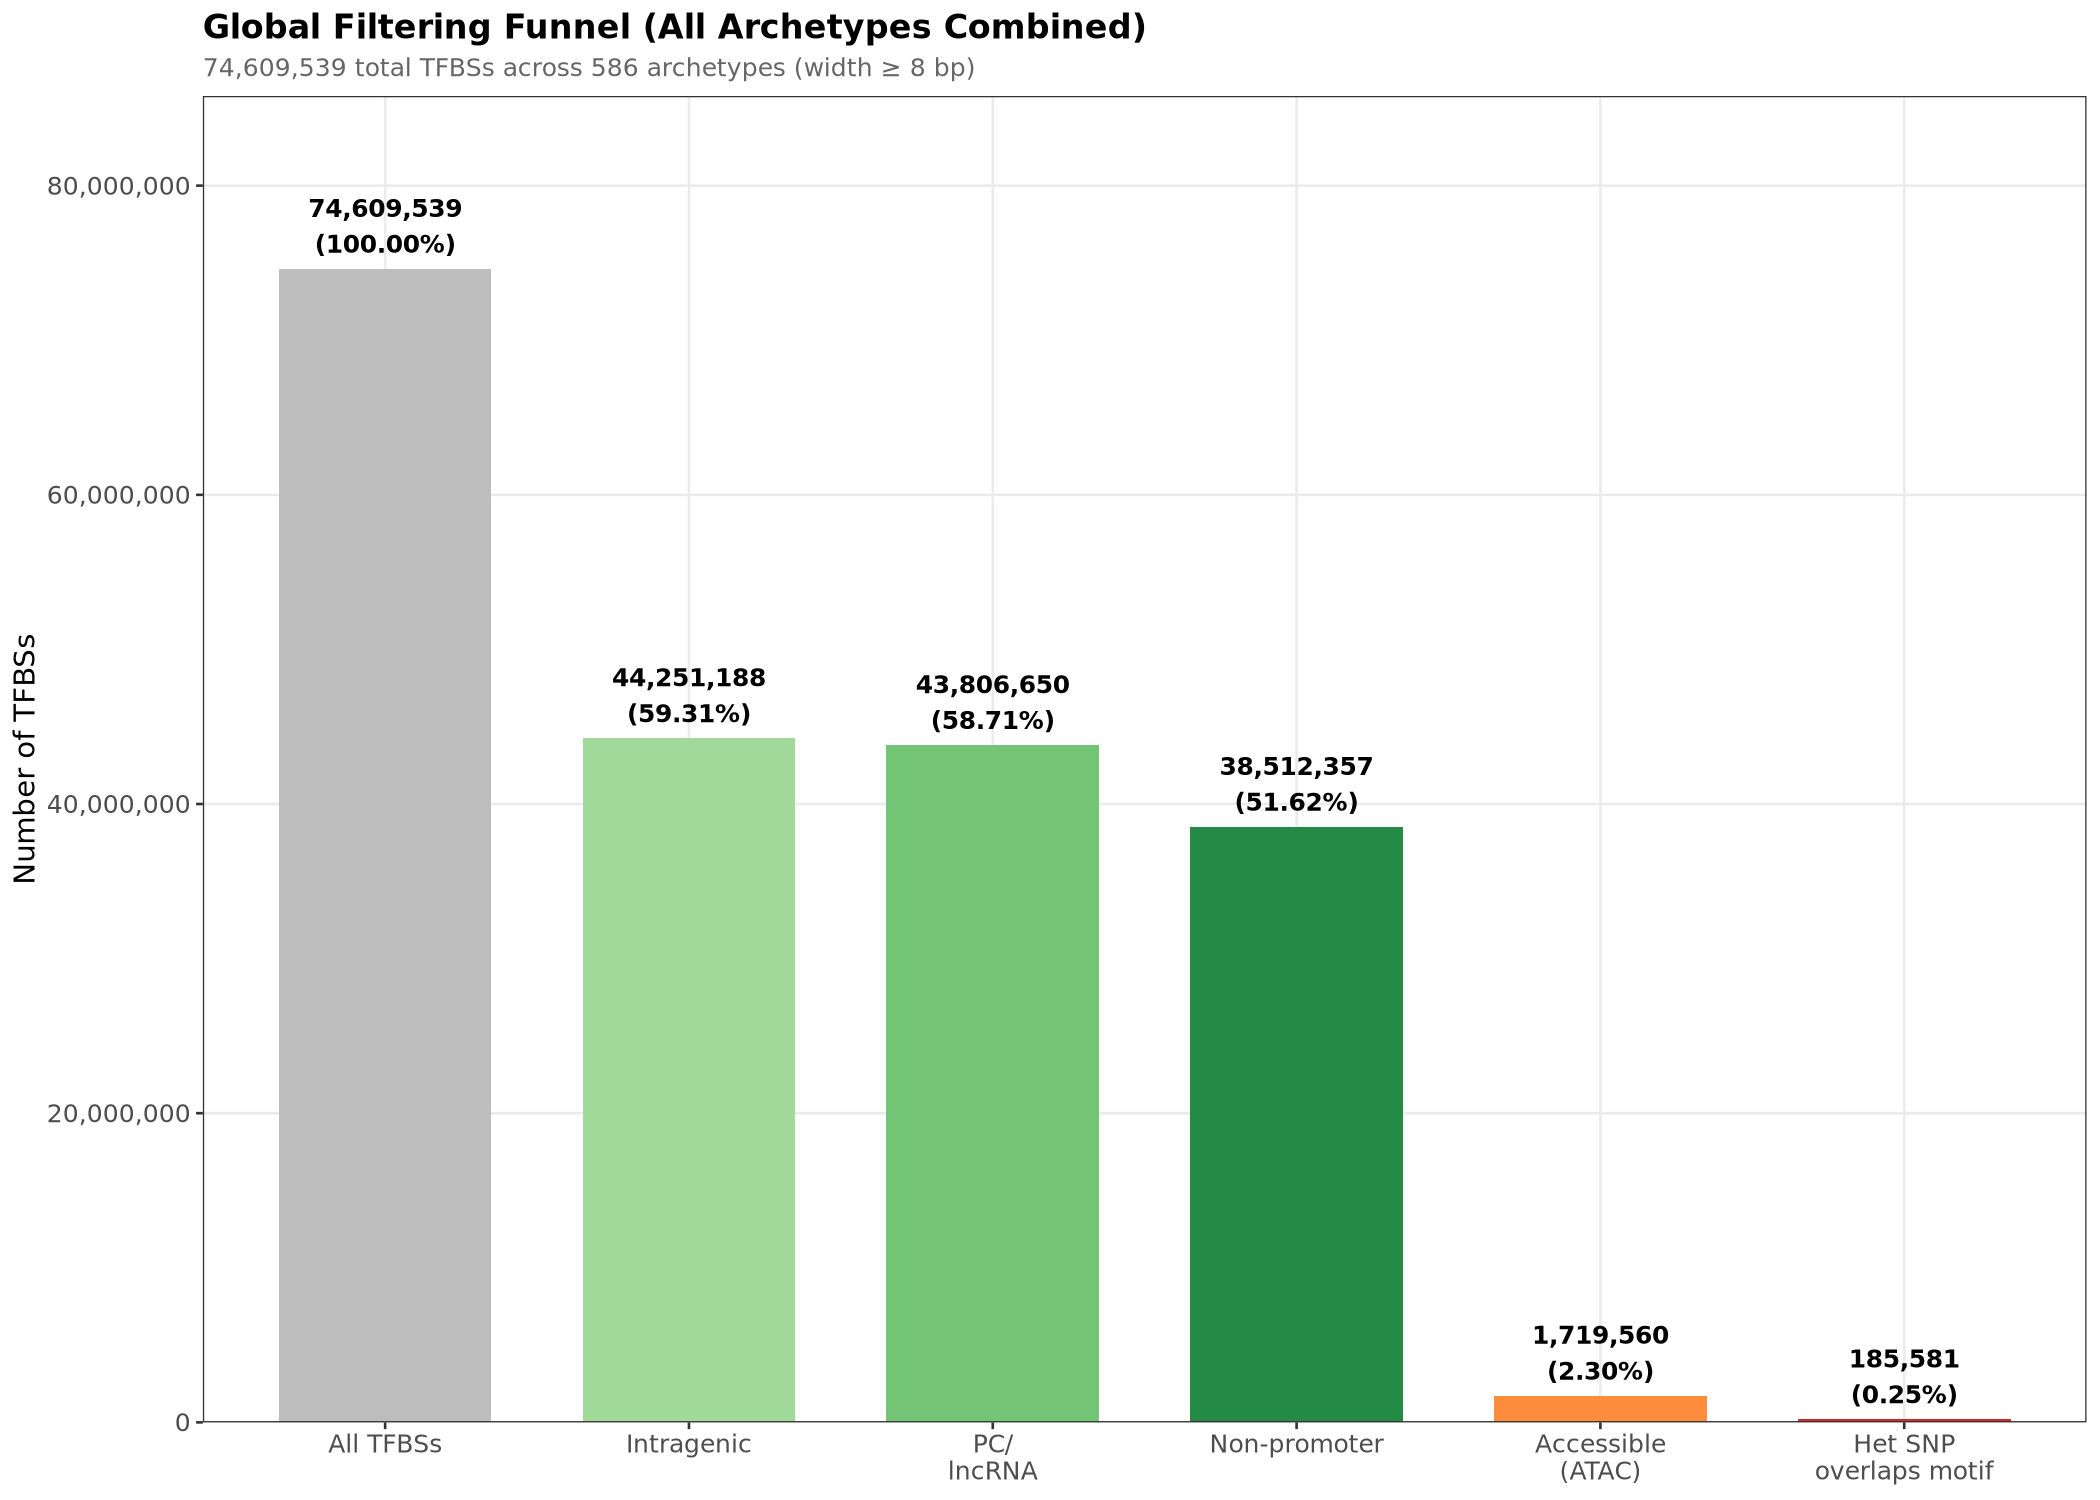

In [4]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 3: Global filtering funnel                                        ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

total_all     <- sum(arch_sum$n_total)
total_intra   <- sum(arch_sum$n_intragenic)
total_pcl     <- sum(arch_sum$n_intragenic_pcl)
total_nonprom <- sum(arch_sum$n_intragenic_nonpromoter)
total_acc     <- sum(arch_sum$n_accessible)
total_snp_ov  <- sum(arch_sum$n_snp_overlap)

global_funnel <- data.table(
    step = c("All TFBSs", "Intragenic",
             "PC/\nlncRNA",
             "Non-promoter",
             "Accessible\n(ATAC)",
             "Het SNP\noverlaps motif"),
    count = c(total_all, total_intra, total_pcl, total_nonprom,
              total_acc, total_snp_ov)
)
global_funnel[, step := factor(step, levels = step)]
global_funnel[, pct := count / total_all * 100]
global_funnel[, pct_label := paste0(comma(count), "\n(",
                                     sprintf("%.2f%%", pct), ")")]

p <- ggplot(global_funnel, aes(x = step, y = count, fill = step)) +
    geom_bar(stat = "identity", width = 0.7, show.legend = FALSE) +
    geom_text(aes(label = pct_label), vjust = -0.3, 
              size = FUNNEL_LABEL_SIZE,  # ← TEXT ON BARS (already controllable)
              fontface = "bold") +
    scale_fill_manual(values = c("#bdbdbd", "#a1d99b", "#74c476",
                                  "#238b45", "#fd8d3c", "#d62728")) +
    scale_y_continuous(labels = comma,
                       expand = expansion(mult = c(0, 0.15))) +
    labs(title = "Global Filtering Funnel (All Archetypes Combined)",
         subtitle = paste0(comma(total_all), " total TFBSs across ",
                           nrow(arch_sum), " archetypes (width \u2265 ",
                           MIN_WIDTH, " bp)"),
         x = NULL, y = "Number of TFBSs") +
    THEME +
    theme(
        # ═══════════════════ FONT SIZE CONTROLS ═══════════════════
        plot.title = element_text(size = 16),        # ← TITLE SIZE
        plot.subtitle = element_text(size = 12),     # ← SUBTITLE SIZE
        axis.title.x = element_text(size = 14),      # ← X-AXIS LABEL SIZE
        axis.title.y = element_text(size = 14),      # ← Y-AXIS LABEL SIZE
        axis.text.x = element_text(size = 12,        # ← X-AXIS TICK LABELS
                                    lineheight = 0.9),
        axis.text.y = element_text(size = 12)        # ← Y-AXIS TICK LABELS
        # ══════════════════════════════════════════════════════════
    )
print(p)

# Save the plot to a new subdirectory
dir.create("plots", showWarnings = FALSE)  # Create 'plots' folder if it doesn't exist
ggsave("plots/global_filtering_funnel.png", 
       plot = p, 
       width = 9,   # ← PLOT WIDTH (inches)
       height = 6,   # ← PLOT HEIGHT (inches)
       dpi = 300)    # ← RESOLUTION

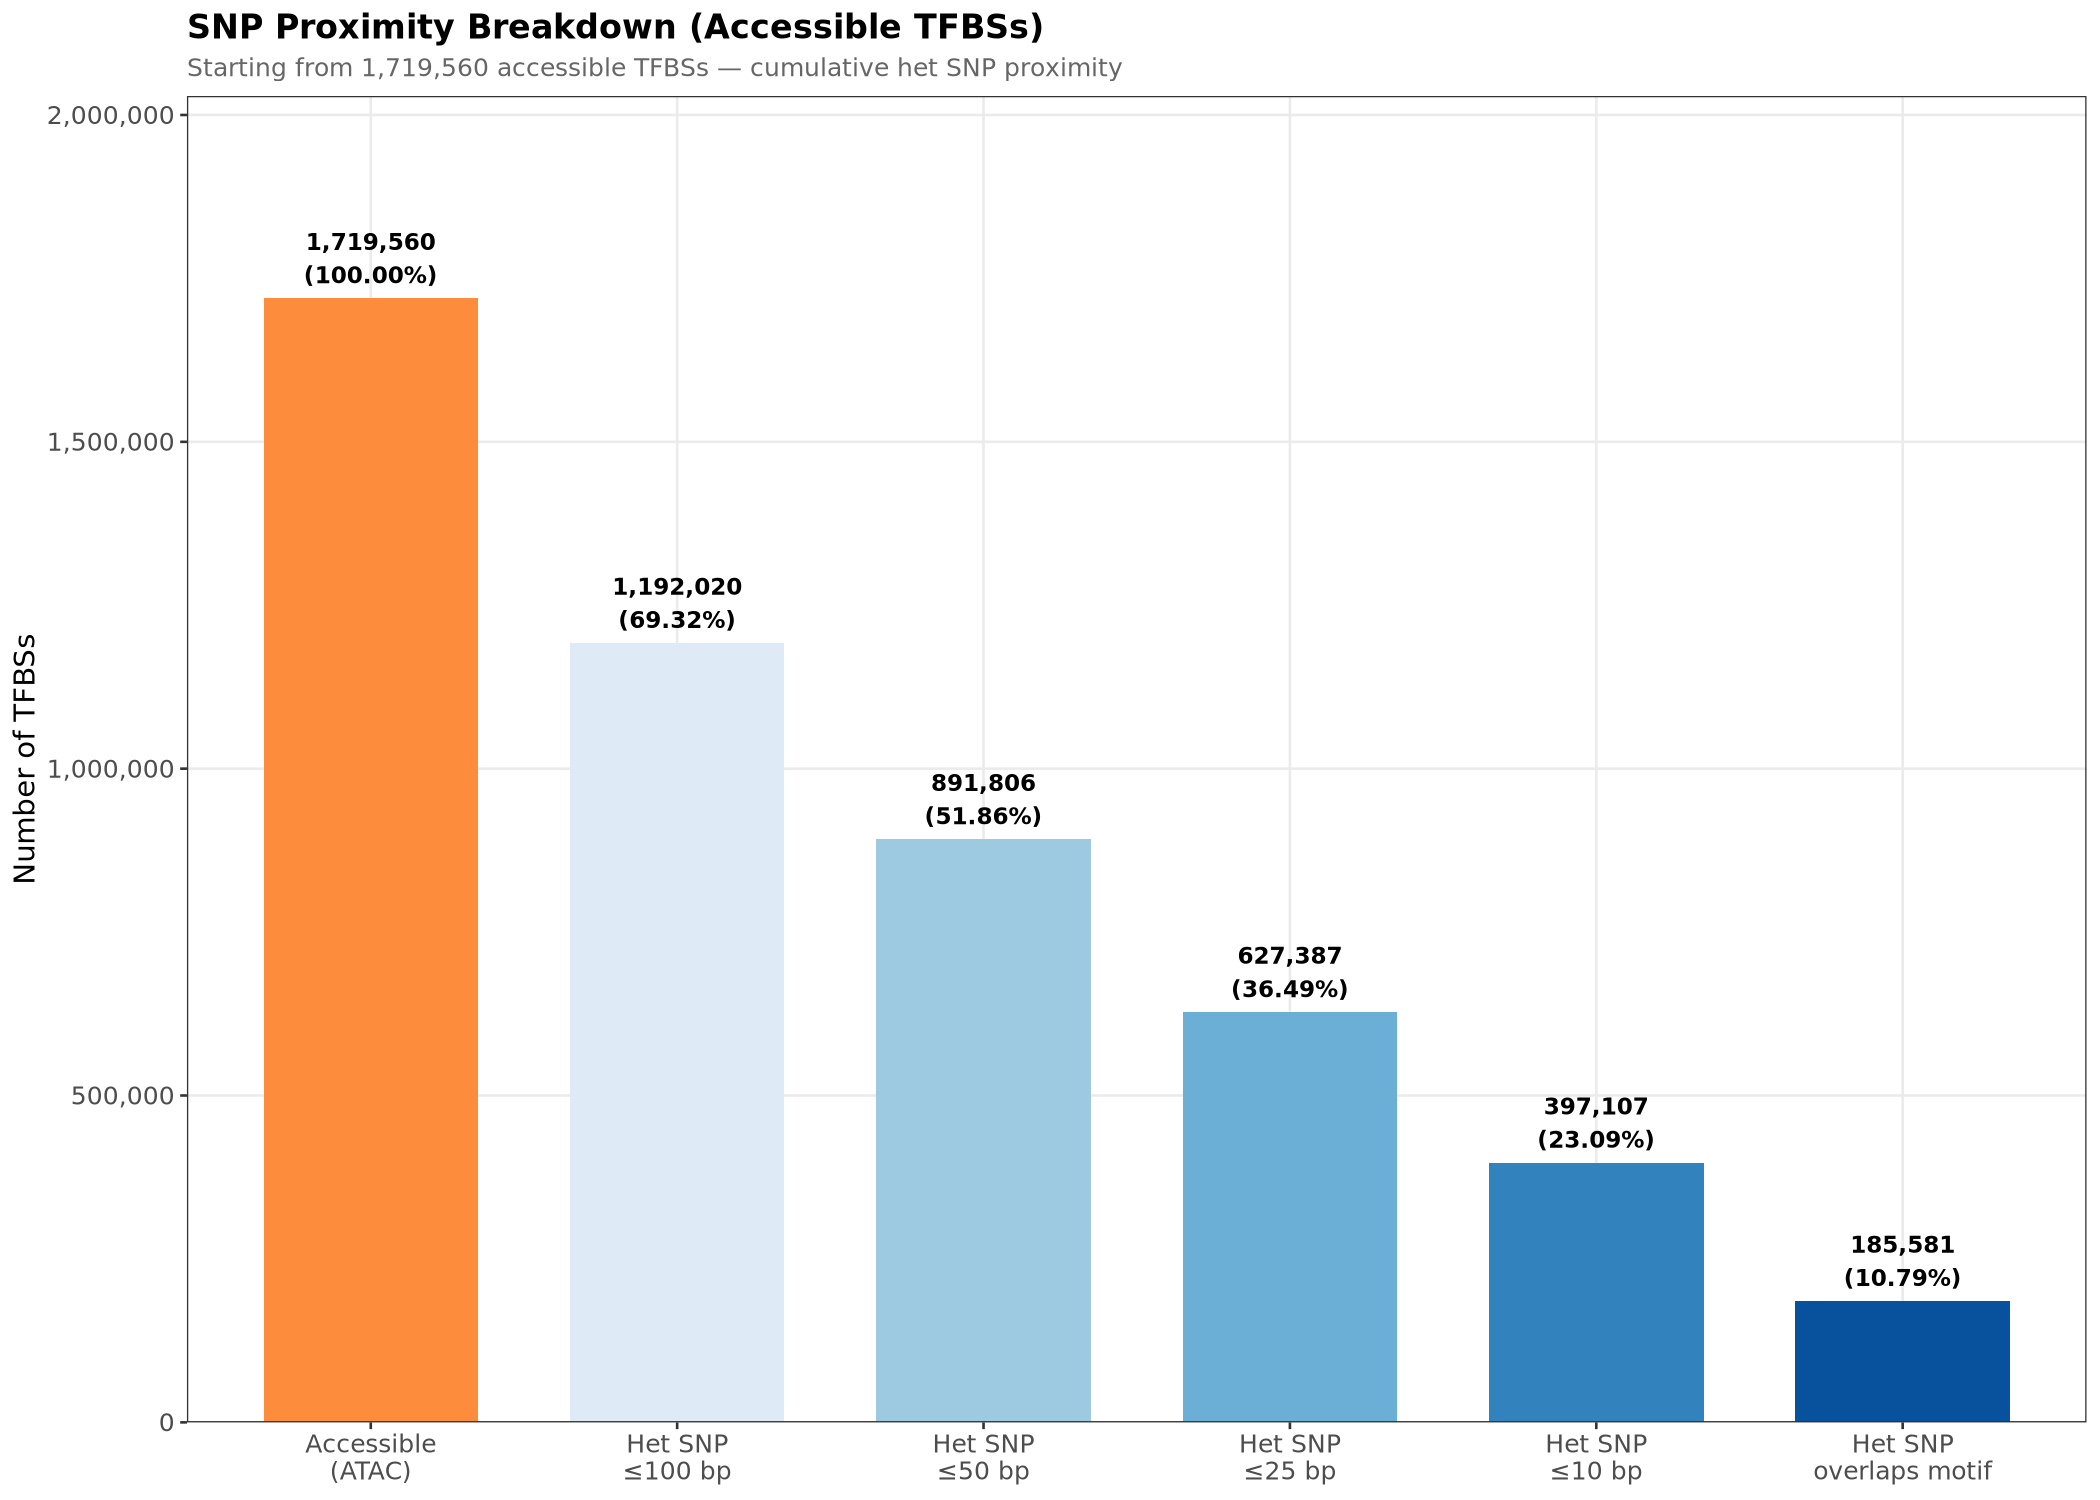

In [12]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 4: Zoomed SNP proximity funnel (rescaled from accessible)         ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

total_snp_100 <- sum(arch_sum$n_snp_100bp)
total_snp_50  <- sum(arch_sum$n_snp_50bp)
total_snp_25  <- sum(arch_sum$n_snp_25bp)
total_snp_10  <- sum(arch_sum$n_snp_10bp)

zoomed_funnel <- data.table(
    step = c("Accessible\n(ATAC)",
             "Het SNP\n\u2264100 bp",
             "Het SNP\n\u226450 bp",
             "Het SNP\n\u226425 bp",
             "Het SNP\n\u226410 bp",
             "Het SNP\noverlaps motif"),
    count = c(total_acc, total_snp_100, total_snp_50,
              total_snp_25, total_snp_10, total_snp_ov)
)
zoomed_funnel[, step := factor(step, levels = step)]
zoomed_funnel[, pct_of_acc := count / total_acc * 100]
zoomed_funnel[, pct_label := paste0(comma(count), "\n(",
                                     sprintf("%.2f%%", pct_of_acc),
                                     ")")]

p <- ggplot(zoomed_funnel, aes(x = step, y = count, fill = step)) +
    geom_bar(stat = "identity", width = 0.7, show.legend = FALSE) +
    geom_text(aes(label = pct_label), vjust = -0.3, 
              size = FUNNEL_LABEL_SIZE - 0.3,  # ← TEXT ON BARS
              fontface = "bold") +
    # ═══════════════════ COLOR SCHEME ═══════════════════
    # Orange (accessible) → Light to Dark Blues (SNP proximity)
    scale_fill_manual(values = c("#fd8d3c",   # ← ACCESSIBLE (orange)
                                  "#deebf7",   # ← ≤100 bp (lightest blue)
                                  "#9ecae1",   # ← ≤50 bp (light blue)
                                  "#6baed6",   # ← ≤25 bp (medium blue)
                                  "#3182bd",   # ← ≤10 bp (darker blue)
                                  "#08519c"))+ # ← OVERLAPS (darkest blue)
    # ════════════════════════════════════════════════════
    scale_y_continuous(labels = comma,
                       expand = expansion(mult = c(0, 0.18))) +
    labs(title = "SNP Proximity Breakdown (Accessible TFBSs)",
         subtitle = paste0("Starting from ", comma(total_acc),
                           " accessible TFBSs \u2014 cumulative het SNP proximity"),
         x = NULL, y = "Number of TFBSs") +
    THEME +
    theme(
        # ═══════════════════ FONT SIZE CONTROLS ═══════════════════
        plot.title = element_text(size = 16),        # ← TITLE SIZE
        plot.subtitle = element_text(size = 12),     # ← SUBTITLE SIZE
        axis.title.x = element_text(size = 14),      # ← X-AXIS LABEL SIZE
        axis.title.y = element_text(size = 14),      # ← Y-AXIS LABEL SIZE
        axis.text.x = element_text(size = 12,        # ← X-AXIS TICK LABELS
                                    lineheight = 0.9),
        axis.text.y = element_text(size = 12)        # ← Y-AXIS TICK LABELS
        # ══════════════════════════════════════════════════════════
    )
print(p)

# Save the plot to subdirectory
dir.create("plots", showWarnings = FALSE)
ggsave("plots/snp_proximity_funnel.png", 
       plot = p, 
       width = 9,   # ← PLOT WIDTH (inches)
       height = 6,   # ← PLOT HEIGHT (inches)
       dpi = 300)    # ← RESOLUTION

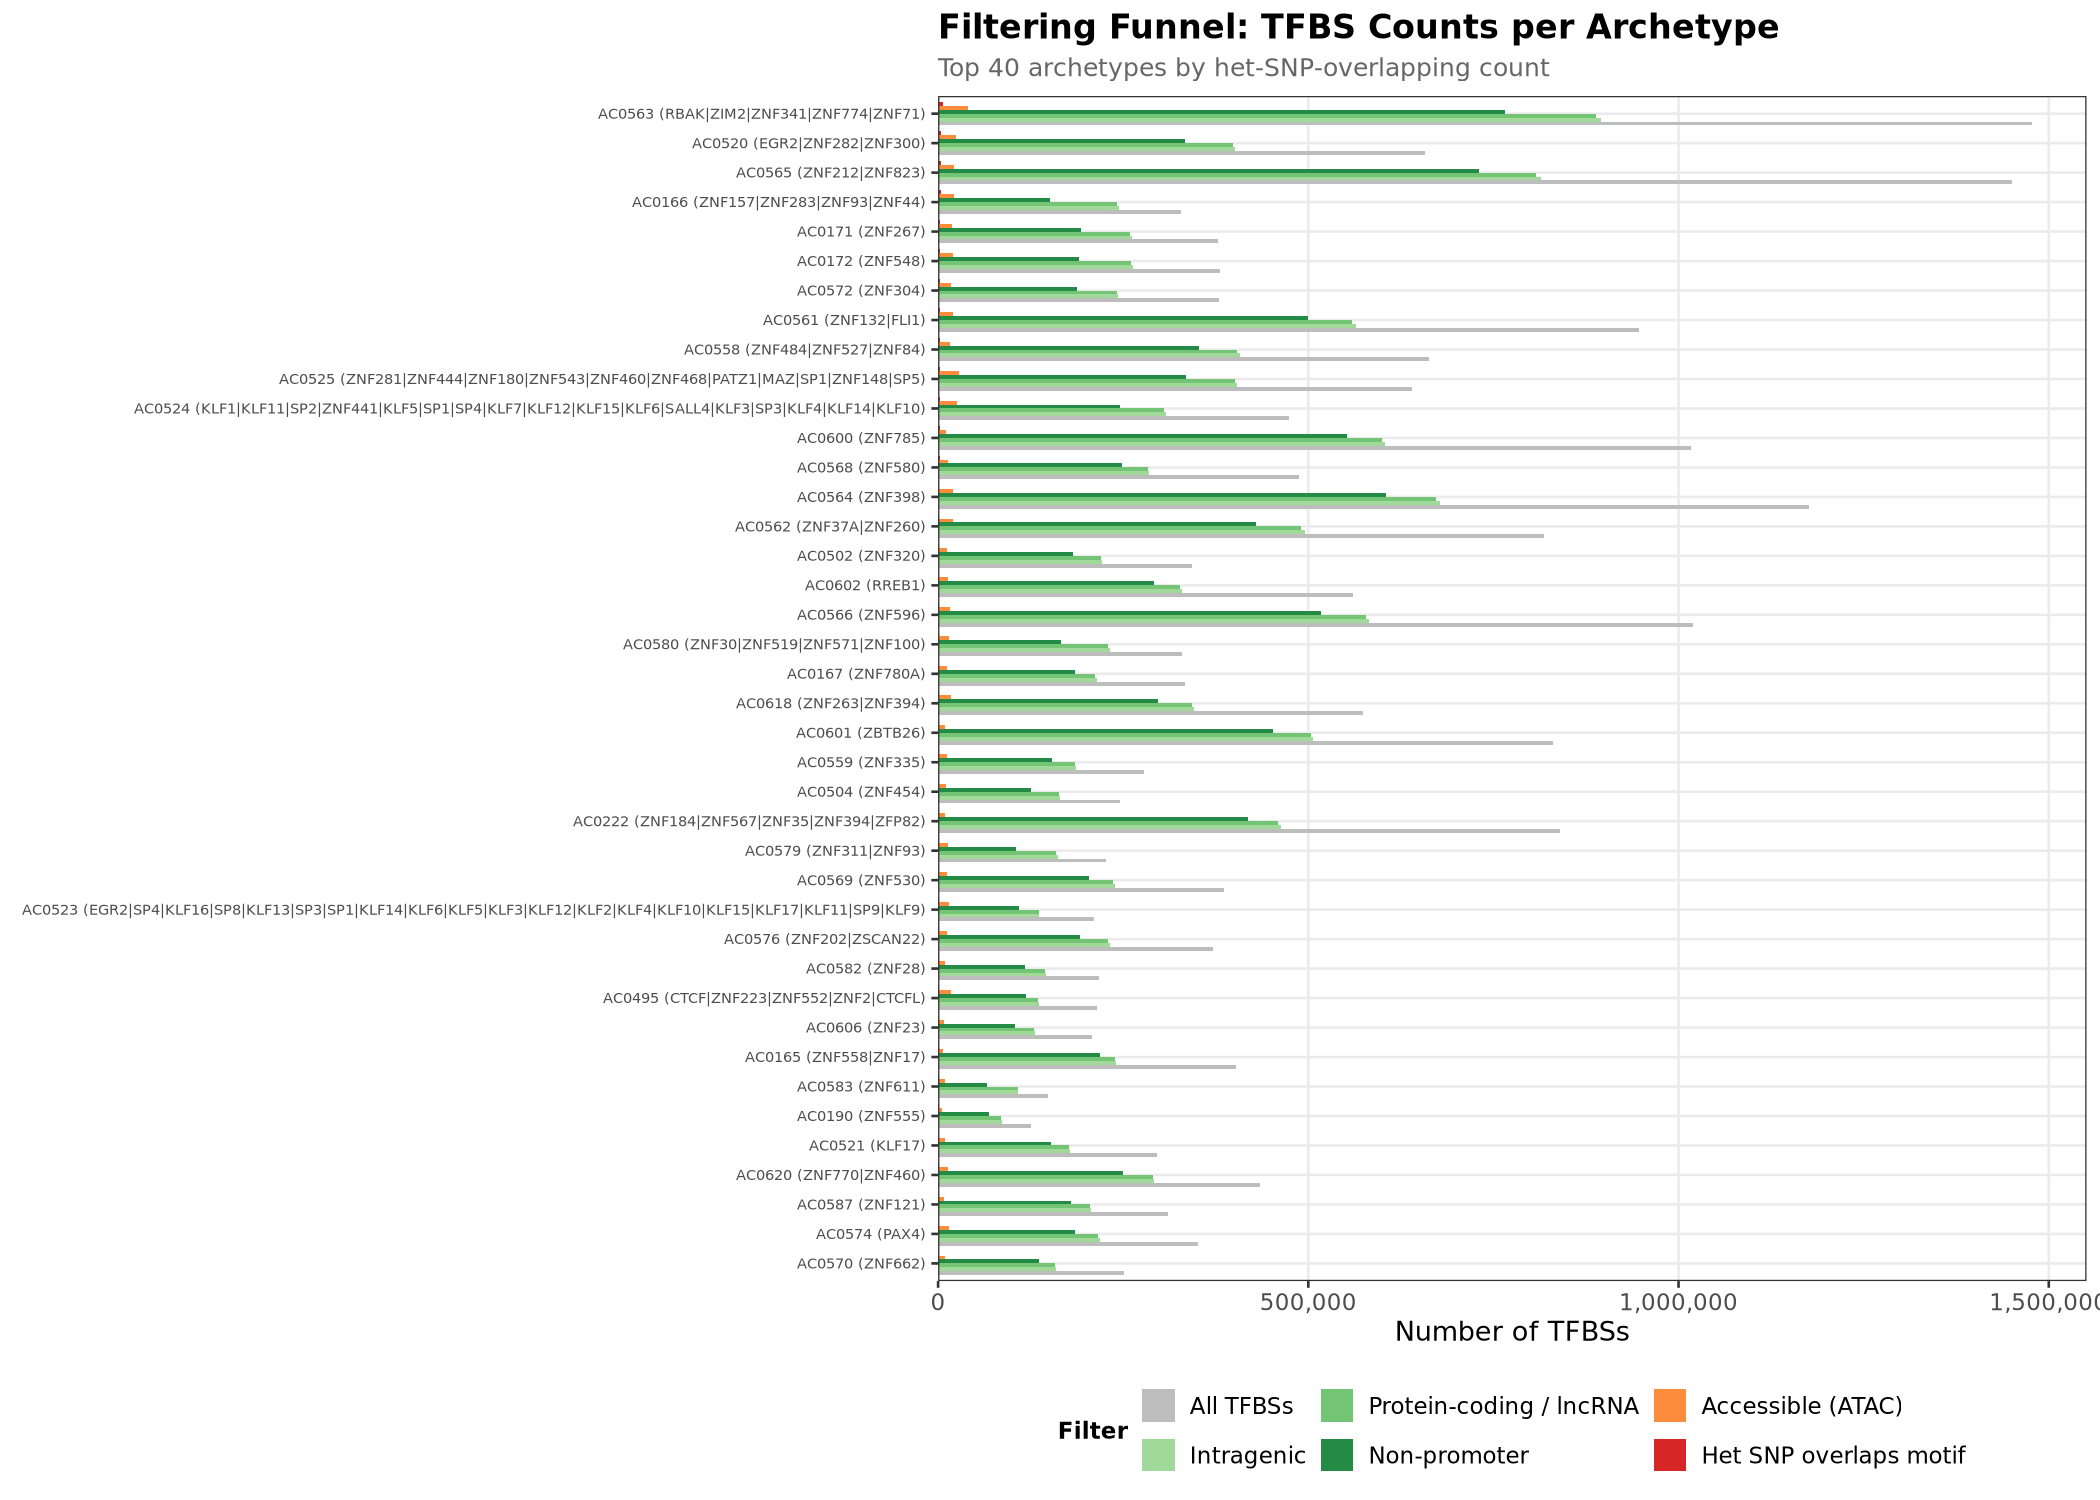

In [13]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 5: Per-archetype funnel — standard (counts)                       ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

top_arch <- head(arch_sum[n_snp_overlap > 0][order(-n_snp_overlap)], TOP_N)

funnel_long <- melt(top_arch,
    id.vars = c("archetype", "tf_names"),
    measure.vars = c("n_total", "n_intragenic", "n_intragenic_pcl",
                      "n_intragenic_nonpromoter", "n_accessible", "n_snp_overlap"),
    variable.name = "filter_level", value.name = "count"
)
funnel_long[, filter_label := fcase(
    filter_level == "n_total",                    "All TFBSs",
    filter_level == "n_intragenic",               "Intragenic",
    filter_level == "n_intragenic_pcl",           "Protein-coding / lncRNA",
    filter_level == "n_intragenic_nonpromoter",   "Non-promoter",
    filter_level == "n_accessible",               "Accessible (ATAC)",
    filter_level == "n_snp_overlap",              "Het SNP overlaps motif"
)]
funnel_long[, filter_label := factor(filter_label, levels = names(FILTER_COLORS))]

funnel_long[, display := paste0(archetype, " (", tf_names, ")")]
arch_order <- top_arch[order(n_snp_overlap)]$archetype
display_order <- paste0(arch_order, " (",
                         top_arch[match(arch_order, archetype)]$tf_names, ")")
funnel_long[, display := factor(display, levels = display_order)]

p <- ggplot(funnel_long, aes(x = display, y = count, fill = filter_label)) +
    geom_bar(stat = "identity", position = "dodge", width = 0.8) +
    scale_fill_manual(values = FILTER_COLORS, name = "Filter") +
    scale_y_continuous(labels = comma, expand = expansion(mult = c(0, 0.05))) +
    coord_flip() +
    labs(title = "Filtering Funnel: TFBS Counts per Archetype",
         subtitle = paste0("Top ", nrow(top_arch),
                           " archetypes by het-SNP-overlapping count"),
         x = NULL, y = "Number of TFBSs") +
    THEME +
    theme(legend.position = "bottom",
          axis.text.y = element_text(size = Y_AXIS_ARCH_SIZE))
print(p)


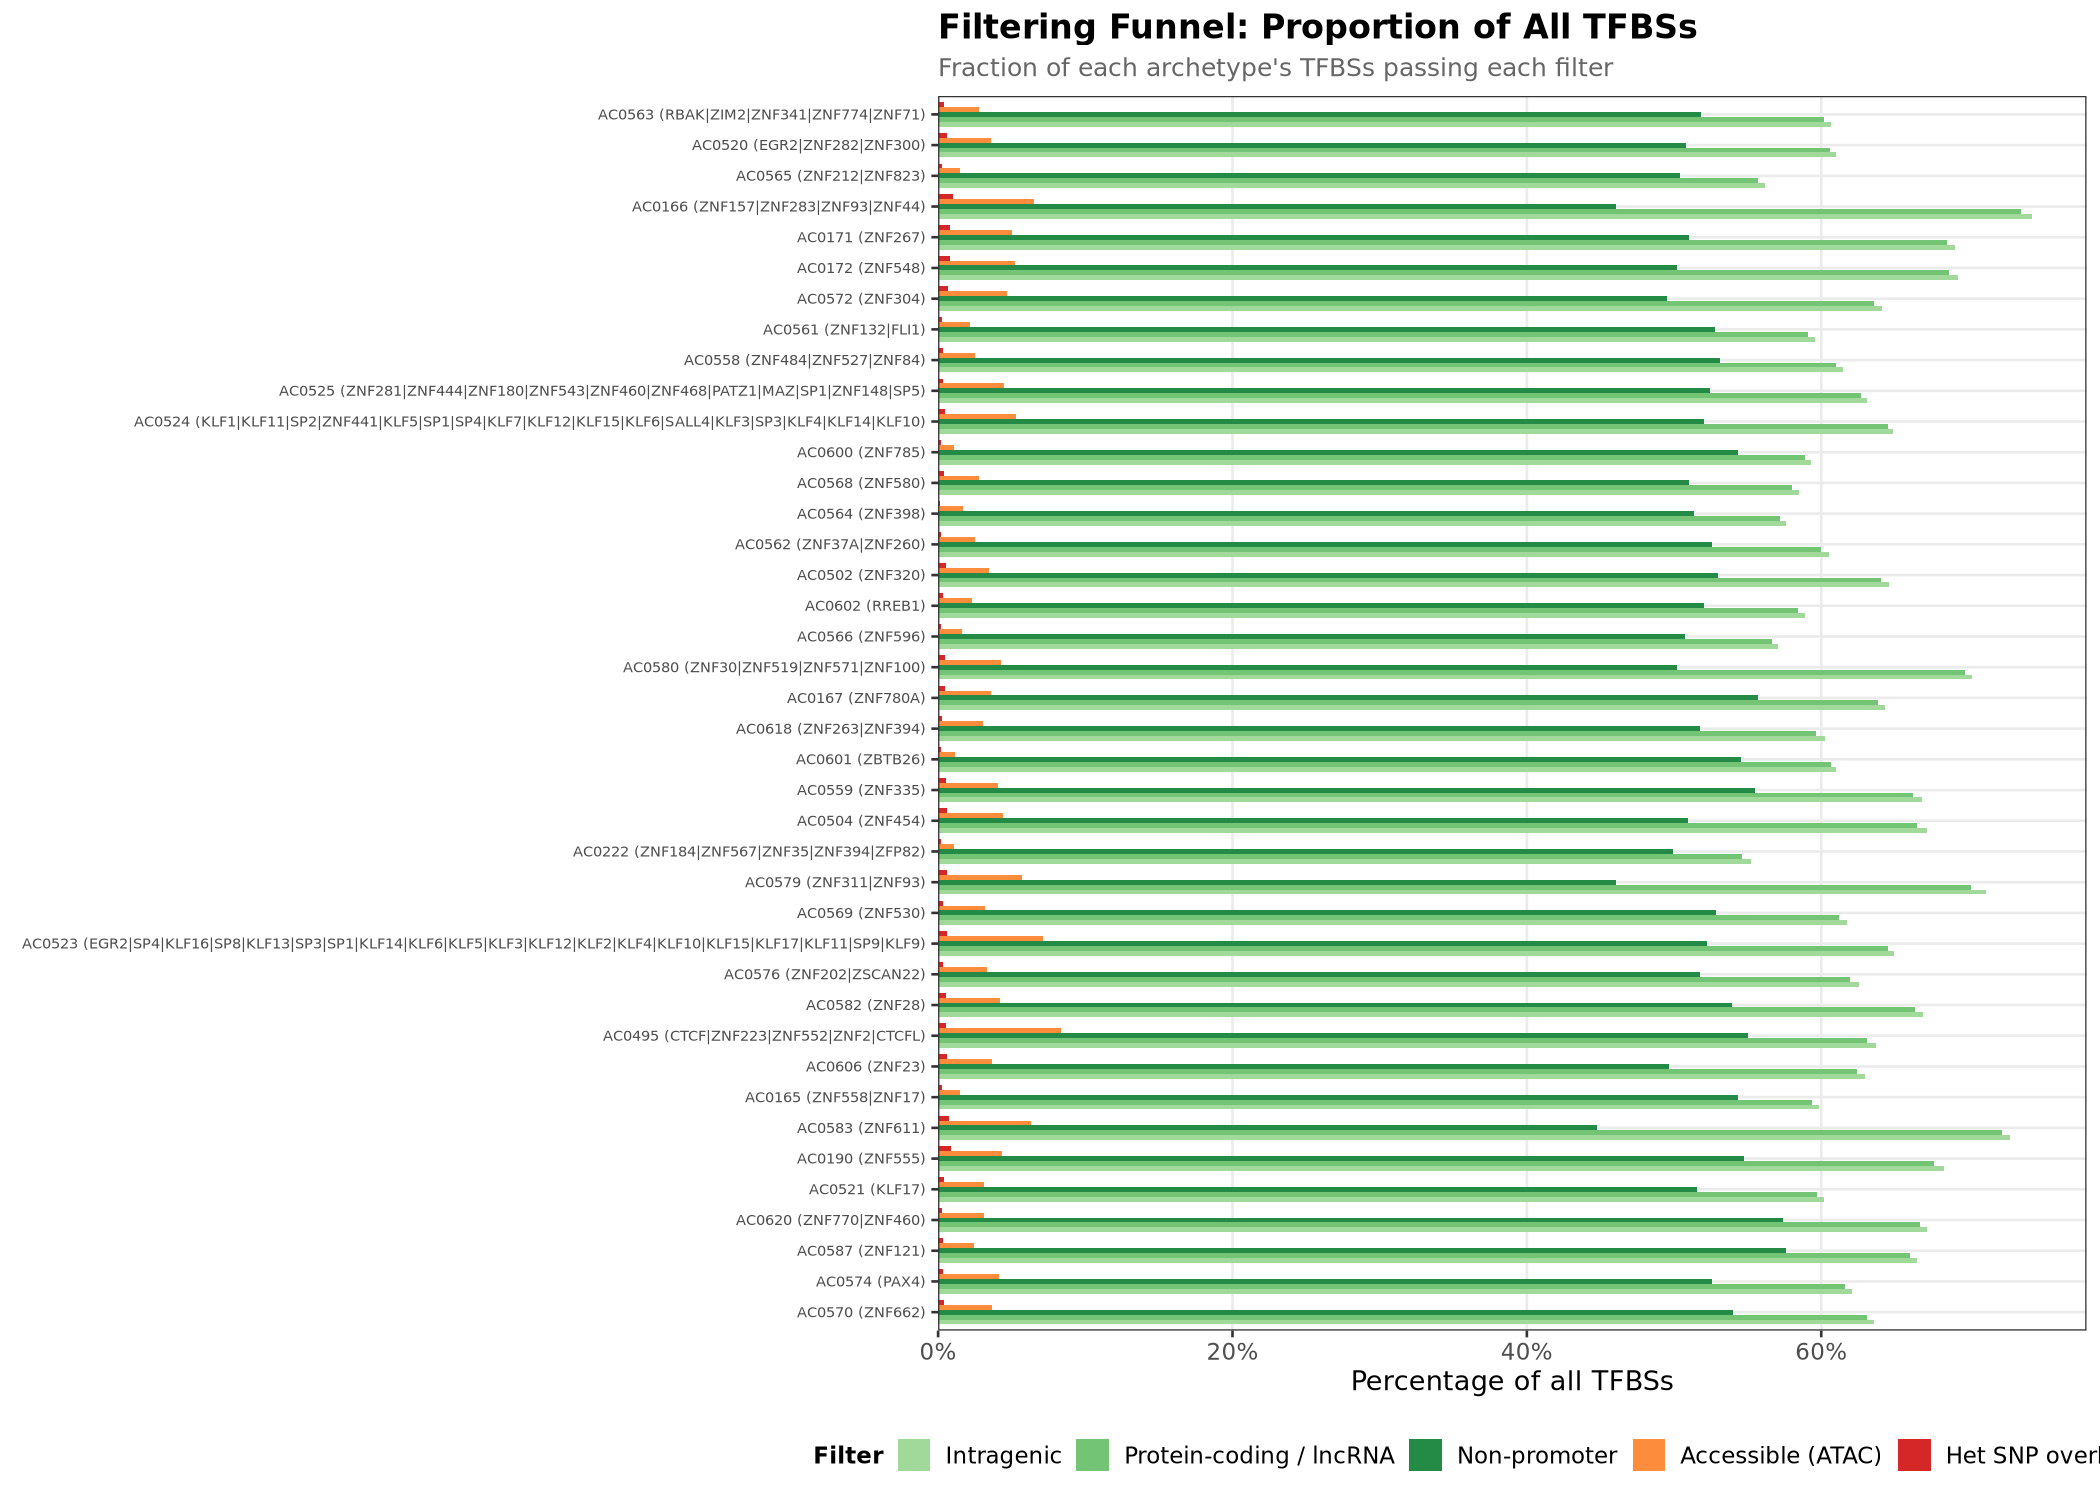

In [14]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 6: Per-archetype funnel — standard (proportions)                  ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

funnel_long[, pct := count / count[filter_label == "All TFBSs"] * 100,
             by = archetype]

p <- ggplot(funnel_long[filter_label != "All TFBSs"],
             aes(x = display, y = pct, fill = filter_label)) +
    geom_bar(stat = "identity", position = "dodge", width = 0.8) +
    scale_fill_manual(values = FILTER_COLORS[-1], name = "Filter") +
    scale_y_continuous(labels = function(x) paste0(x, "%"),
                       expand = expansion(mult = c(0, 0.05))) +
    coord_flip() +
    labs(title = "Filtering Funnel: Proportion of All TFBSs",
         subtitle = "Fraction of each archetype's TFBSs passing each filter",
         x = NULL, y = "Percentage of all TFBSs") +
    THEME +
    theme(legend.position = "bottom",
          axis.text.y = element_text(size = Y_AXIS_ARCH_SIZE))
print(p)


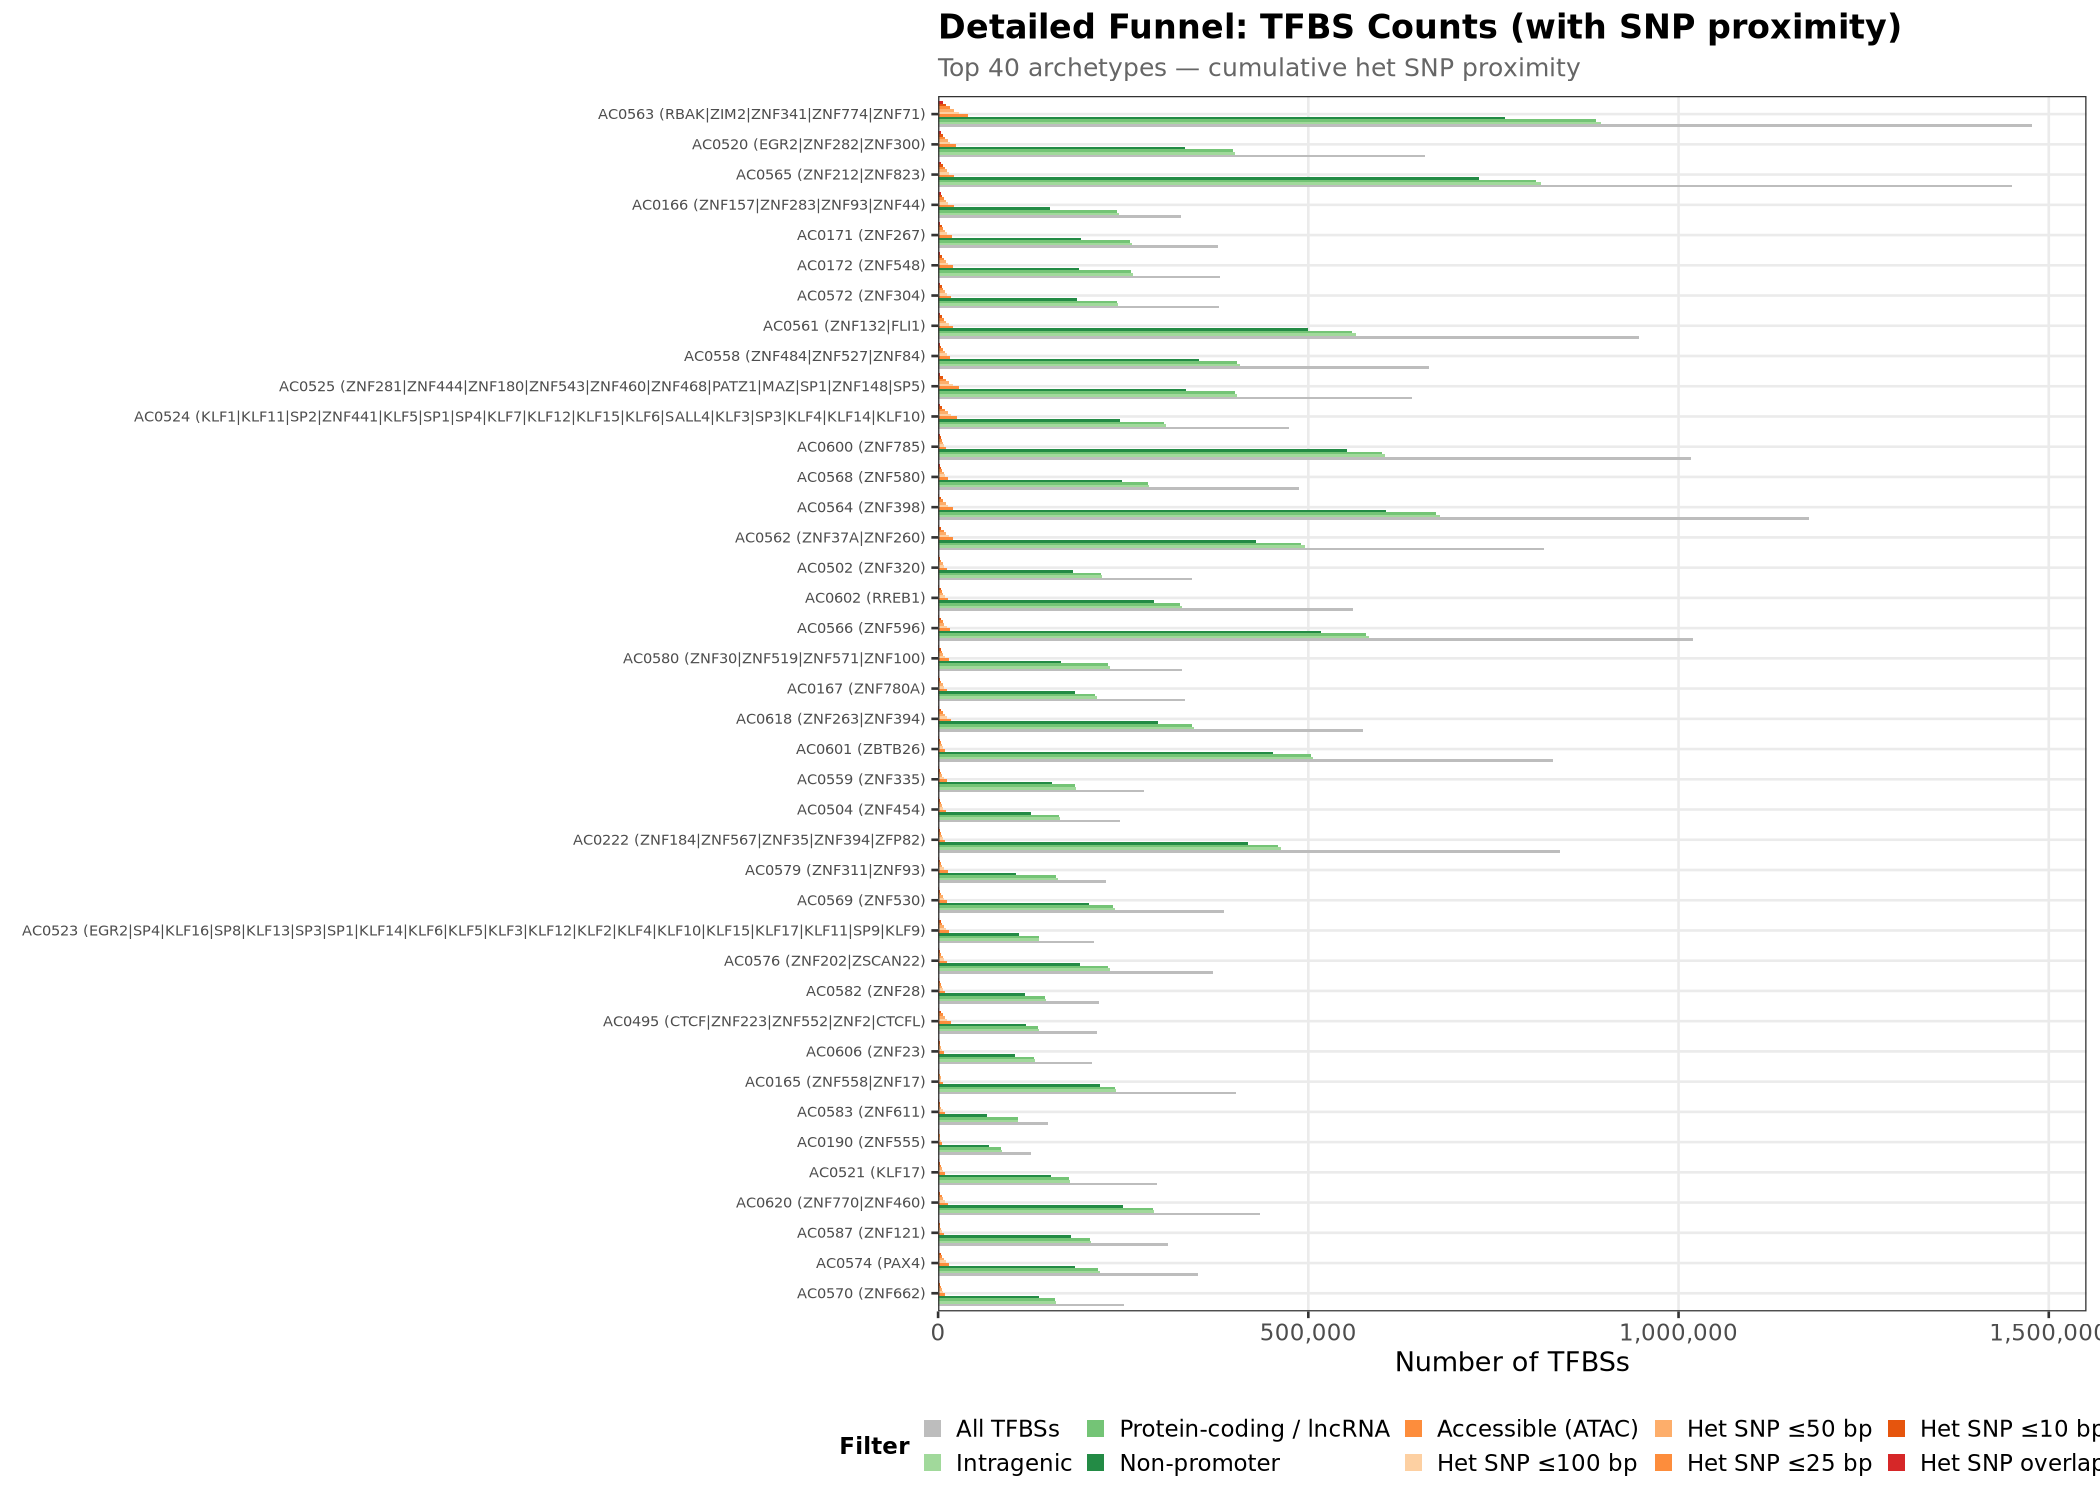

In [15]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 7: Per-archetype funnel — DETAILED (counts, with SNP proximity)   ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

detail_long <- melt(top_arch,
    id.vars = c("archetype", "tf_names"),
    measure.vars = c("n_total", "n_intragenic", "n_intragenic_pcl",
                      "n_intragenic_nonpromoter", "n_accessible",
                      "n_snp_100bp", "n_snp_50bp", "n_snp_25bp",
                      "n_snp_10bp", "n_snp_overlap"),
    variable.name = "filter_level", value.name = "count"
)
detail_long[, filter_label := fcase(
    filter_level == "n_total",                    "All TFBSs",
    filter_level == "n_intragenic",               "Intragenic",
    filter_level == "n_intragenic_pcl",           "Protein-coding / lncRNA",
    filter_level == "n_intragenic_nonpromoter",   "Non-promoter",
    filter_level == "n_accessible",               "Accessible (ATAC)",
    filter_level == "n_snp_100bp",                "Het SNP \u2264100 bp",
    filter_level == "n_snp_50bp",                 "Het SNP \u226450 bp",
    filter_level == "n_snp_25bp",                 "Het SNP \u226425 bp",
    filter_level == "n_snp_10bp",                 "Het SNP \u226410 bp",
    filter_level == "n_snp_overlap",              "Het SNP overlaps motif"
)]
detail_long[, filter_label := factor(filter_label,
    levels = names(DETAIL_FILTER_COLORS))]
detail_long[, display := paste0(archetype, " (", tf_names, ")")]
detail_long[, display := factor(display, levels = display_order)]

p <- ggplot(detail_long, aes(x = display, y = count, fill = filter_label)) +
    geom_bar(stat = "identity", position = "dodge", width = 0.85) +
    scale_fill_manual(values = DETAIL_FILTER_COLORS, name = "Filter") +
    scale_y_continuous(labels = comma, expand = expansion(mult = c(0, 0.05))) +
    coord_flip() +
    labs(title = "Detailed Funnel: TFBS Counts (with SNP proximity)",
         subtitle = paste0("Top ", nrow(top_arch),
                           " archetypes \u2014 cumulative het SNP proximity"),
         x = NULL, y = "Number of TFBSs") +
    THEME +
    theme(legend.position = "bottom",
          axis.text.y = element_text(size = Y_AXIS_ARCH_SIZE),
          legend.key.size = unit(0.35, "cm"))
print(p)


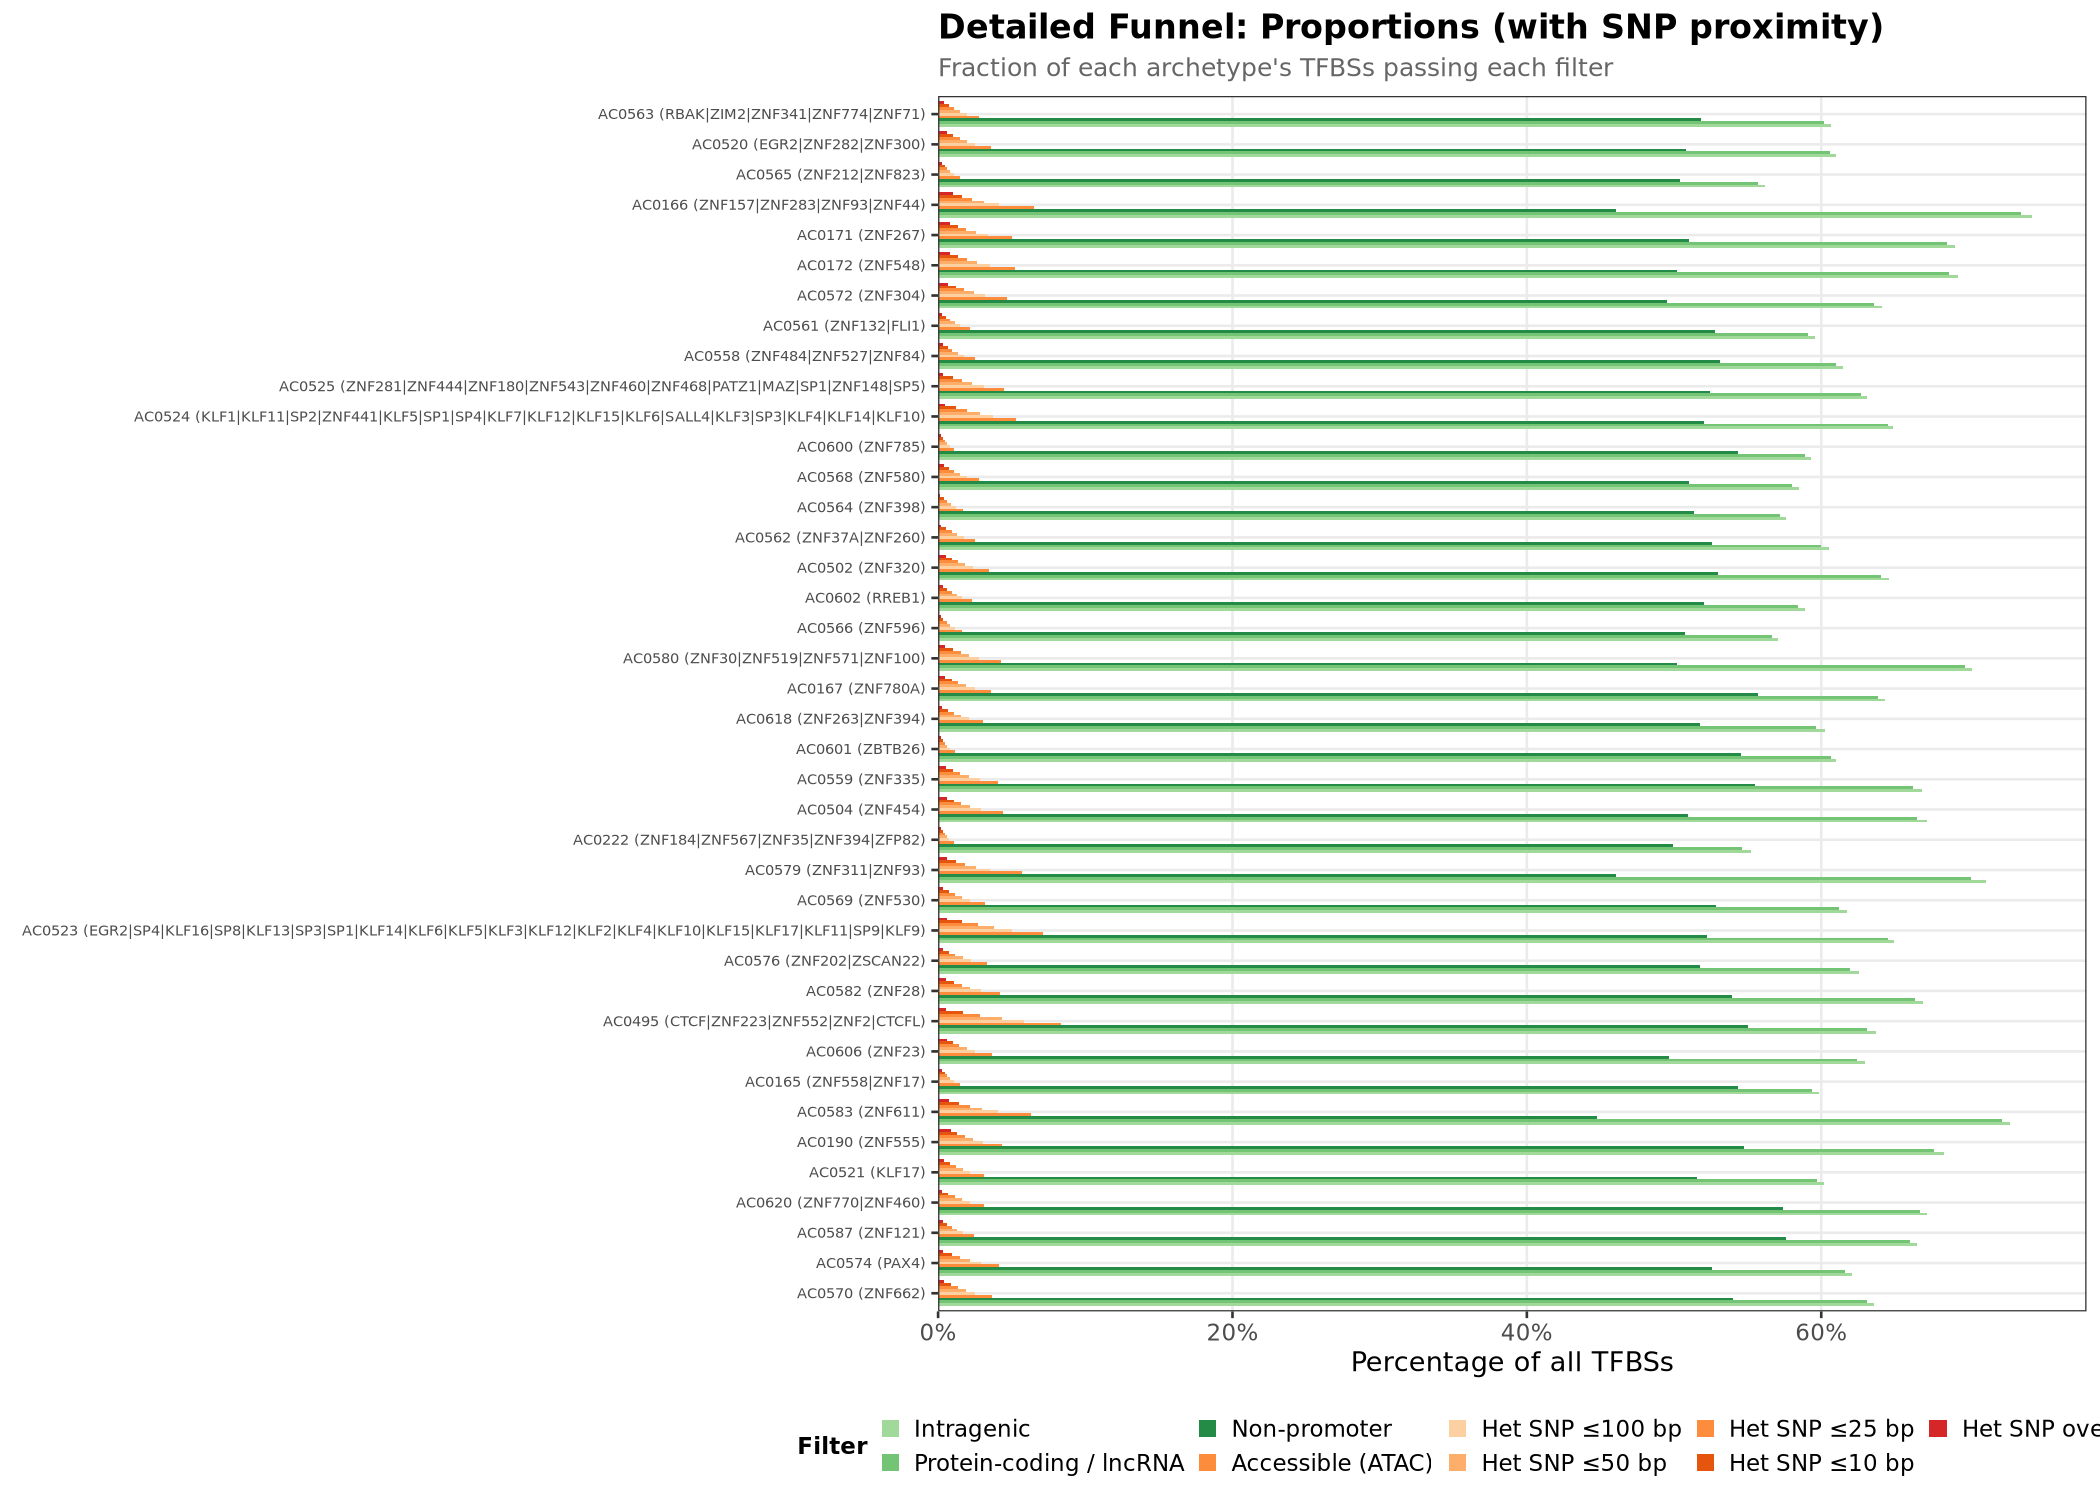

In [16]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 8: Per-archetype funnel — DETAILED (proportions)                  ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

detail_long[, pct := count / count[filter_label == "All TFBSs"] * 100,
             by = archetype]

p <- ggplot(detail_long[filter_label != "All TFBSs"],
             aes(x = display, y = pct, fill = filter_label)) +
    geom_bar(stat = "identity", position = "dodge", width = 0.85) +
    scale_fill_manual(values = DETAIL_FILTER_COLORS[-1], name = "Filter") +
    scale_y_continuous(labels = function(x) paste0(x, "%"),
                       expand = expansion(mult = c(0, 0.05))) +
    coord_flip() +
    labs(title = "Detailed Funnel: Proportions (with SNP proximity)",
         subtitle = "Fraction of each archetype's TFBSs passing each filter",
         x = NULL, y = "Percentage of all TFBSs") +
    THEME +
    theme(legend.position = "bottom",
          axis.text.y = element_text(size = Y_AXIS_ARCH_SIZE),
          legend.key.size = unit(0.35, "cm"))
print(p)

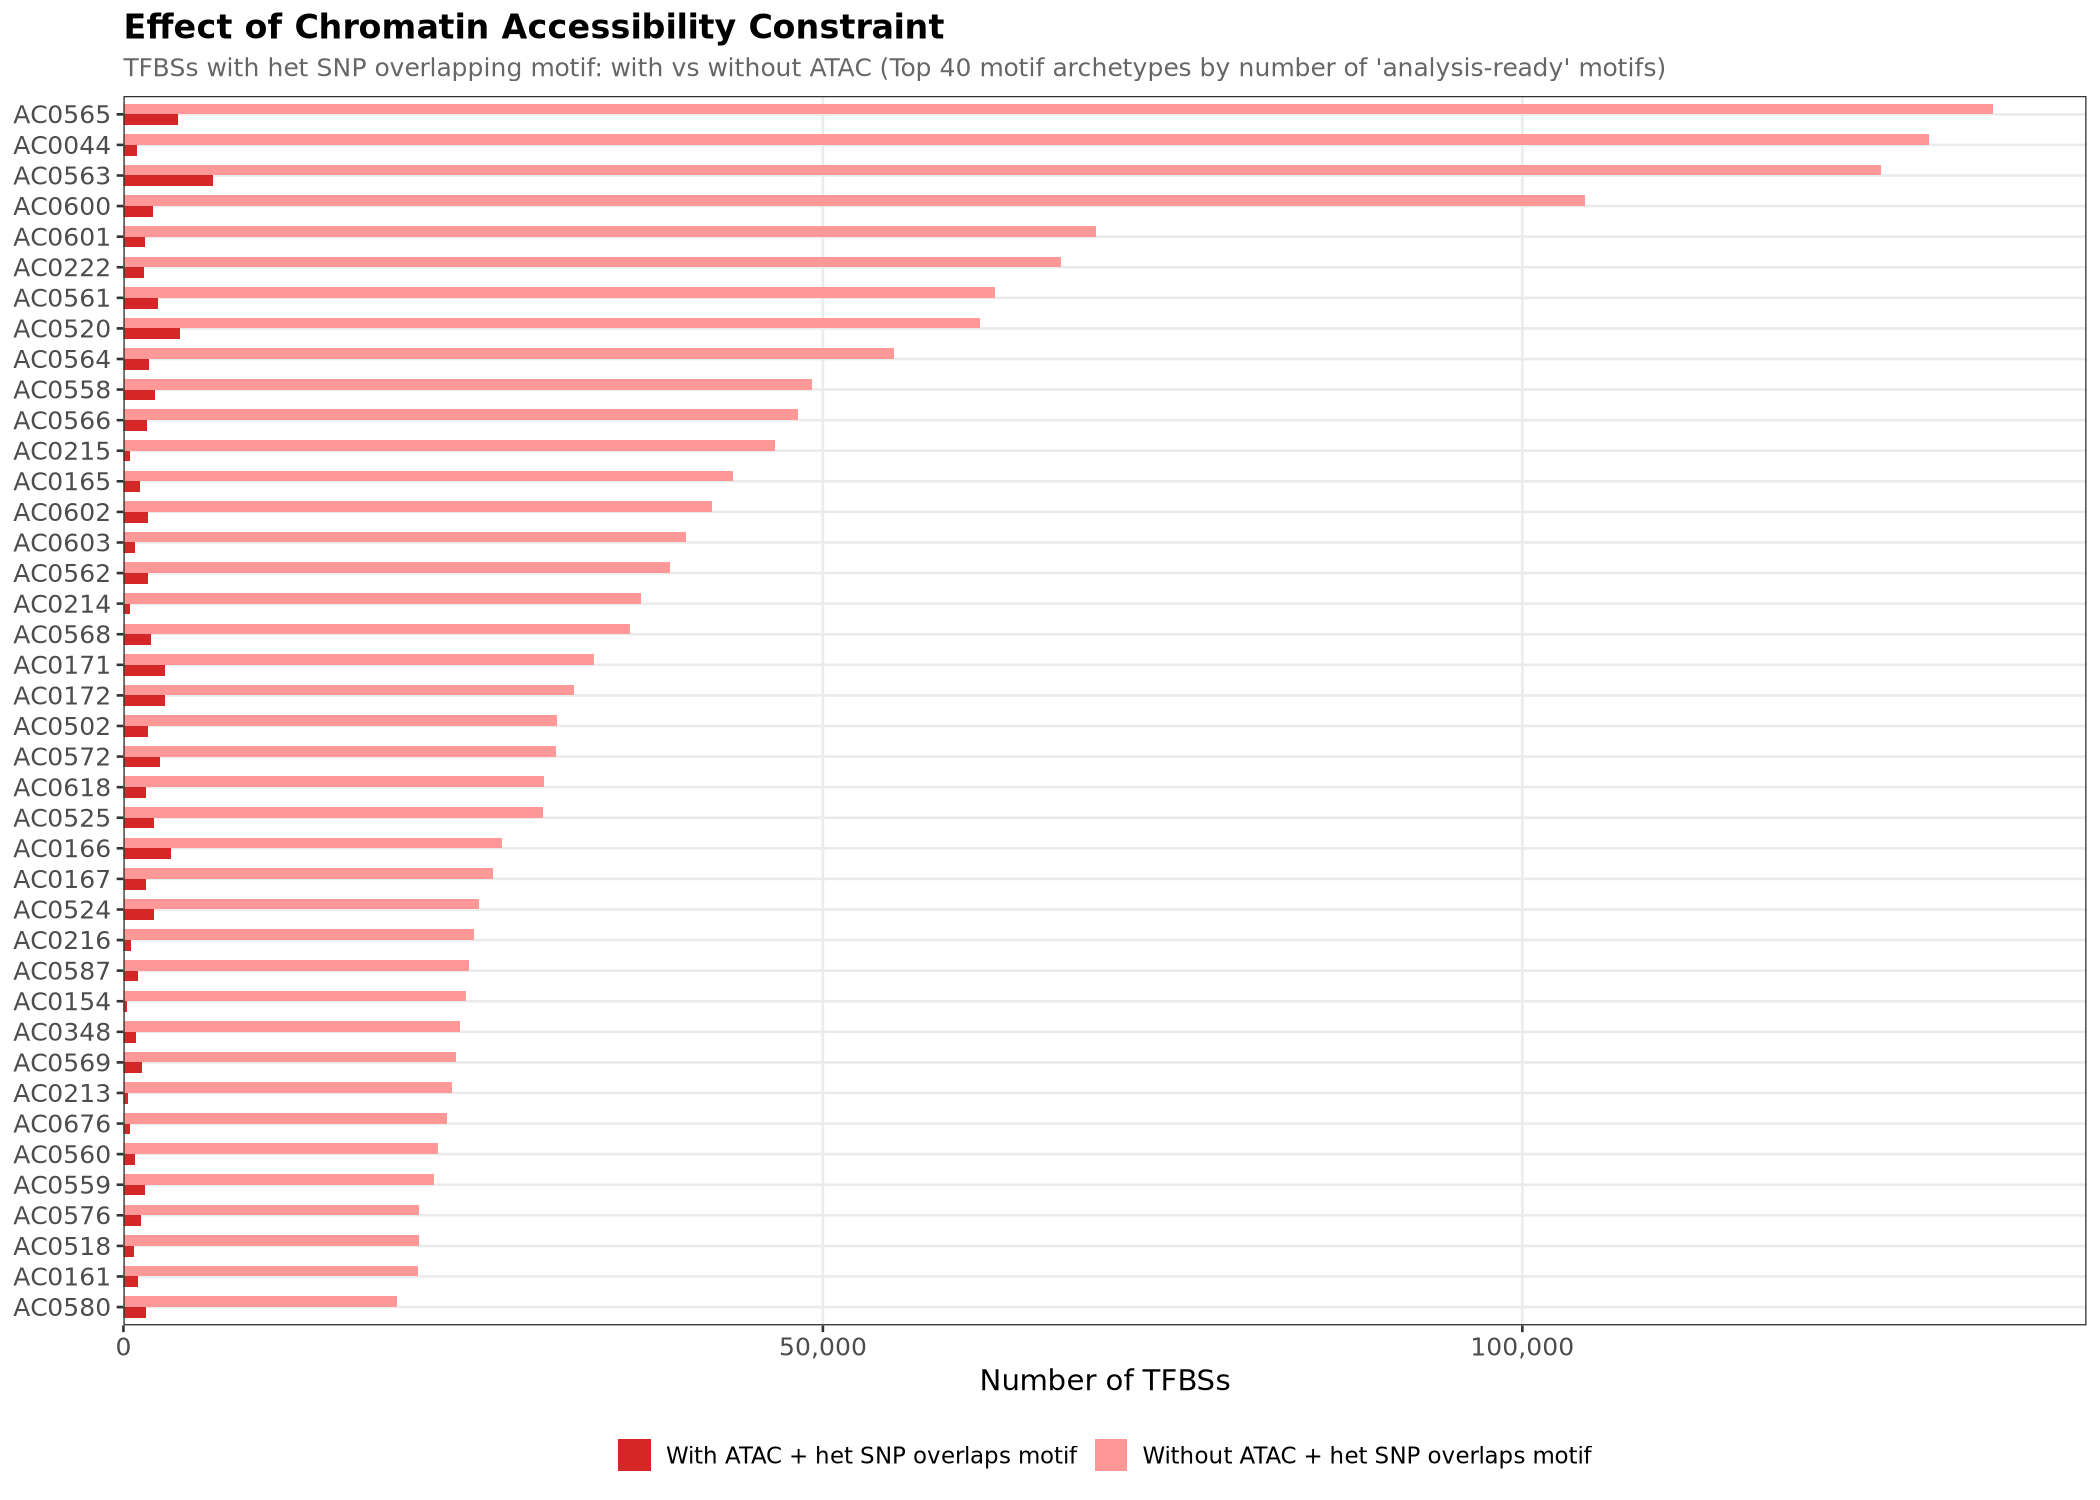

In [21]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 9: ATAC constraint comparison — standard (overlap only)           ║
# ╚═══════════════════════════════════════════════════════════════════════════╝
atac_compare <- arch_sum[n_noatac_snp_overlap > 0][order(-n_noatac_snp_overlap)]
atac_compare <- head(atac_compare, TOP_N)
atac_long <- melt(atac_compare,
    id.vars = c("archetype", "tf_names"),
    measure.vars = c("n_noatac_snp_overlap", "n_snp_overlap"),
    variable.name = "filter", value.name = "count"
)
atac_long[, filter_label := fifelse(
    filter == "n_snp_overlap",
    "With ATAC + het SNP overlaps motif",
    "Without ATAC + het SNP overlaps motif"
)]
# ═══════════════════ REMOVED TF NAMES ═══════════════════
atac_long[, display := archetype]  # ← ONLY ARCHETYPE, NO TF NAMES
atac_order <- atac_compare[order(n_noatac_snp_overlap)]$archetype
atac_display_order <- atac_order  # ← ONLY ARCHETYPE, NO TF NAMES
# ════════════════════════════════════════════════════════
atac_long[, display := factor(display, levels = atac_display_order)]

p <- ggplot(atac_long, aes(x = display, y = count, fill = filter_label)) +
    geom_bar(stat = "identity", position = "dodge", width = 0.7) +
    scale_fill_manual(values = c(
        "With ATAC + het SNP overlaps motif" = "#d62728",
        "Without ATAC + het SNP overlaps motif" = "#ff9896"
    ), name = NULL) +
    scale_y_continuous(labels = comma, expand = expansion(mult = c(0, 0.05))) +
    coord_flip() +
    labs(title = "Effect of Chromatin Accessibility Constraint",
         subtitle = "TFBSs with het SNP overlapping motif: with vs without ATAC (Top 40 motif archetypes by number of 'analysis-ready' motifs)",
         x = NULL, y = "Number of TFBSs") +
    THEME +
    theme(
        # ═══════════════════ FONT SIZE CONTROLS ═══════════════════
        plot.title = element_text(size = 16),        # ← TITLE SIZE
        plot.subtitle = element_text(size = 12),     # ← SUBTITLE SIZE
        axis.title.x = element_text(size = 14),      # ← X-AXIS LABEL SIZE
        axis.title.y = element_text(size = 14),      # ← Y-AXIS LABEL SIZE
        axis.text.x = element_text(size = 12),       # ← X-AXIS TICK LABELS
        axis.text.y = element_text(size = 12),       # ← Y-AXIS TICK LABELS (archetypes)
        legend.position = "bottom",
        legend.text = element_text(size = 11)        # ← LEGEND TEXT SIZE
        # ══════════════════════════════════════════════════════════
    )
print(p)

# Save the plot to subdirectory
dir.create("plots", showWarnings = FALSE)
ggsave("plots/atac_constraint_comparison.png", 
       plot = p, 
       width = 12,   # ← PLOT WIDTH (inches)
       height = 8,   # ← PLOT HEIGHT (inches)
       dpi = 300)    # ← RESOLUTION

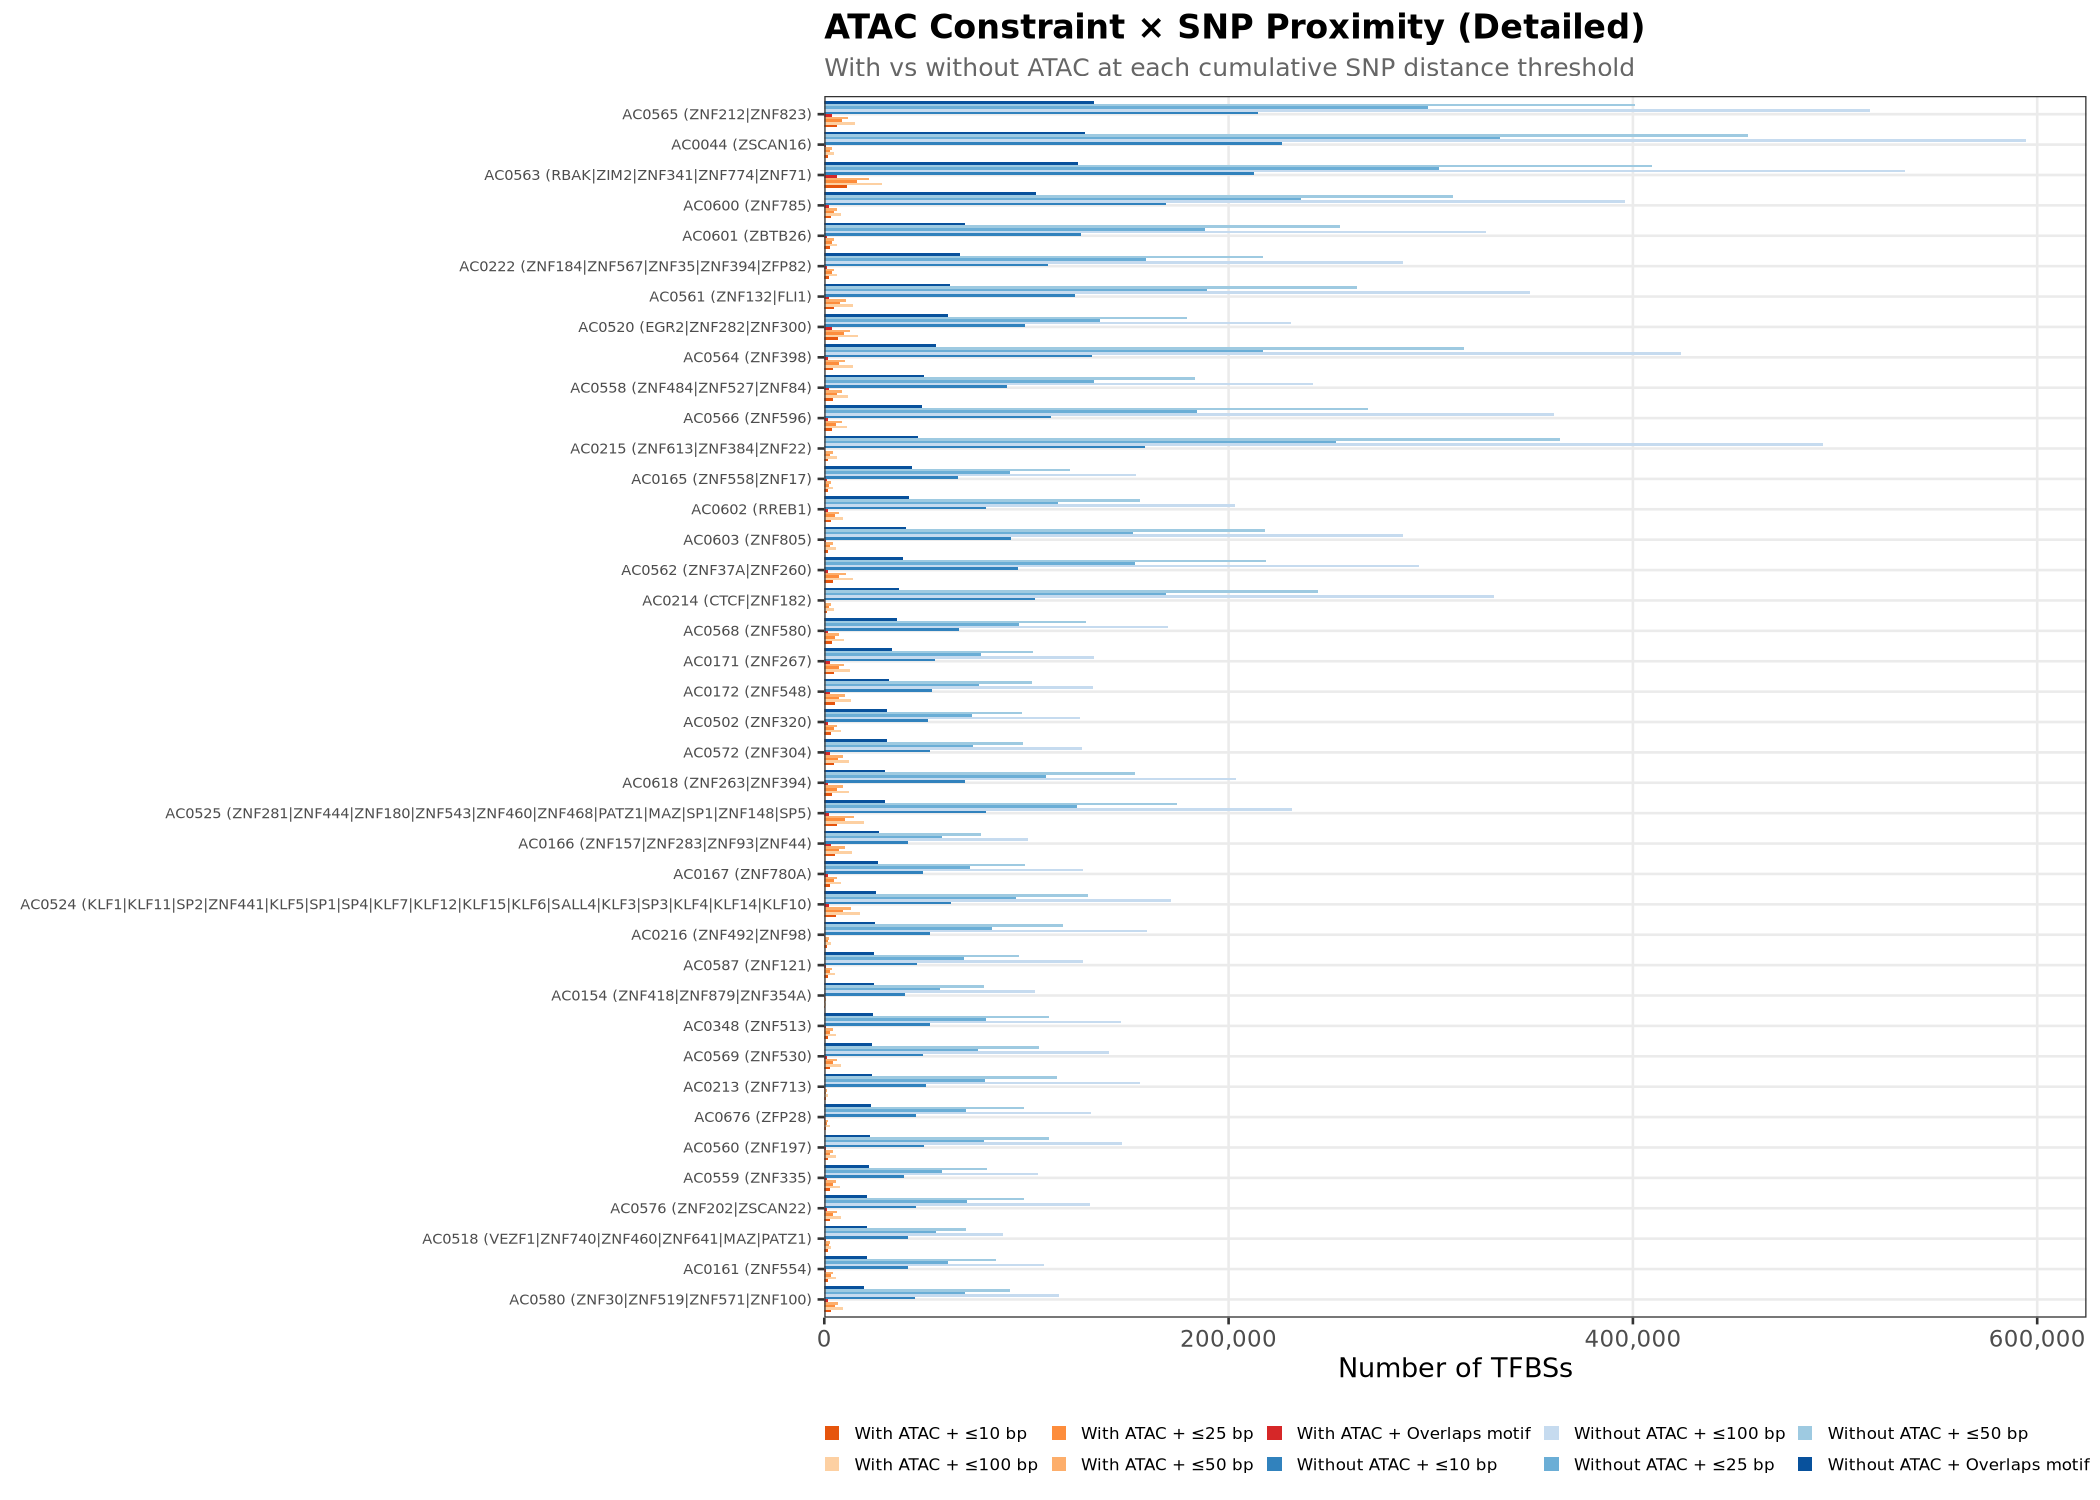

In [18]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 10: ATAC constraint — DETAILED (all SNP proximity thresholds)     ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

atac_detail_long <- melt(atac_compare,
    id.vars = c("archetype", "tf_names"),
    measure.vars = c("n_noatac_snp_100bp", "n_snp_100bp",
                      "n_noatac_snp_50bp",  "n_snp_50bp",
                      "n_noatac_snp_25bp",  "n_snp_25bp",
                      "n_noatac_snp_10bp",  "n_snp_10bp",
                      "n_noatac_snp_overlap", "n_snp_overlap"),
    variable.name = "filter", value.name = "count"
)
atac_detail_long[, atac_status := fifelse(grepl("noatac", filter),
                                           "Without ATAC", "With ATAC")]
atac_detail_long[, snp_thresh := fcase(
    grepl("100bp", filter), "\u2264100 bp",
    grepl("50bp", filter),  "\u226450 bp",
    grepl("25bp", filter),  "\u226425 bp",
    grepl("10bp", filter),  "\u226410 bp",
    grepl("overlap", filter), "Overlaps motif"
)]
atac_detail_long[, label := paste0(atac_status, " + ", snp_thresh)]
atac_detail_long[, display := paste0(archetype, " (", tf_names, ")")]
atac_detail_long[, display := factor(display, levels = atac_display_order)]

ATAC_DETAIL_COLORS <- c(
    "With ATAC + \u2264100 bp"      = "#fdd0a2",
    "Without ATAC + \u2264100 bp"   = "#c6dbef",
    "With ATAC + \u226450 bp"       = "#fdae6b",
    "Without ATAC + \u226450 bp"    = "#9ecae1",
    "With ATAC + \u226425 bp"       = "#fd8d3c",
    "Without ATAC + \u226425 bp"    = "#6baed6",
    "With ATAC + \u226410 bp"       = "#e6550d",
    "Without ATAC + \u226410 bp"    = "#3182bd",
    "With ATAC + Overlaps motif"    = "#d62728",
    "Without ATAC + Overlaps motif" = "#08519c"
)

p <- ggplot(atac_detail_long, aes(x = display, y = count, fill = label)) +
    geom_bar(stat = "identity", position = "dodge", width = 0.85) +
    scale_fill_manual(values = ATAC_DETAIL_COLORS, name = NULL) +
    scale_y_continuous(labels = comma, expand = expansion(mult = c(0, 0.05))) +
    coord_flip() +
    labs(title = "ATAC Constraint \u00d7 SNP Proximity (Detailed)",
         subtitle = "With vs without ATAC at each cumulative SNP distance threshold",
         x = NULL, y = "Number of TFBSs") +
    THEME +
    theme(legend.position = "bottom",
          axis.text.y = element_text(size = Y_AXIS_ARCH_SIZE),
          legend.key.size = unit(0.3, "cm"),
          legend.text = element_text(size = 8))
print(p)


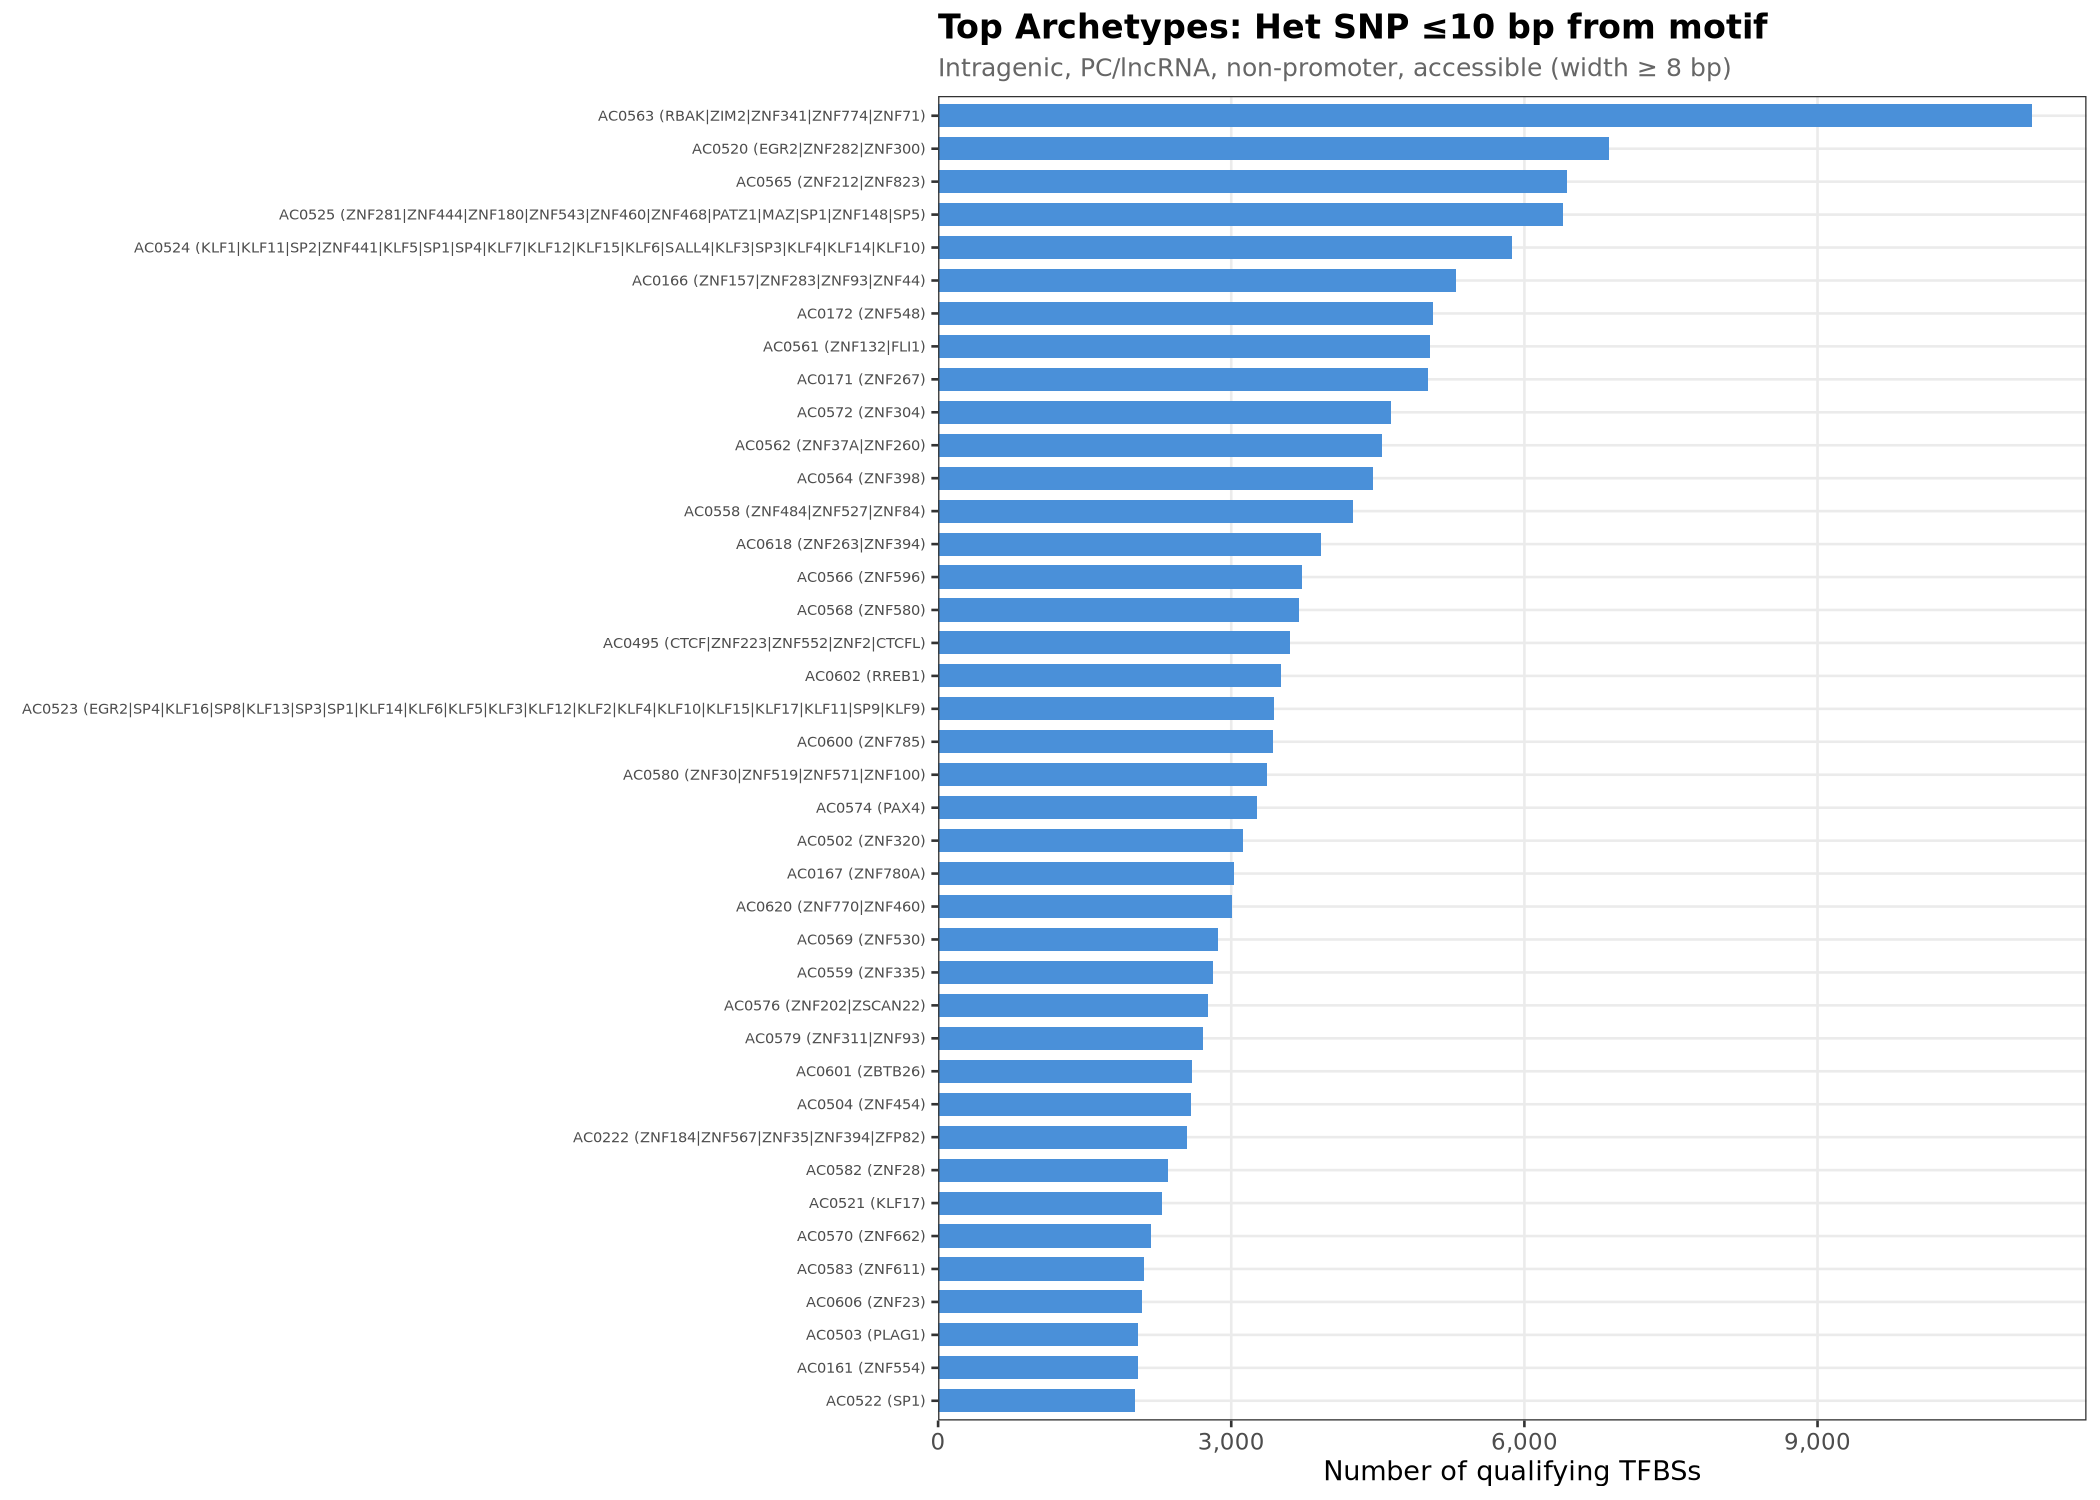

In [48]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 11: Top archetypes ranked — CHOOSE THRESHOLD                     ║
# ║  Change SNP_THRESH to generate each version: "overlap","10bp",          ║
# ║  "25bp","50bp","100bp"                                                  ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

## === CHANGE THIS to switch versions ===
SNP_THRESH <- "10bp"   # one of: "overlap", "10bp", "25bp", "50bp", "100bp"

thresh_map <- list(
    "overlap" = list(col = "n_snp_overlap", label = "Het SNP overlaps motif"),
    "10bp"    = list(col = "n_snp_10bp",    label = "Het SNP \u226410 bp from motif"),
    "25bp"    = list(col = "n_snp_25bp",    label = "Het SNP \u226425 bp from motif"),
    "50bp"    = list(col = "n_snp_50bp",    label = "Het SNP \u226450 bp from motif"),
    "100bp"   = list(col = "n_snp_100bp",   label = "Het SNP \u2264100 bp from motif")
)

tv <- thresh_map[[SNP_THRESH]]
col_name <- tv$col
thresh_label <- tv$label

top_r <- head(arch_sum[get(col_name) > 0][order(-get(col_name))], TOP_N)
top_r[, display := paste0(archetype, " (", tf_names, ")")]
top_r[, display := factor(display, levels = top_r[order(get(col_name))]$display)]

p <- ggplot(top_r, aes(x = display, y = get(col_name))) +
    geom_bar(stat = "identity", width = 0.7, fill = "#4a90d9") +
    scale_y_continuous(labels = comma, expand = expansion(mult = c(0, 0.05))) +
    coord_flip() +
    labs(title = paste0("Top Archetypes: ", thresh_label),
         subtitle = paste0("Intragenic, PC/lncRNA, non-promoter, accessible",
                           " (width \u2265 ", MIN_WIDTH, " bp)"),
         x = NULL, y = "Number of qualifying TFBSs") +
    THEME +
    theme(axis.text.y = element_text(size = Y_AXIS_ARCH_SIZE))
print(p)

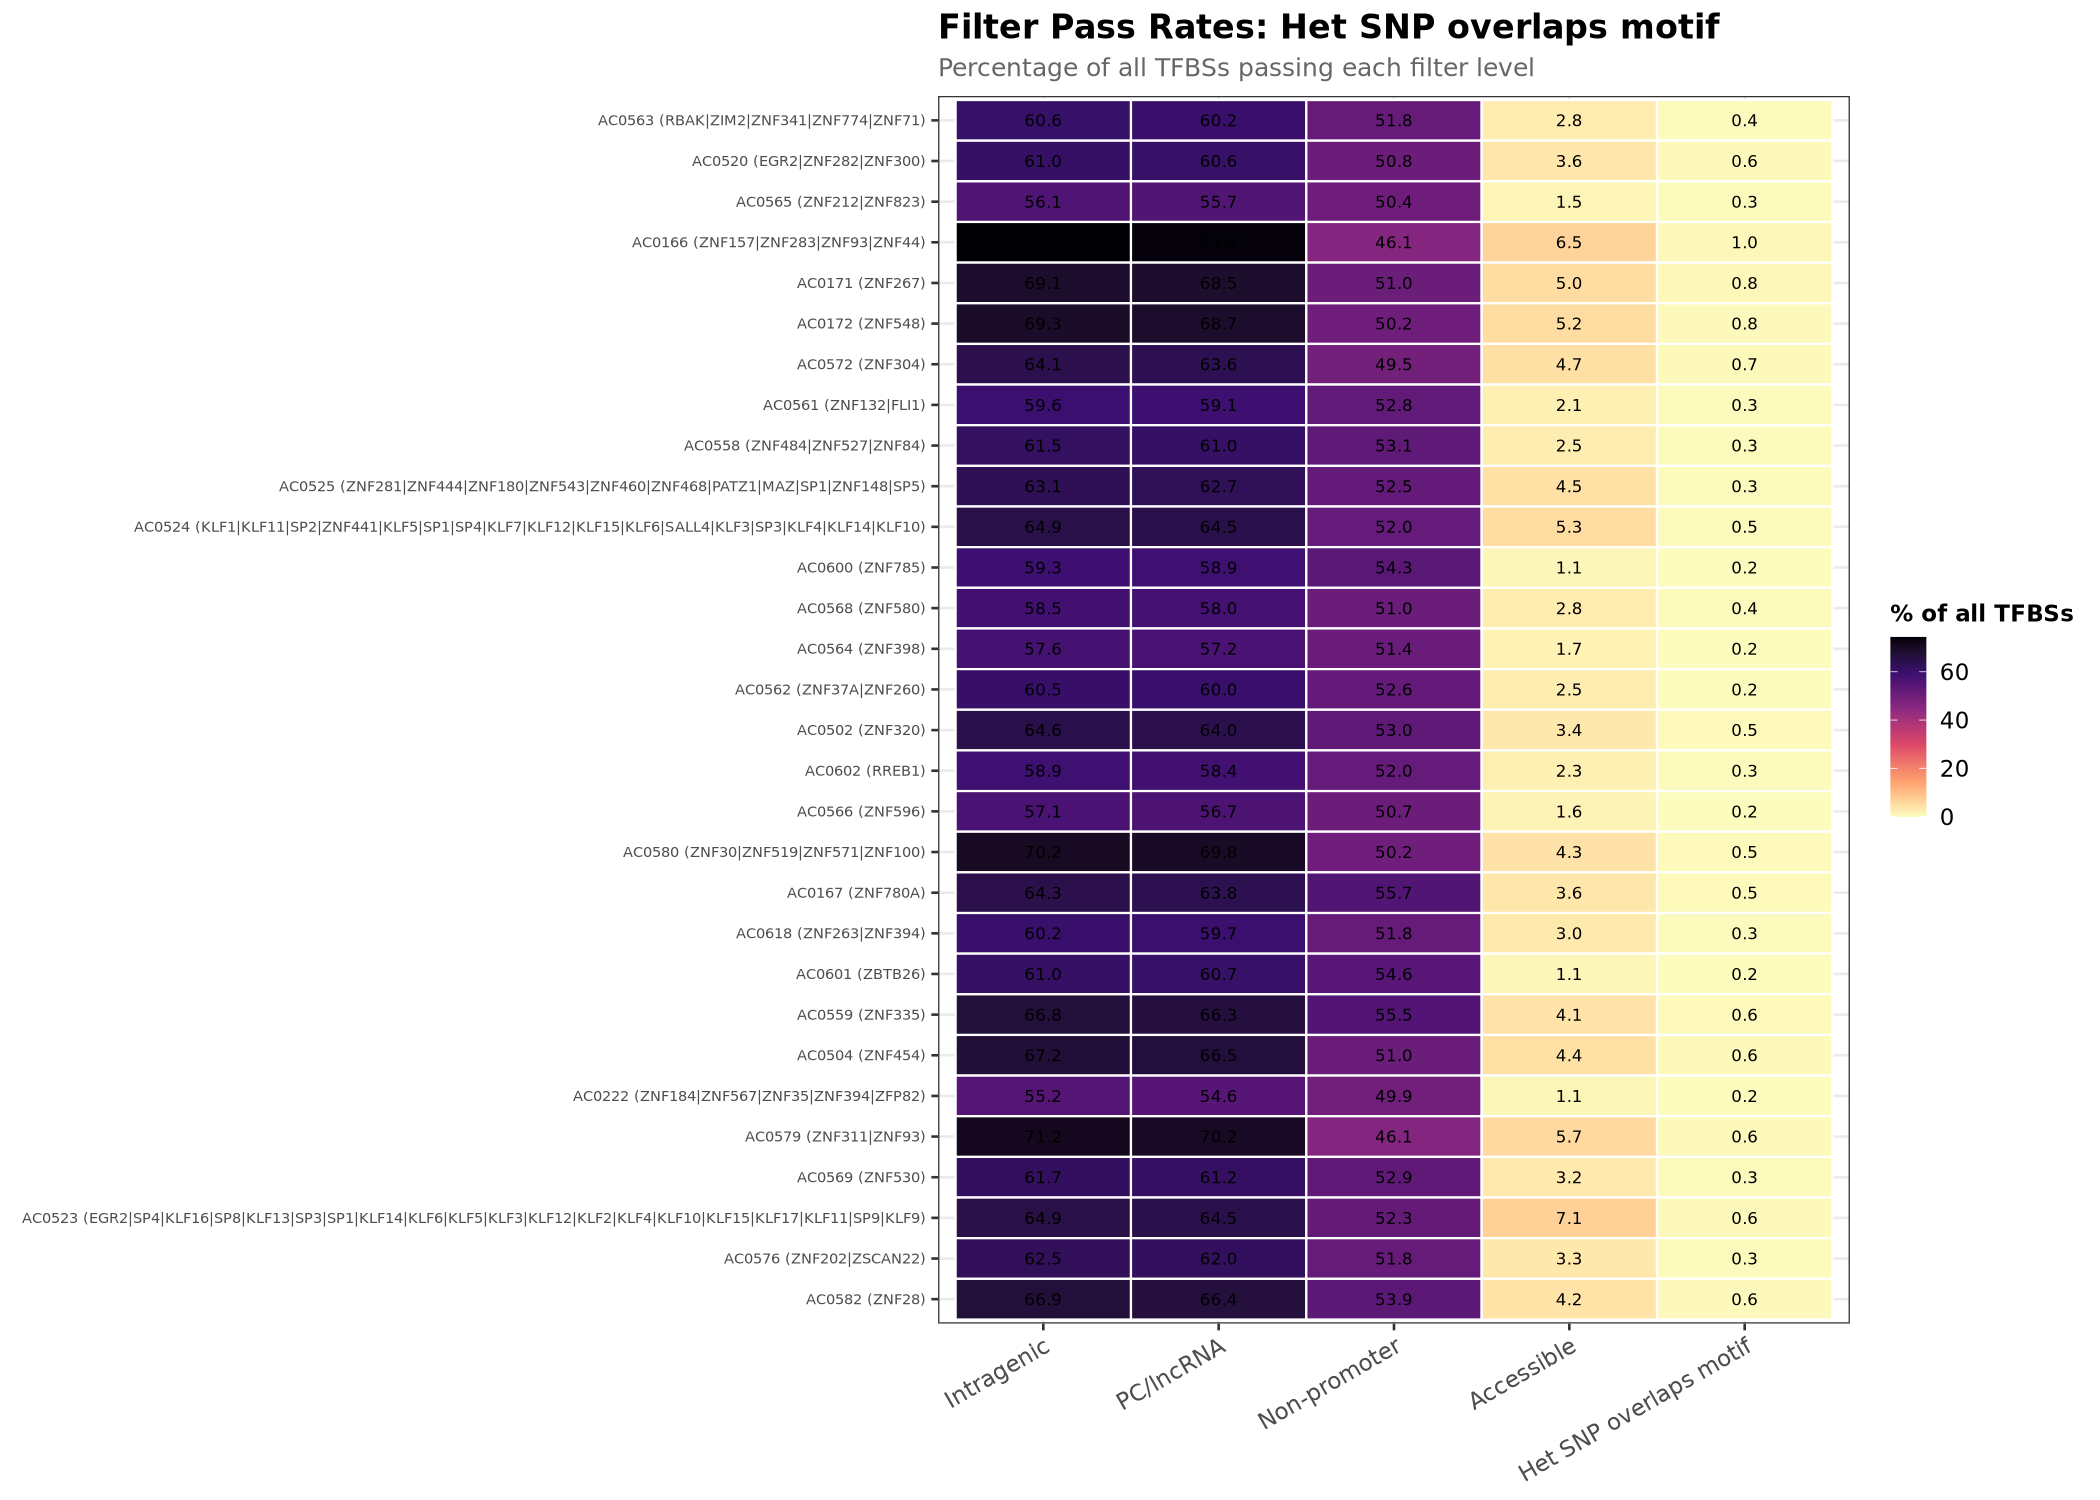

In [26]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 12: Pass-rate heatmap — CHOOSE THRESHOLD                         ║
# ║  Uses same SNP_THRESH from Cell 11 (re-run Cell 11 first to change)    ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

top_h <- head(arch_sum[get(col_name) > 0][order(-get(col_name))], 30)
top_h[, `:=`(
    pct_intragenic  = n_intragenic / n_total * 100,
    pct_pcl         = n_intragenic_pcl / n_total * 100,
    pct_nonpromoter = n_intragenic_nonpromoter / n_total * 100,
    pct_accessible  = n_accessible / n_total * 100,
    pct_ready       = get(col_name) / n_total * 100
)]

heat_l <- melt(top_h,
    id.vars = c("archetype", "tf_names"),
    measure.vars = c("pct_intragenic", "pct_pcl", "pct_nonpromoter",
                      "pct_accessible", "pct_ready"),
    variable.name = "filter", value.name = "pct"
)
heat_l[, filter_label := fcase(
    filter == "pct_intragenic",  "Intragenic",
    filter == "pct_pcl",         "PC/lncRNA",
    filter == "pct_nonpromoter", "Non-promoter",
    filter == "pct_accessible",  "Accessible",
    filter == "pct_ready",       thresh_label
)]
heat_l[, filter_label := factor(filter_label,
    levels = c("Intragenic", "PC/lncRNA", "Non-promoter",
               "Accessible", thresh_label))]

heat_l[, display := paste0(archetype, " (", tf_names, ")")]
arch_h_order <- top_h[order(get(col_name))]$archetype
heat_display_order <- paste0(arch_h_order, " (",
    top_h[match(arch_h_order, archetype)]$tf_names, ")")
heat_l[, display := factor(display, levels = heat_display_order)]

HEATMAP_TEXT_SIZE <- 2.8   # tune this

p <- ggplot(heat_l, aes(x = filter_label, y = display, fill = pct)) +
    geom_tile(color = "white", linewidth = 0.5) +
    geom_text(aes(label = sprintf("%.1f", pct)), size = HEATMAP_TEXT_SIZE) +
    scale_fill_viridis_c(option = "magma", direction = -1,
                          name = "% of all TFBSs", limits = c(0, NA)) +
    labs(title = paste0("Filter Pass Rates: ", thresh_label),
         subtitle = "Percentage of all TFBSs passing each filter level",
         x = NULL, y = NULL) +
    THEME +
    theme(axis.text.y = element_text(size = Y_AXIS_ARCH_SIZE),
          axis.text.x = element_text(angle = 30, hjust = 1, size = AXIS_TEXT_SIZE))
print(p)


In [6]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  CELL S: (OPTIONAL) Load per-TFBS score & SNP count data               ║
# ║  This is slower (reads individual archetype files) — run once, then     ║
# ║  iterate on Cells 13-15 without re-running this.                        ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

cat("Loading per-TFBS data from annotation files...\n")
cat("(This may take a few minutes depending on number of archetypes)\n")

if (!exists("arch_tf_map")) {
    meta <- fread(METADATA_TSV)
    arch_tf_map <- meta[, .(tf_names = paste(unique(tf_name), collapse = "|")),
                         by = cluster]
}

# Only load archetypes with analysis-ready TFBSs
archs_to_load <- arch_sum[n_snp_overlap > 0]$archetype

flank_overlap_cols <- paste0(SNP_PREFIX, "_flank", c(10, 25, 50, 100), "bp_overlap")
flank_count_cols   <- paste0(SNP_PREFIX, "_flank", c(10, 25, 50, 100), "bp_count")
load_cols <- c("score", SNP_COL, SNP_COUNT_COL,
               flank_overlap_cols, flank_count_cols, ATAC_COLS,
               "is_intragenic", "is_promoter", "intragenic_gene_types")

score_list <- list()
score_all_list <- list()
snp_cumul_list <- list()

flank10_col  <- paste0(SNP_PREFIX, "_flank10bp_overlap")
flank25_col  <- paste0(SNP_PREFIX, "_flank25bp_overlap")
flank50_col  <- paste0(SNP_PREFIX, "_flank50bp_overlap")
flank100_col <- paste0(SNP_PREFIX, "_flank100bp_overlap")

cat("Loading", length(archs_to_load), "archetype files...\n")
t0 <- Sys.time()

for (ii in seq_along(archs_to_load)) {
    arch_id <- archs_to_load[ii]
    if (ii %% 25 == 1) cat("  ", ii, "/", length(archs_to_load), ": ", arch_id, "\n")

    f <- file.path(ANNOT_DIR, paste0(arch_id, "_annotated.tsv.gz"))
    if (!file.exists(f)) next

    dt <- fread(f, select = load_cols)
    if (nrow(dt) == 0) next

    # All scores for comparison
    score_all_list[[arch_id]] <- data.table(archetype = arch_id, score = dt$score)

    # Filter to accessible, intragenic, non-promoter, PC/lncRNA
    dt <- dt[is_intragenic == TRUE &
             is_promoter == FALSE &
             (grepl("protein_coding", intragenic_gene_types, fixed = TRUE) |
              grepl("lncRNA", intragenic_gene_types, fixed = TRUE))]
    if (nrow(dt) == 0) next

    if (all(ATAC_COLS %in% names(dt))) {
        dt[, accessible := Reduce(`|`, .SD), .SDcols = ATAC_COLS]
    } else {
        dt[, accessible := FALSE]
    }
    dt <- dt[accessible == TRUE]
    if (nrow(dt) == 0) next

    # Cumulative flags
    dt[, snp_within_0   := get(SNP_COL) == TRUE]
    dt[, snp_within_10  := snp_within_0 | (get(flank10_col) == TRUE)]
    dt[, snp_within_25  := snp_within_10 | (get(flank25_col) == TRUE)]
    dt[, snp_within_50  := snp_within_25 | (get(flank50_col) == TRUE)]
    dt[, snp_within_100 := snp_within_50 | (get(flank100_col) == TRUE)]

    # Scores for SNP-overlapping TFBSs
    if (sum(dt$snp_within_0) > 0) {
        score_list[[arch_id]] <- data.table(
            archetype = arch_id,
            score = dt[snp_within_0 == TRUE]$score
        )
    }

    # Cumulative SNP counts at each threshold
    for (dist_val in c("0", "10", "25", "50", "100")) {
        flag_col <- paste0("snp_within_", dist_val)
        ready_dt <- dt[get(flag_col) == TRUE]
        if (nrow(ready_dt) == 0) next

        # Sum counts from direct + all flanking bins up to this distance
        count_cols_to_sum <- SNP_COUNT_COL
        if (dist_val != "0") {
            dists_included <- c(10, 25, 50, 100)
            dists_included <- dists_included[dists_included <= as.integer(dist_val)]
            for (d in dists_included) {
                count_cols_to_sum <- c(count_cols_to_sum,
                                        paste0(SNP_PREFIX, "_flank", d, "bp_count"))
            }
        }
        avail <- intersect(count_cols_to_sum, names(ready_dt))
        total_snps <- if (length(avail) > 1) {
            rowSums(ready_dt[, ..avail])
        } else {
            ready_dt[[avail]]
        }

        key <- paste0(arch_id, "_", dist_val)
        snp_cumul_list[[key]] <- data.table(
            archetype = arch_id,
            snp_dist = dist_val,
            snp_count = total_snps
        )
    }
}

scores_ready <- rbindlist(score_list)
scores_all   <- rbindlist(score_all_list)
snp_counts_cumul <- rbindlist(snp_cumul_list)

t1 <- Sys.time()
cat("\nDone in", round(difftime(t1, t0, units = "secs"), 1), "seconds.\n")
cat("scores_ready:", nrow(scores_ready), "rows\n")
cat("scores_all:  ", nrow(scores_all), "rows\n")
cat("snp_counts:  ", nrow(snp_counts_cumul), "rows\n")
cat("\nNow you can run Cells 13-15.\n")


Loading per-TFBS data from annotation files...
(This may take a few minutes depending on number of archetypes)
Loading 586 archetype files...


   1 / 586 :  AC0563 
   26 / 586 :  AC0579 
   51 / 586 :  AC0306 
   76 / 586 :  AC0381 
   101 / 586 :  AC0112 
   126 / 586 :  AC0164 
   151 / 586 :  AC0462 
   176 / 586 :  AC0609 
   201 / 586 :  AC0292 
   226 / 586 :  AC0517 
   251 / 586 :  AC0264 
   276 / 586 :  AC0510 
   301 / 586 :  AC0501 
   326 / 586 :  AC0337 
   351 / 586 :  AC0554 
   376 / 586 :  AC0308 
   401 / 586 :  AC0485 
   426 / 586 :  AC0633 
   451 / 586 :  AC0549 
   476 / 586 :  AC0081 
   501 / 586 :  AC0040 
   526 / 586 :  AC0325 
   551 / 586 :  AC0628 
   576 / 586 :  AC0650 

Done in 375.2 seconds.
scores_ready: 185581 rows
scores_all:   74609539 rows
snp_counts:   3293901 rows

Now you can run Cells 13-15.


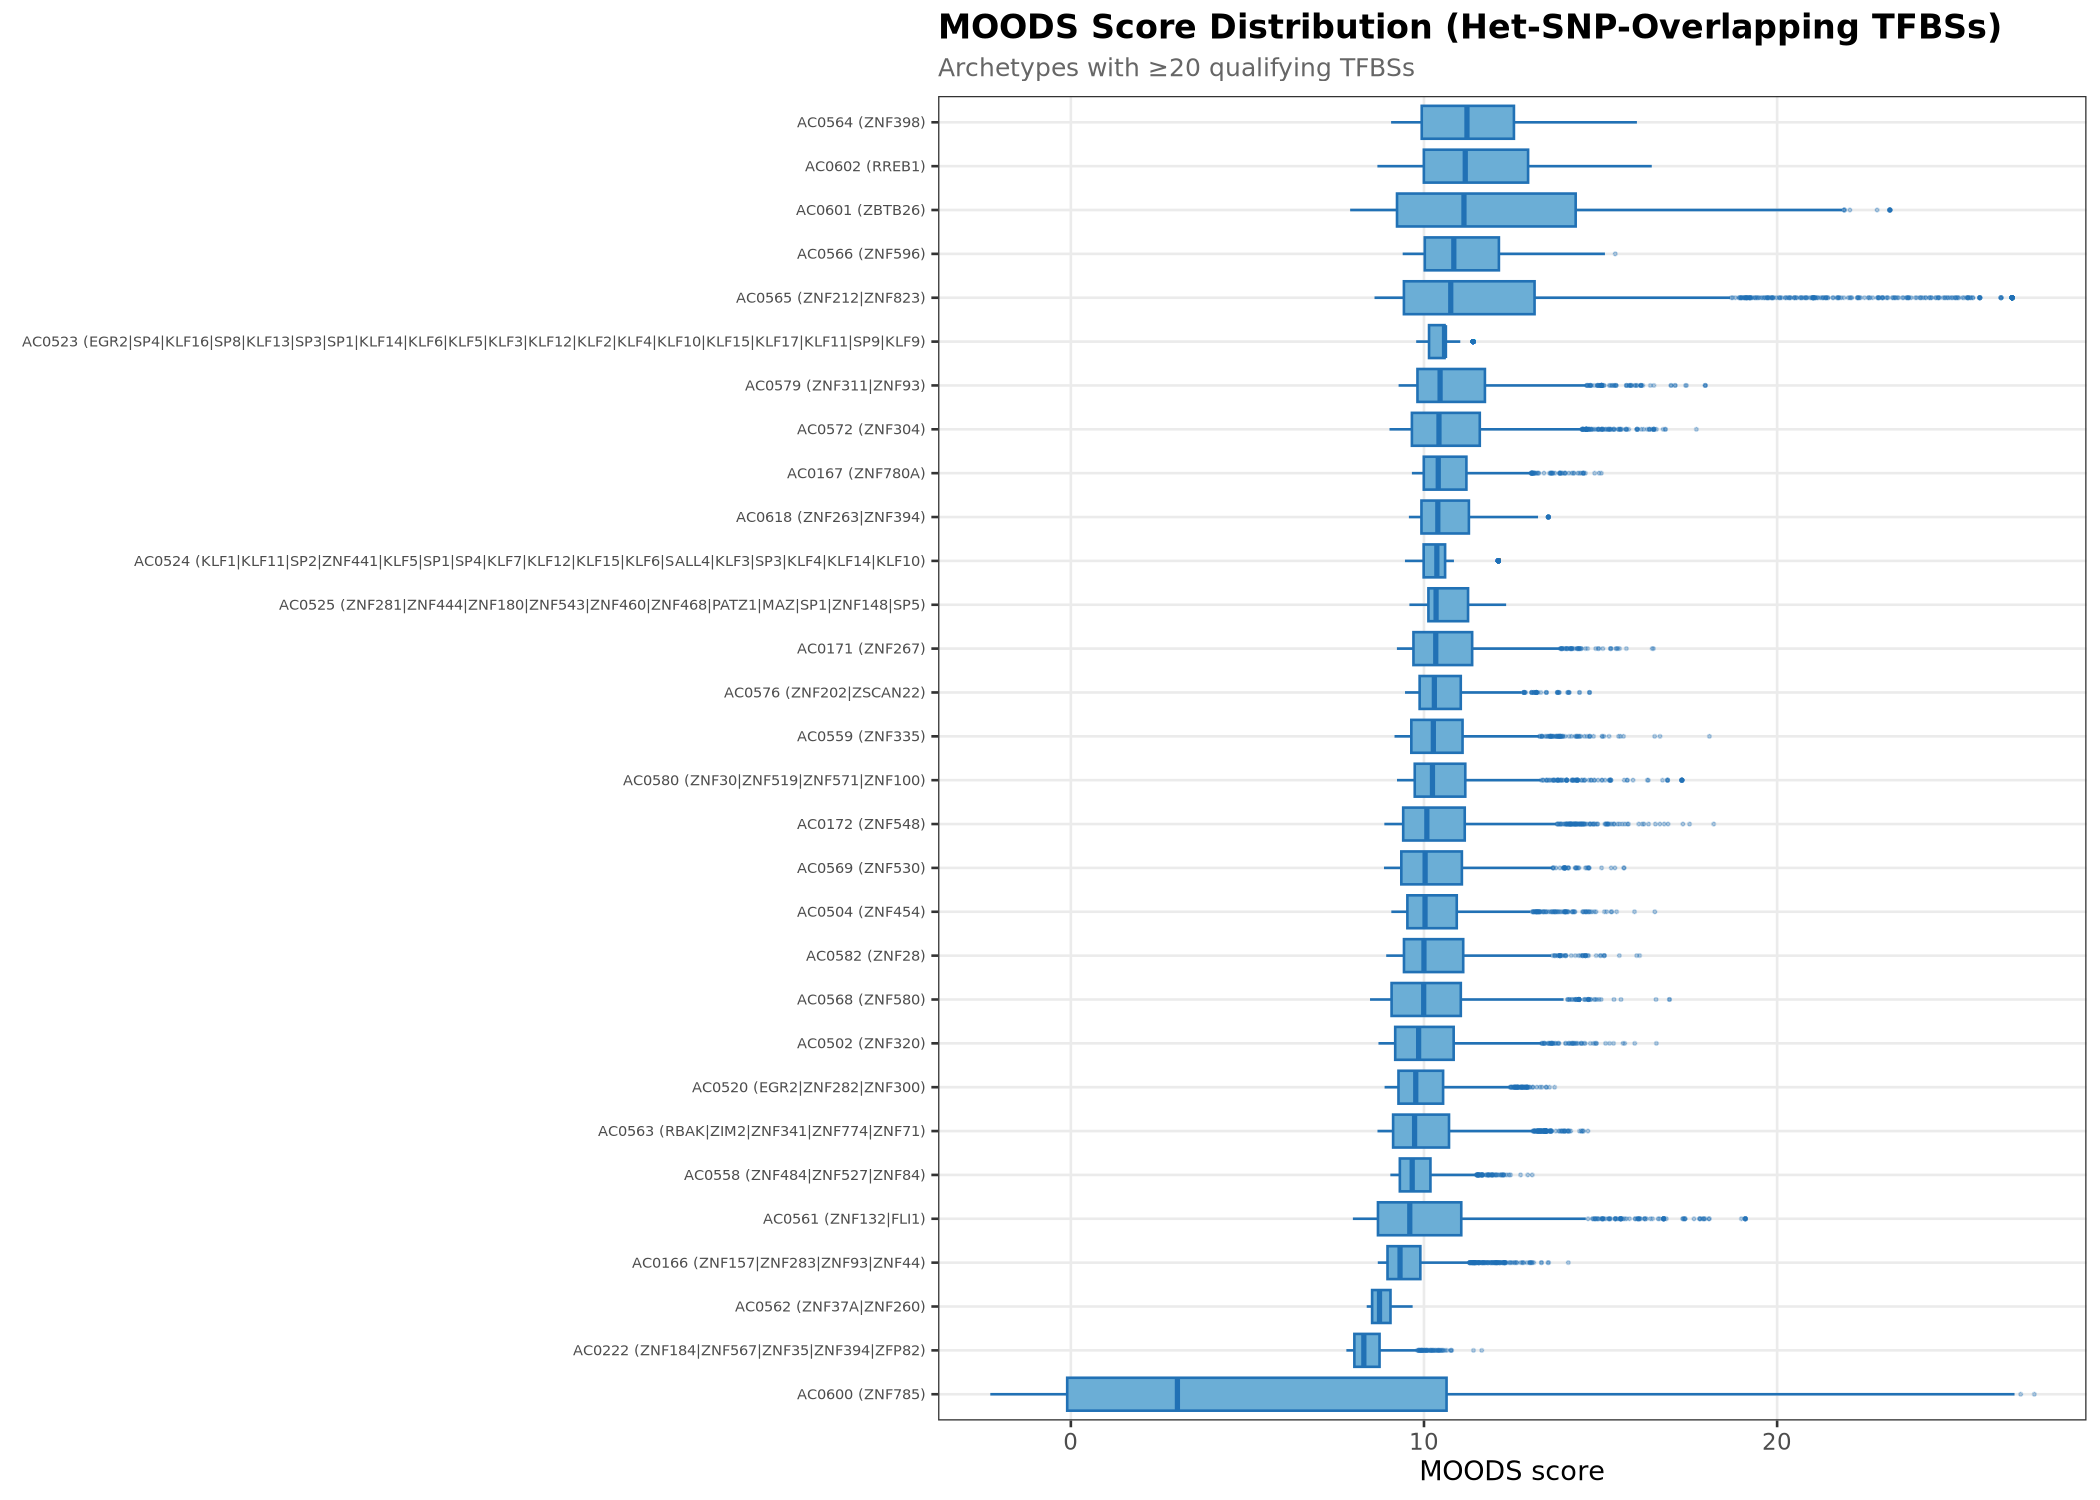

In [7]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 13: MOODS score boxplots (uniform color)                         ║
# ║  ** REQUIRES per-TFBS data — see Cell S below to load it **            ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

# This cell needs `scores_ready` from Cell S.
# If you haven't run Cell S, skip this or run it first.

if (exists("scores_ready") && nrow(scores_ready) > 0) {
    MIN_FOR_SCORE_DIST <- 20

    # Load tf_names mapping
    if (!exists("arch_tf_map")) {
        meta <- fread(METADATA_TSV)
        arch_tf_map <- meta[, .(tf_names = paste(unique(tf_name), collapse = "|")),
                             by = cluster]
    }

    score_arch_counts <- scores_ready[, .N, by = archetype][order(-N)]
    top_score_arch <- head(score_arch_counts[N >= MIN_FOR_SCORE_DIST], 30)

    scores_plot <- scores_ready[archetype %in% top_score_arch$archetype]
    scores_plot <- merge(scores_plot, arch_tf_map, by.x = "archetype",
                          by.y = "cluster", all.x = TRUE)
    scores_plot[, display := paste0(archetype, " (", tf_names, ")")]

    med_scores <- scores_plot[, .(med = median(score)), by = display]
    scores_plot[, display := factor(display,
        levels = med_scores[order(med)]$display)]

    MOODS_FILL   <- "#6baed6"    # tune
    MOODS_BORDER <- "#2171b5"    # tune

    p <- ggplot(scores_plot, aes(x = display, y = score)) +
        geom_boxplot(fill = MOODS_FILL, color = MOODS_BORDER,
                     outlier.size = 0.5, outlier.alpha = 0.3) +
        coord_flip() +
        labs(title = "MOODS Score Distribution (Het-SNP-Overlapping TFBSs)",
             subtitle = paste0("Archetypes with \u2265", MIN_FOR_SCORE_DIST,
                               " qualifying TFBSs"),
             x = NULL, y = "MOODS score") +
        THEME +
        theme(axis.text.y = element_text(size = Y_AXIS_ARCH_SIZE))
    print(p)
} else {
    cat("scores_ready not loaded. Run Cell S first.\n")
}

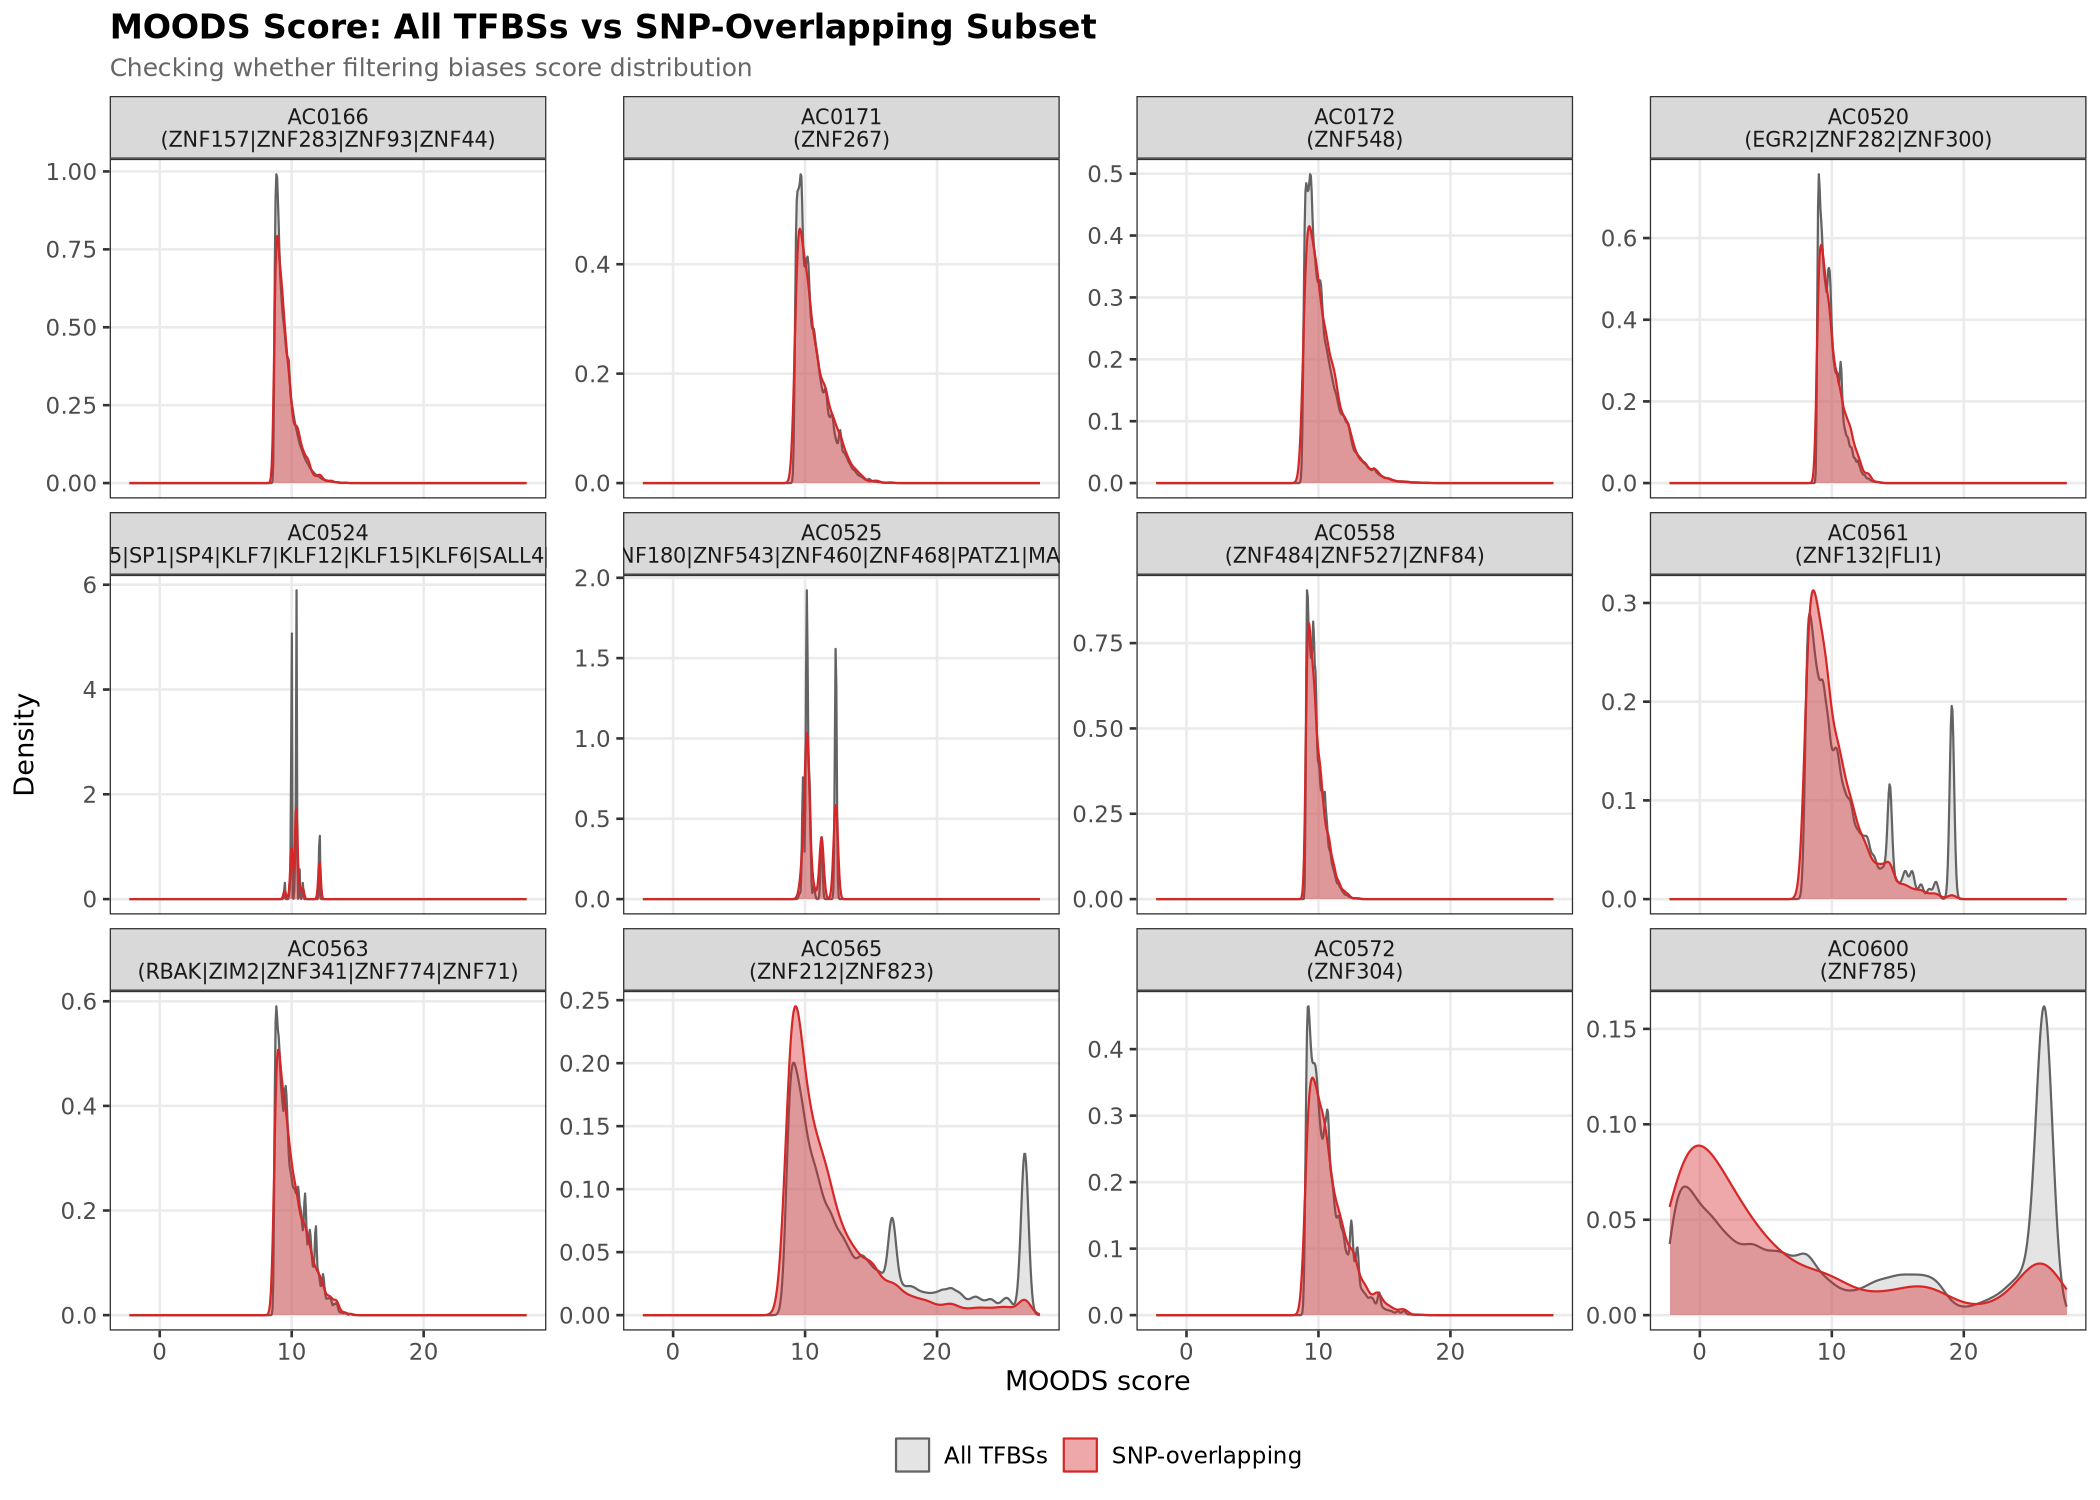

In [31]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 14: Score comparison — all vs analysis-ready                      ║
# ║  ** REQUIRES per-TFBS data — see Cell S below **                        ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

if (exists("scores_ready") && exists("scores_all") &&
    nrow(scores_ready) > 0 && nrow(scores_all) > 0) {

    rep_archetypes <- head(top_score_arch$archetype, 12)
    scores_compare <- rbind(
        scores_all[archetype %in% rep_archetypes][, subset := "All TFBSs"],
        scores_ready[archetype %in% rep_archetypes][, subset := "SNP-overlapping"]
    )
    scores_compare <- merge(scores_compare, arch_tf_map, by.x = "archetype",
                             by.y = "cluster", all.x = TRUE)
    scores_compare[, display := paste0(archetype, "\n(", tf_names, ")")]

    p <- ggplot(scores_compare, aes(x = score, fill = subset, color = subset)) +
        geom_density(alpha = 0.4, linewidth = 0.5) +
        facet_wrap(~ display, scales = "free_y", ncol = 4) +
        scale_fill_manual(values = c("All TFBSs" = "#bdbdbd",
                                      "SNP-overlapping" = "#d62728"), name = NULL) +
        scale_color_manual(values = c("All TFBSs" = "#636363",
                                       "SNP-overlapping" = "#d62728"), name = NULL) +
        labs(title = "MOODS Score: All TFBSs vs SNP-Overlapping Subset",
             subtitle = "Checking whether filtering biases score distribution",
             x = "MOODS score", y = "Density") +
        THEME +
        theme(legend.position = "bottom",
              strip.text = element_text(size = STRIP_SIZE - 1))
    print(p)
} else {
    cat("Score data not loaded. Run Cell S first.\n")
}


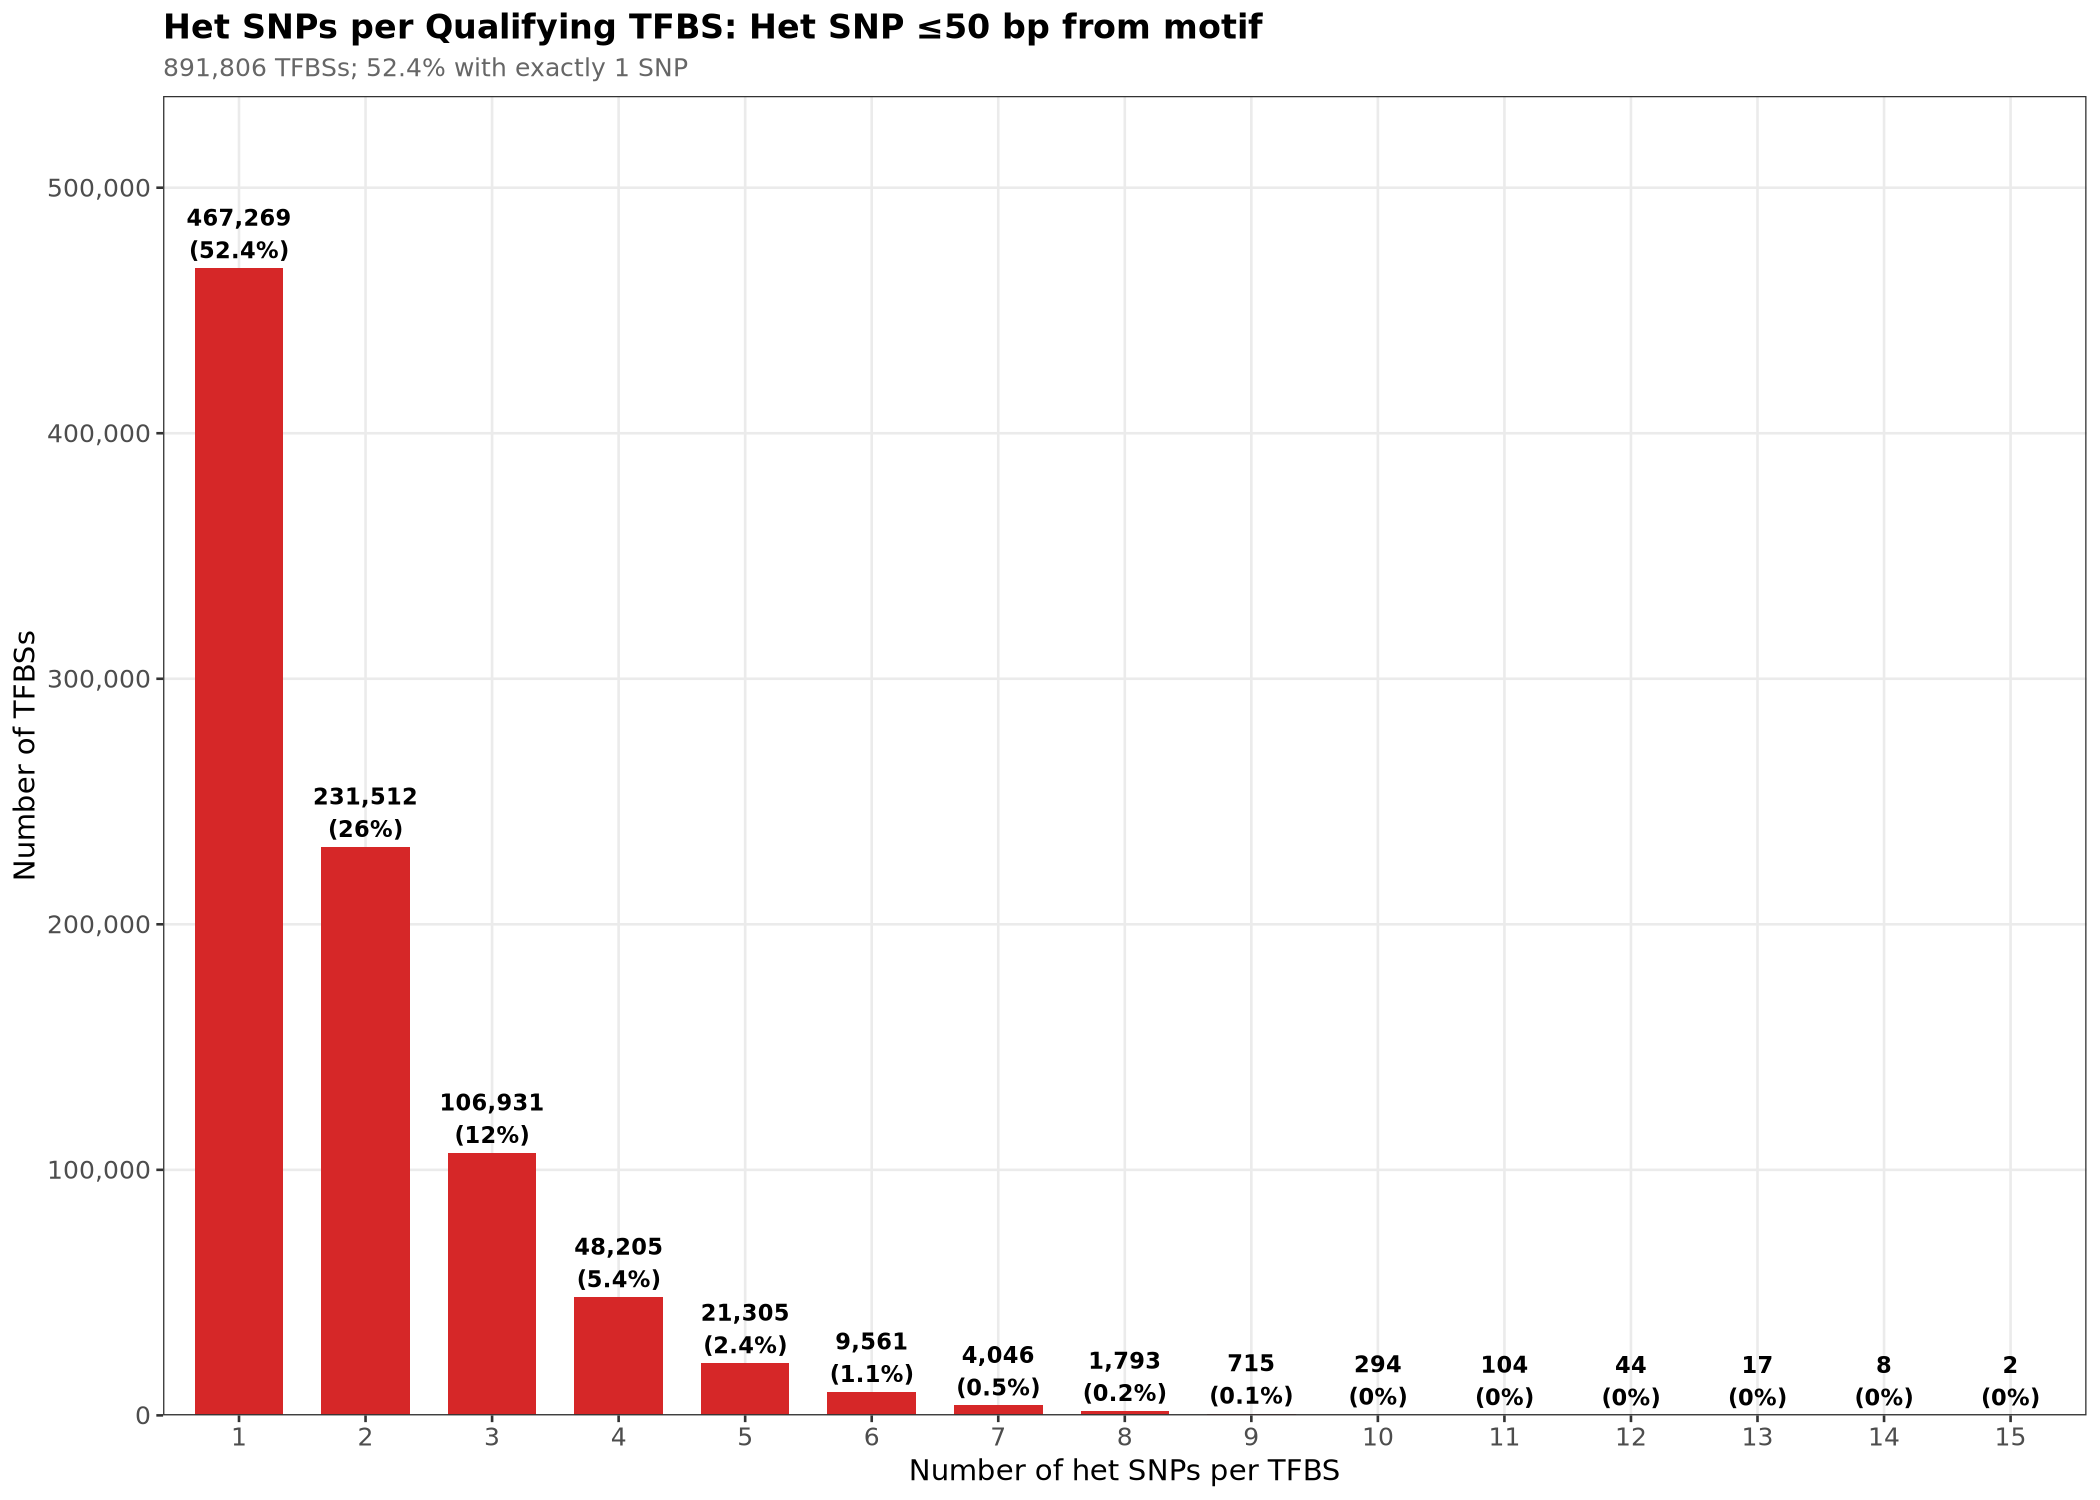

In [17]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 15: SNP count distribution — CHOOSE THRESHOLD                    ║
# ║  ** REQUIRES per-TFBS data — see Cell S below **                        ║
# ║  Change SNP_COUNT_THRESH below                                          ║
# ╚═══════════════════════════════════════════════════════════════════════════╝
## === CHANGE THIS to switch versions ===
SNP_COUNT_THRESH <- "50"  # one of: "0", "10", "25", "50", "100"
if (exists("snp_counts_cumul") && nrow(snp_counts_cumul) > 0) {
    snp_dist_labels <- c(
        "0"   = "Het SNP overlaps motif",
        "10"  = "Het SNP \u226410 bp from motif",
        "25"  = "Het SNP \u226425 bp from motif",
        "50"  = "Het SNP \u226450 bp from motif",
        "100" = "Het SNP \u2264100 bp from motif"
    )
    dist_data <- snp_counts_cumul[snp_dist == SNP_COUNT_THRESH]
    if (nrow(dist_data) > 0) {
        n_total_tfbs <- nrow(dist_data)
        pct_one <- round(100 * mean(dist_data$snp_count == 1), 1)
        count_tab <- dist_data[, .N, by = snp_count][order(snp_count)]
        count_tab[, pct := round(N / sum(N) * 100, 1)]
        
        p <- ggplot(dist_data, aes(x = factor(snp_count))) +
            geom_bar(fill = "#d62728", width = 0.7) +
            geom_text(
                data = count_tab,
                aes(x = factor(snp_count), y = N,
                    label = paste0(comma(N), "\n(", pct, "%)")),
                vjust = -0.2, 
                size = BAR_LABEL_SIZE,  # ← TEXT ON BARS (already controllable)
                fontface = "bold"
            ) +
            scale_y_continuous(labels = comma,
                               expand = expansion(mult = c(0, 0.15))) +
            labs(title = paste0("Het SNPs per Qualifying TFBS: ",
                                snp_dist_labels[SNP_COUNT_THRESH]),
                 subtitle = paste0(comma(n_total_tfbs), " TFBSs; ",
                                   pct_one, "% with exactly 1 SNP"),
                 x = "Number of het SNPs per TFBS",
                 y = "Number of TFBSs") +
            THEME +
            theme(
                # ═══════════════════ FONT SIZE CONTROLS ═══════════════════
                plot.title = element_text(size = 16),        # ← TITLE SIZE
                plot.subtitle = element_text(size = 12),     # ← SUBTITLE SIZE
                axis.title.x = element_text(size = 14),      # ← X-AXIS LABEL SIZE
                axis.title.y = element_text(size = 14),      # ← Y-AXIS LABEL SIZE
                axis.text.x = element_text(size = 12),       # ← X-AXIS TICK LABELS
                axis.text.y = element_text(size = 12)        # ← Y-AXIS TICK LABELS
                # ══════════════════════════════════════════════════════════
            )
        print(p)
        
        # Save the plot to subdirectory
        dir.create("plots", showWarnings = FALSE)
        ggsave(paste0("plots/snp_count_distribution_thresh", SNP_COUNT_THRESH, ".png"), 
               plot = p, 
               width = 14,   # ← PLOT WIDTH (inches)
               height = 6,   # ← PLOT HEIGHT (inches)
               dpi = 300)    # ← RESOLUTION
        
    } else {
        cat("No data for threshold:", SNP_COUNT_THRESH, "\n")
    }
} else {
    cat("snp_counts_cumul not loaded. Run Cell S first.\n")
}

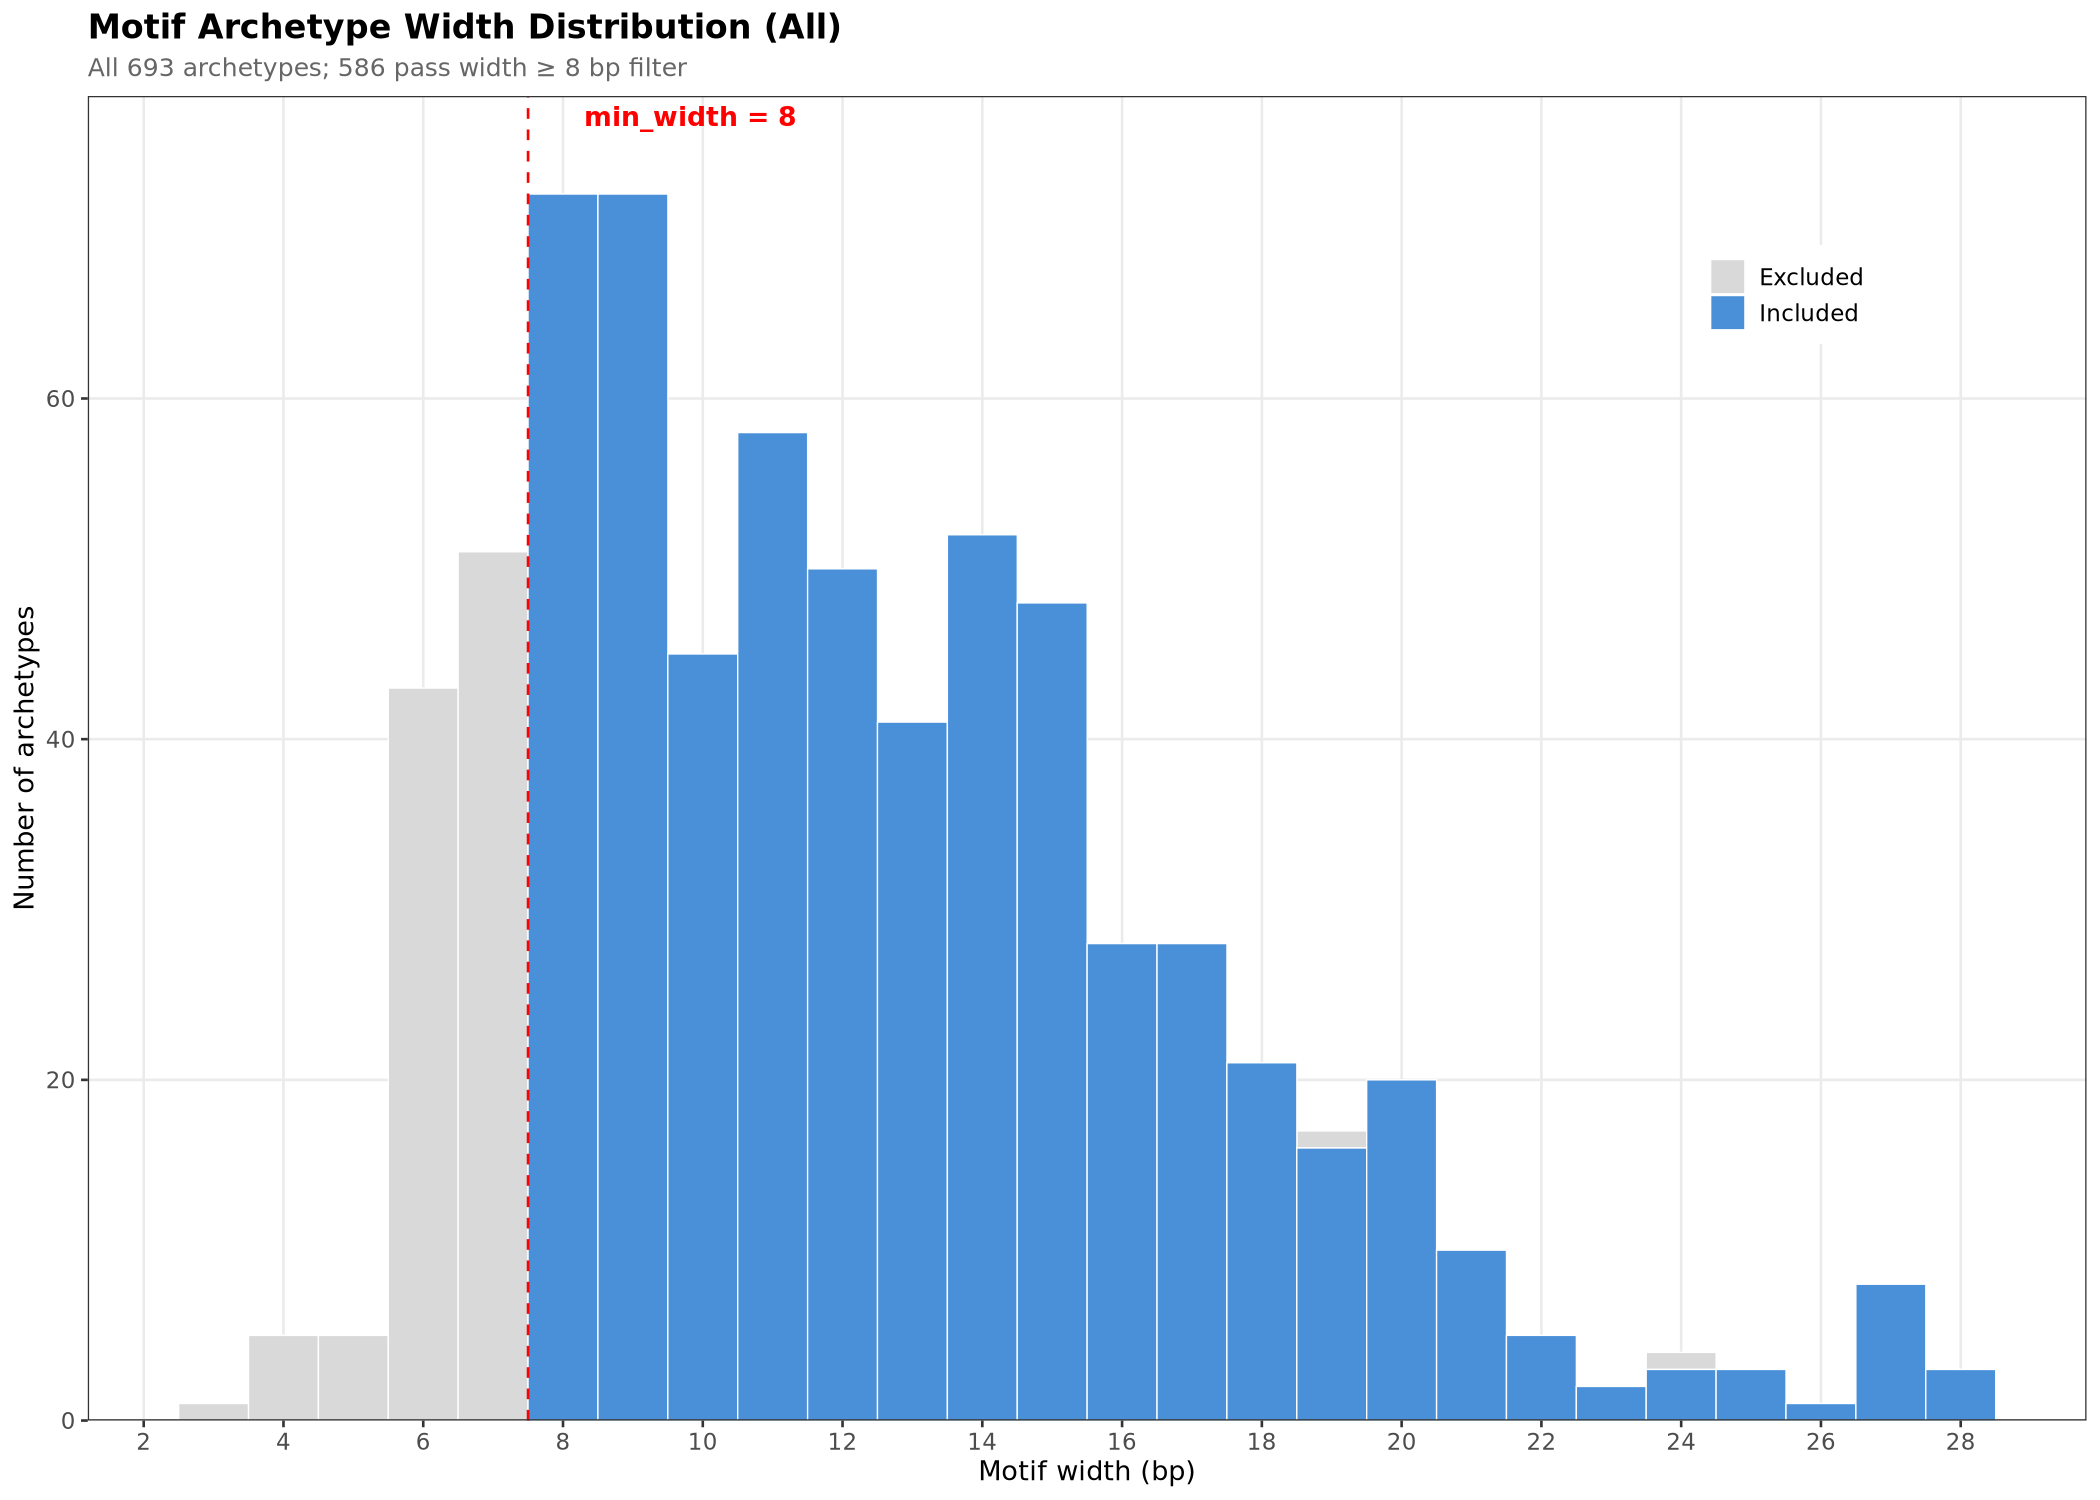

In [19]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 16b: Width distribution — ALL archetypes (included + excluded)    ║
# ║  Requires parsing the MEME file (takes a few seconds)                   ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

parse_meme <- function(meme_path) {
    lines <- readLines(meme_path)
    results <- list()
    i <- 1
    while (i <= length(lines)) {
        line <- trimws(lines[i])
        if (startsWith(line, "MOTIF ")) {
            tokens <- strsplit(sub("^MOTIF\\s+", "", line), ":")[[1]]
            arch_id <- tokens[1]
            i <- i + 1
            while (i <= length(lines) && !grepl("^letter-probability matrix", lines[i]))
                i <- i + 1
            if (i > length(lines)) break
            width <- as.integer(sub(".*w=\\s*(\\d+).*", "\\1", lines[i]))
            # Skip PWM rows
            i <- i + 1 + width
            results[[arch_id]] <- data.table(archetype = arch_id,
                                              motif_width = as.integer(width))
        } else {
            i <- i + 1
        }
    }
    rbindlist(results)
}

pwm_all <- parse_meme(MEME_FILE)
pwm_all[, passed_filter := archetype %in% arch_sum$archetype]

p <- ggplot(pwm_all, aes(x = motif_width, fill = passed_filter)) +
    geom_histogram(binwidth = 1, color = "white", linewidth = 0.3) +
    geom_vline(xintercept = MIN_WIDTH - 0.5, linetype = "dashed",
               color = "red", linewidth = 0.6) +
    annotate("text", x = MIN_WIDTH + 0.3, y = Inf,
             label = paste0("min_width = ", MIN_WIDTH),
             hjust = 0, vjust = 1.5, size = 4.5, color = "red",
             fontface = "bold") +
    scale_fill_manual(values = c("TRUE" = "#4a90d9", "FALSE" = "#d9d9d9"),
                       name = NULL,
                       labels = c("TRUE" = "Included", "FALSE" = "Excluded")) +
    scale_x_continuous(breaks = seq(0, 30, by = 2)) +
    scale_y_continuous(expand = expansion(mult = c(0, 0.08))) +
    labs(title = "Motif Archetype Width Distribution (All)",
         subtitle = paste0("All ", nrow(pwm_all), " archetypes; ",
                           sum(pwm_all$passed_filter), " pass width \u2265 ",
                           MIN_WIDTH, " bp filter"),
         x = "Motif width (bp)", y = "Number of archetypes") +
    THEME +
    theme(legend.position = c(0.85, 0.85))
print(p)


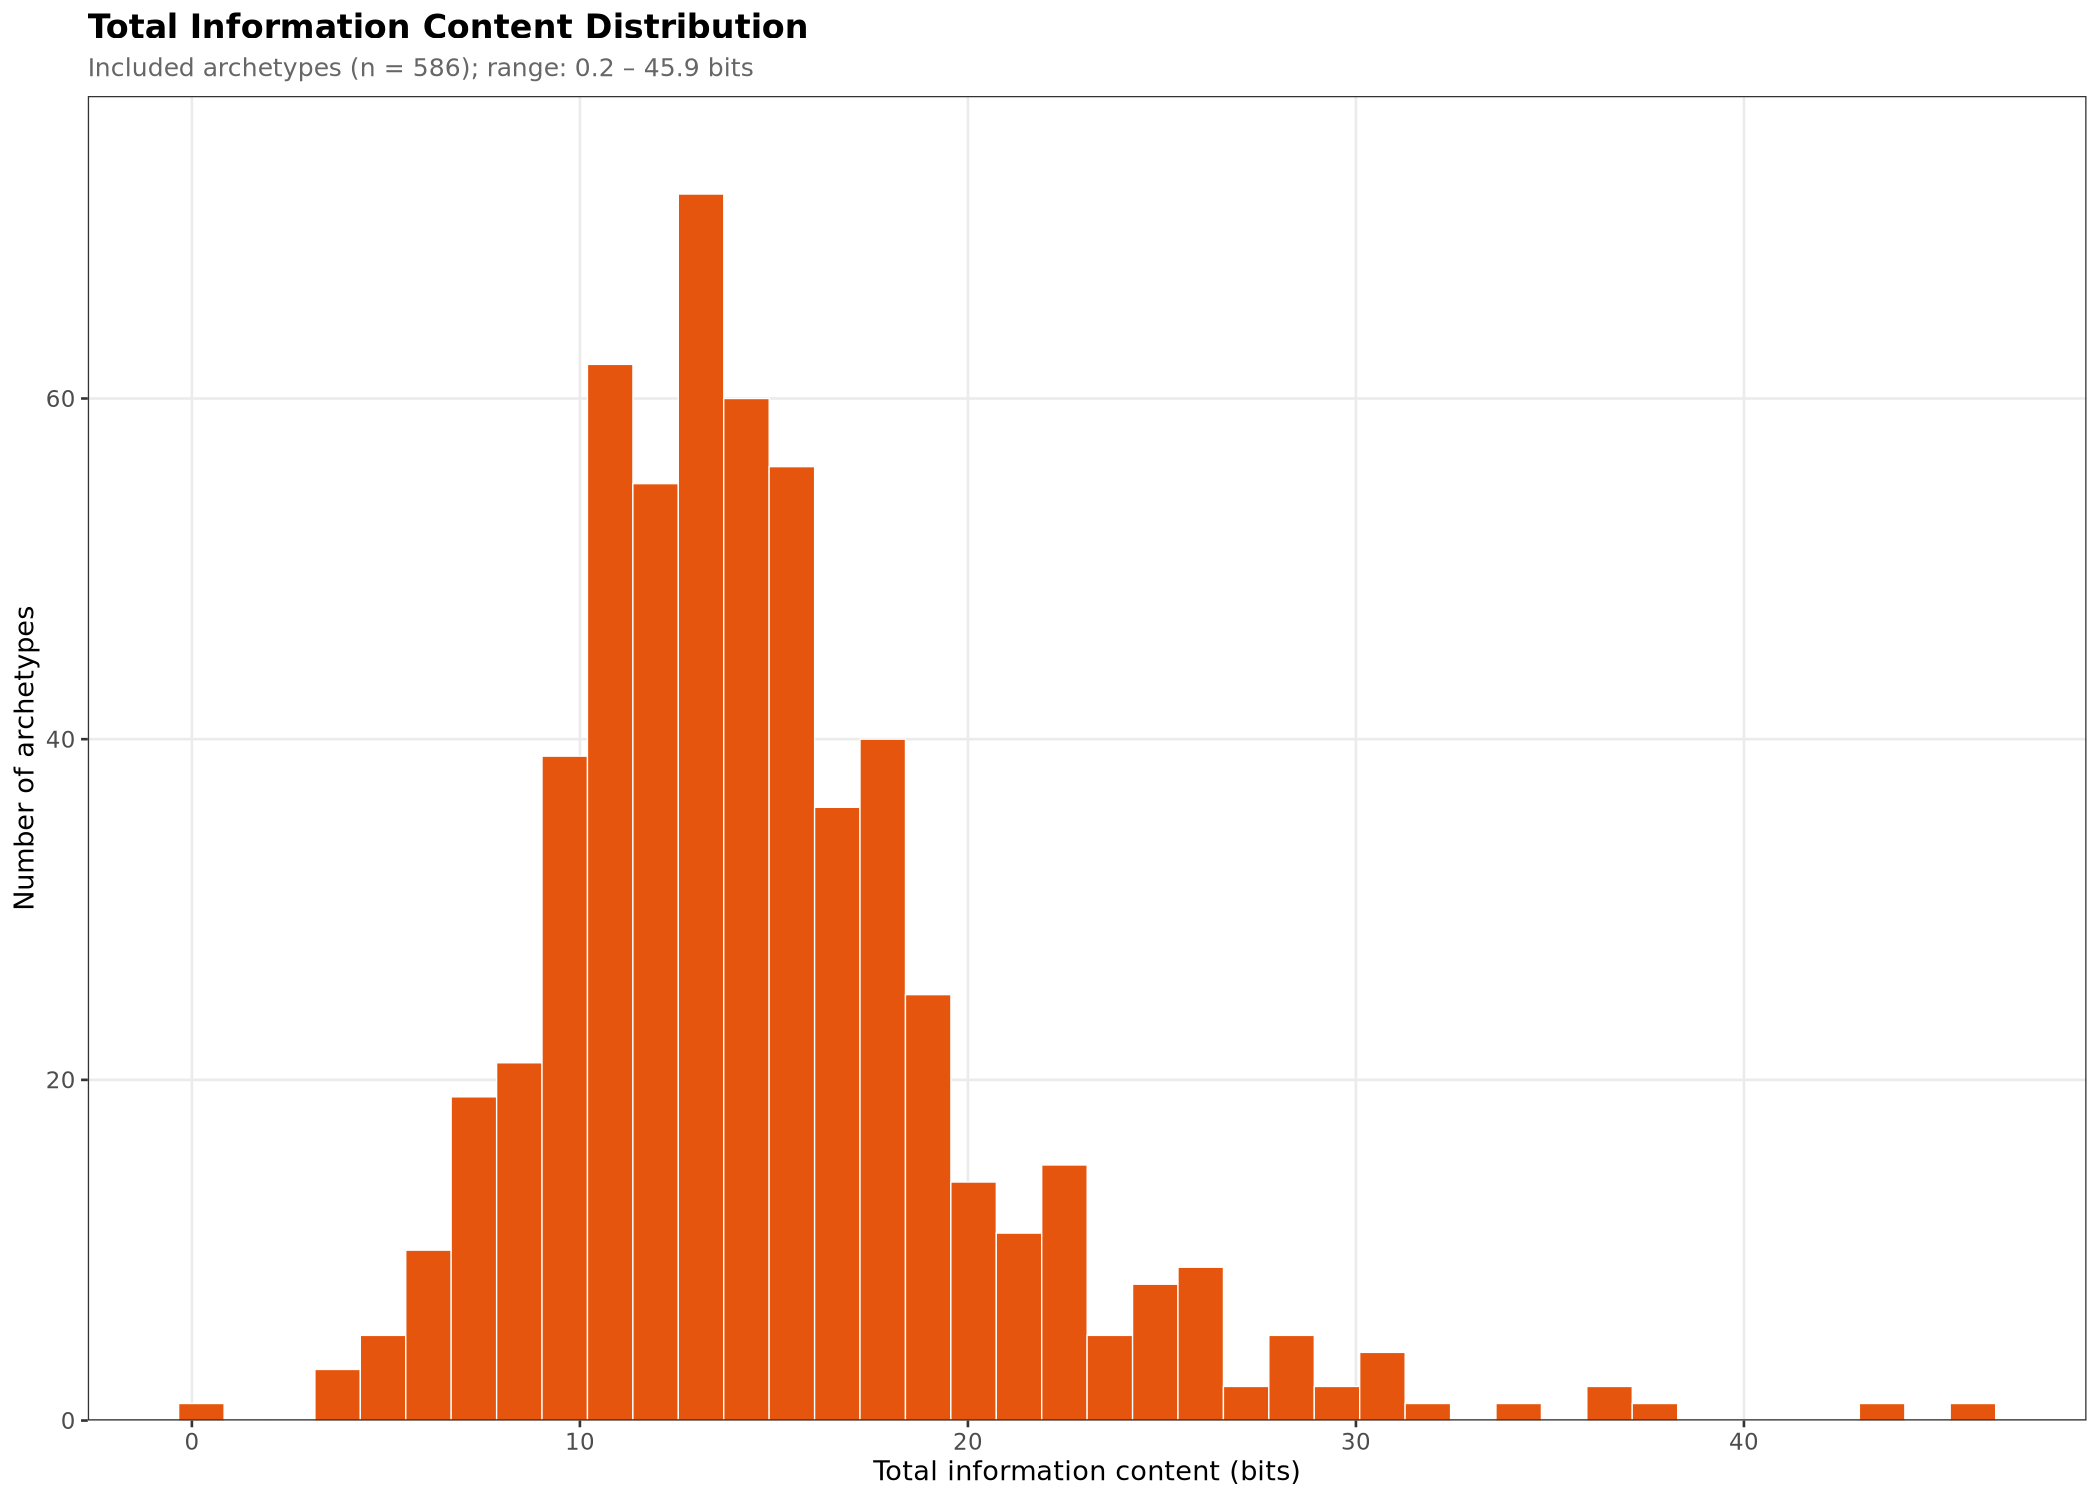

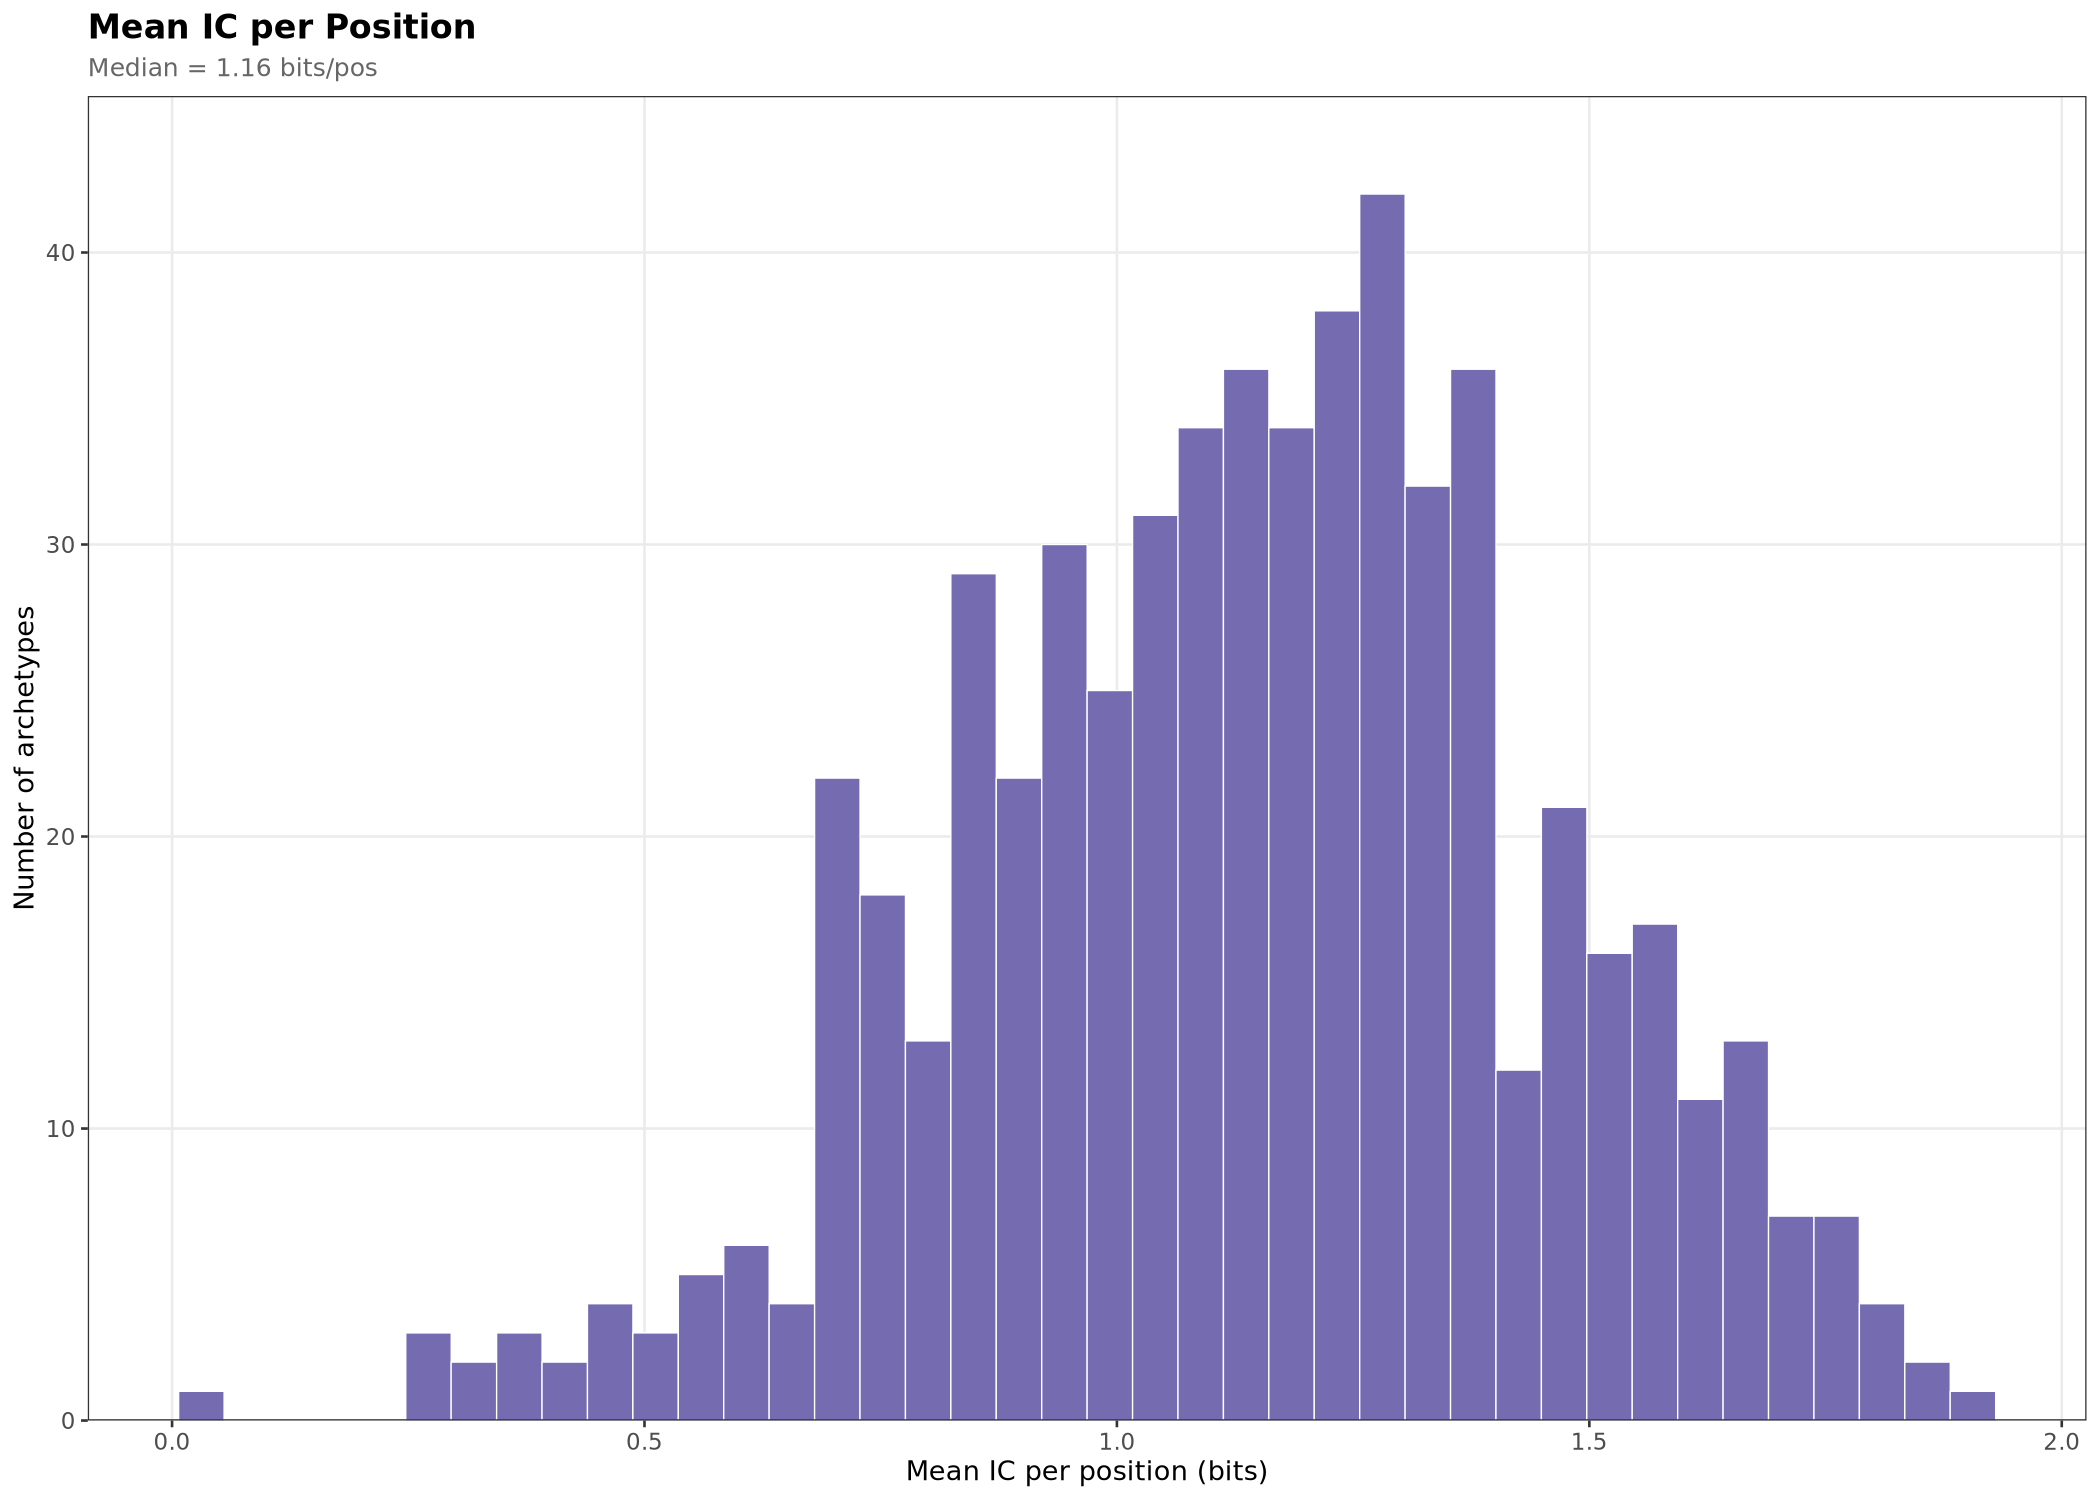

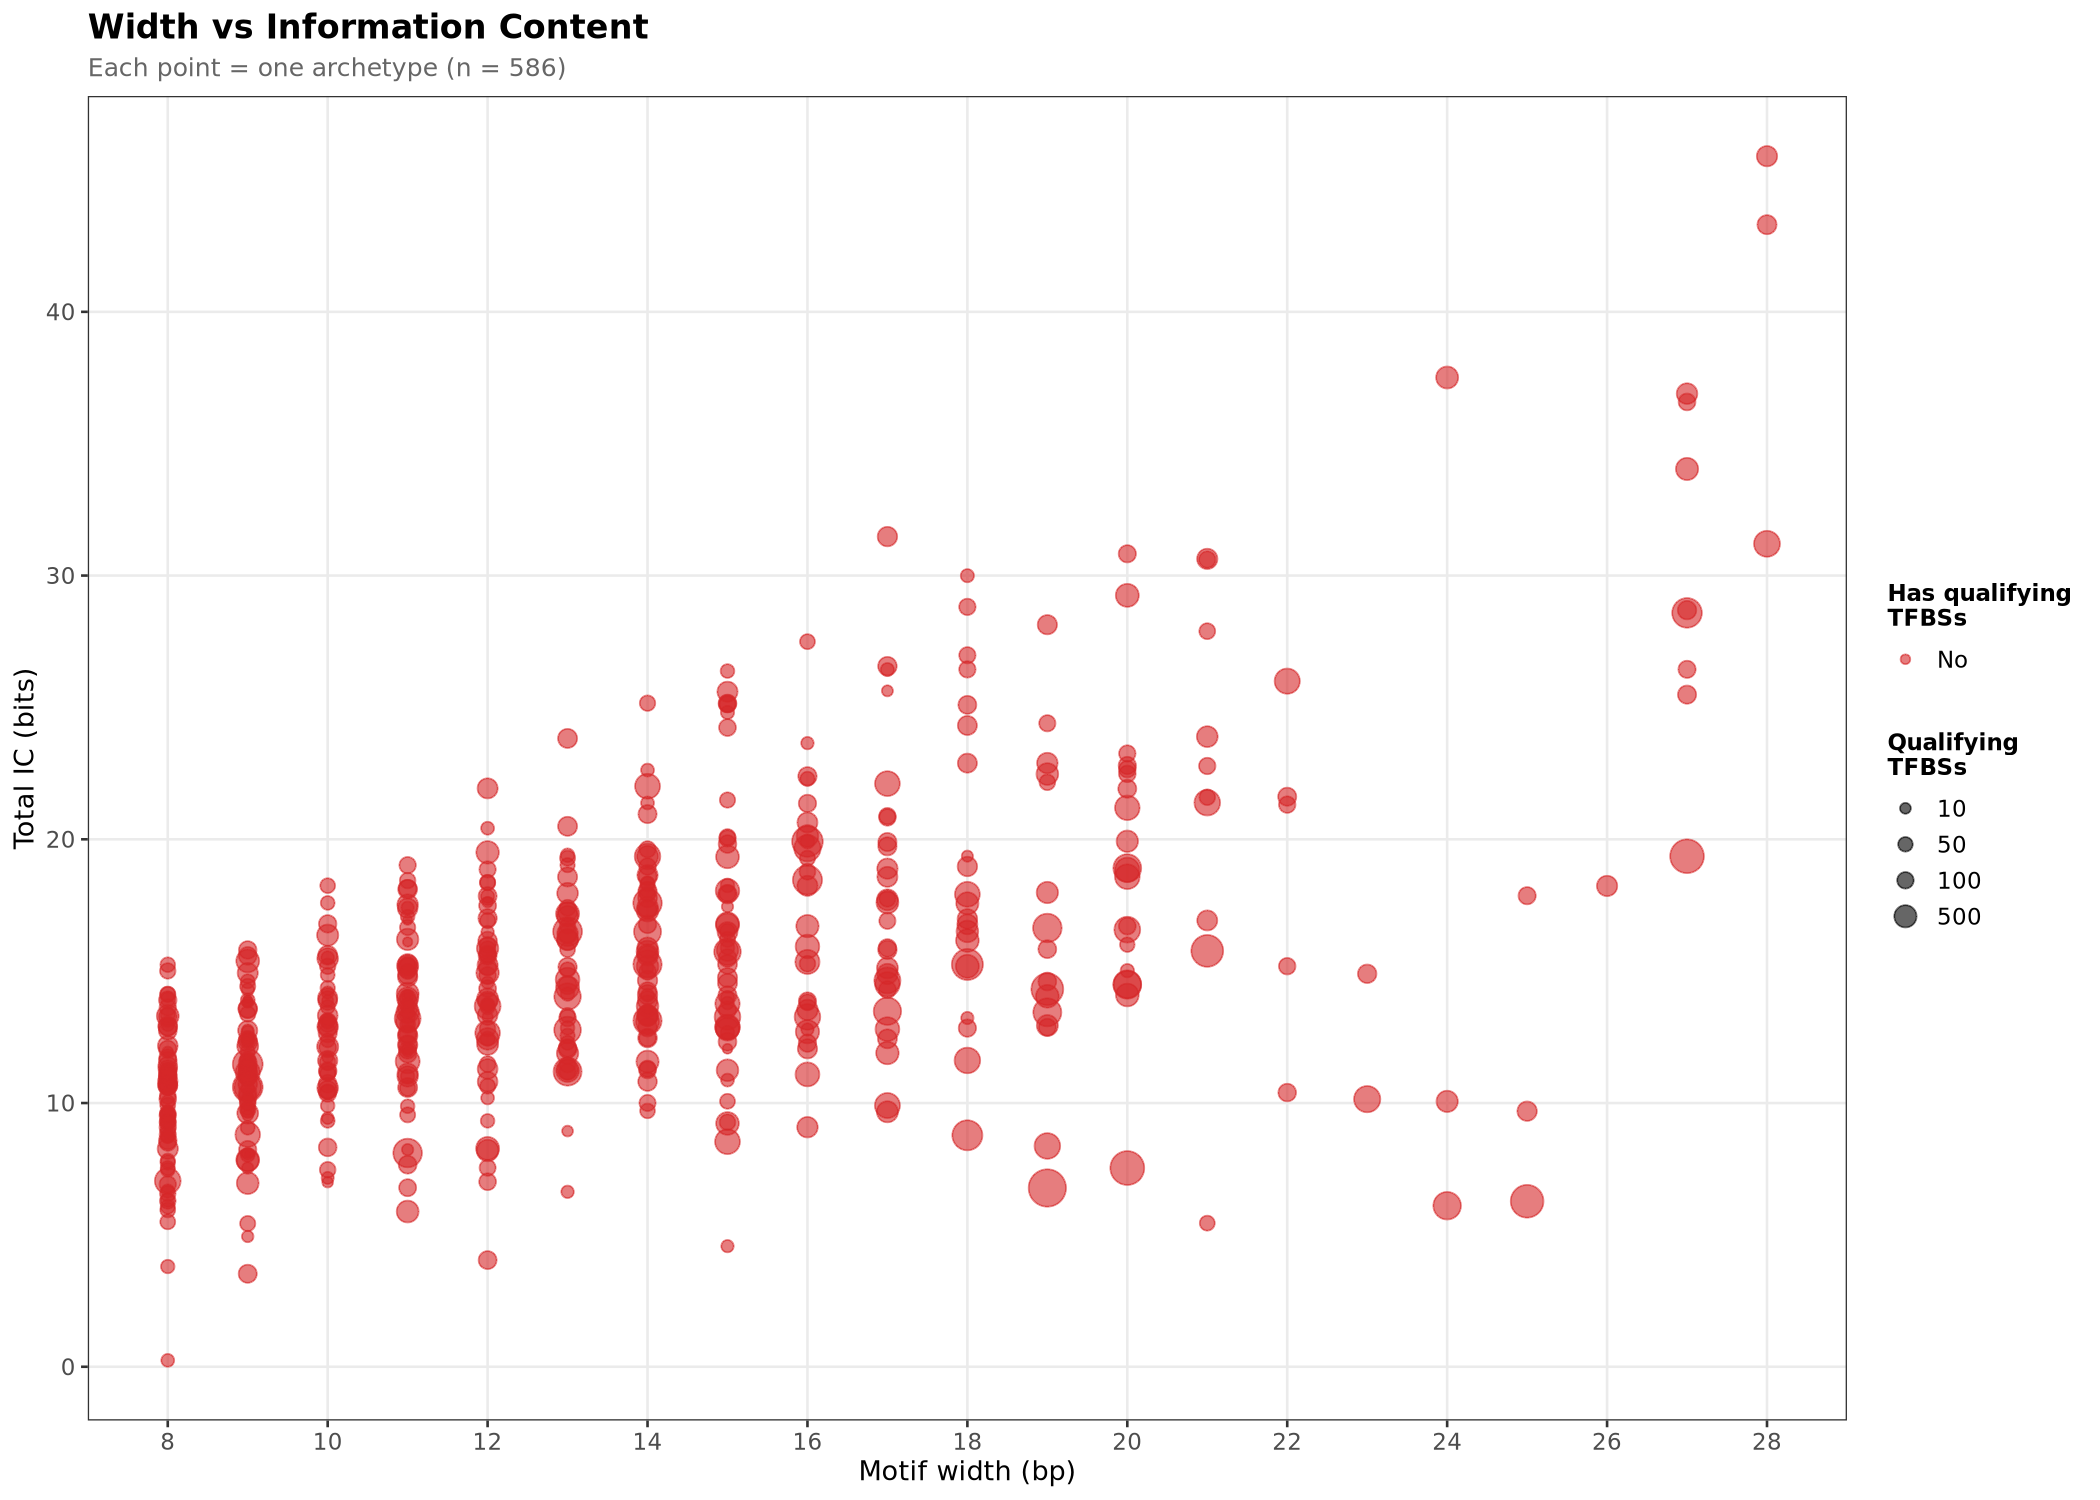

In [21]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 17: IC distributions (from summary table)                         ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

p_ic_total <- ggplot(arch_sum, aes(x = total_ic)) +
    geom_histogram(bins = 40, fill = "#e6550d", color = "white", linewidth = 0.3) +
    scale_y_continuous(expand = expansion(mult = c(0, 0.08))) +
    labs(title = "Total Information Content Distribution",
         subtitle = paste0("Included archetypes (n = ", nrow(arch_sum), "); range: ",
                           round(min(arch_sum$total_ic, na.rm = TRUE), 1), " \u2013 ",
                           round(max(arch_sum$total_ic, na.rm = TRUE), 1), " bits"),
         x = "Total information content (bits)", y = "Number of archetypes") +
    THEME
print(p_ic_total)

p_ic_pp <- ggplot(arch_sum, aes(x = mean_ic_per_pos)) +
    geom_histogram(bins = 40, fill = "#756bb1", color = "white", linewidth = 0.3) +
    scale_y_continuous(expand = expansion(mult = c(0, 0.08))) +
    labs(title = "Mean IC per Position",
         subtitle = paste0("Median = ",
                           round(median(arch_sum$mean_ic_per_pos, na.rm = TRUE), 2),
                           " bits/pos"),
         x = "Mean IC per position (bits)", y = "Number of archetypes") +
    THEME
print(p_ic_pp)


# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 18: Width vs IC scatter (from summary table)                      ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

arch_sum[, has_ready := n_snp_overlap > 0]

p <- ggplot(arch_sum,
             aes(x = motif_width, y = total_ic,
                 size = pmax(n_snp_overlap, 1),
                 color = has_ready)) +
    geom_point(alpha = 0.6) +
    scale_color_manual(values = c("FALSE" = "#bdbdbd", "TRUE" = "#d62728"),
                        name = "Has qualifying\nTFBSs",
                        labels = c("No", "Yes")) +
    scale_size_continuous(name = "Qualifying\nTFBSs", range = c(1, 8),
                           trans = "sqrt",
                           breaks = c(1, 10, 50, 100, 500)) +
    scale_x_continuous(breaks = seq(0, 30, by = 2)) +
    labs(title = "Width vs Information Content",
         subtitle = paste0("Each point = one archetype (n = ", nrow(arch_sum), ")"),
         x = "Motif width (bp)", y = "Total IC (bits)") +
    THEME +
    theme(legend.position = "right")
print(p)

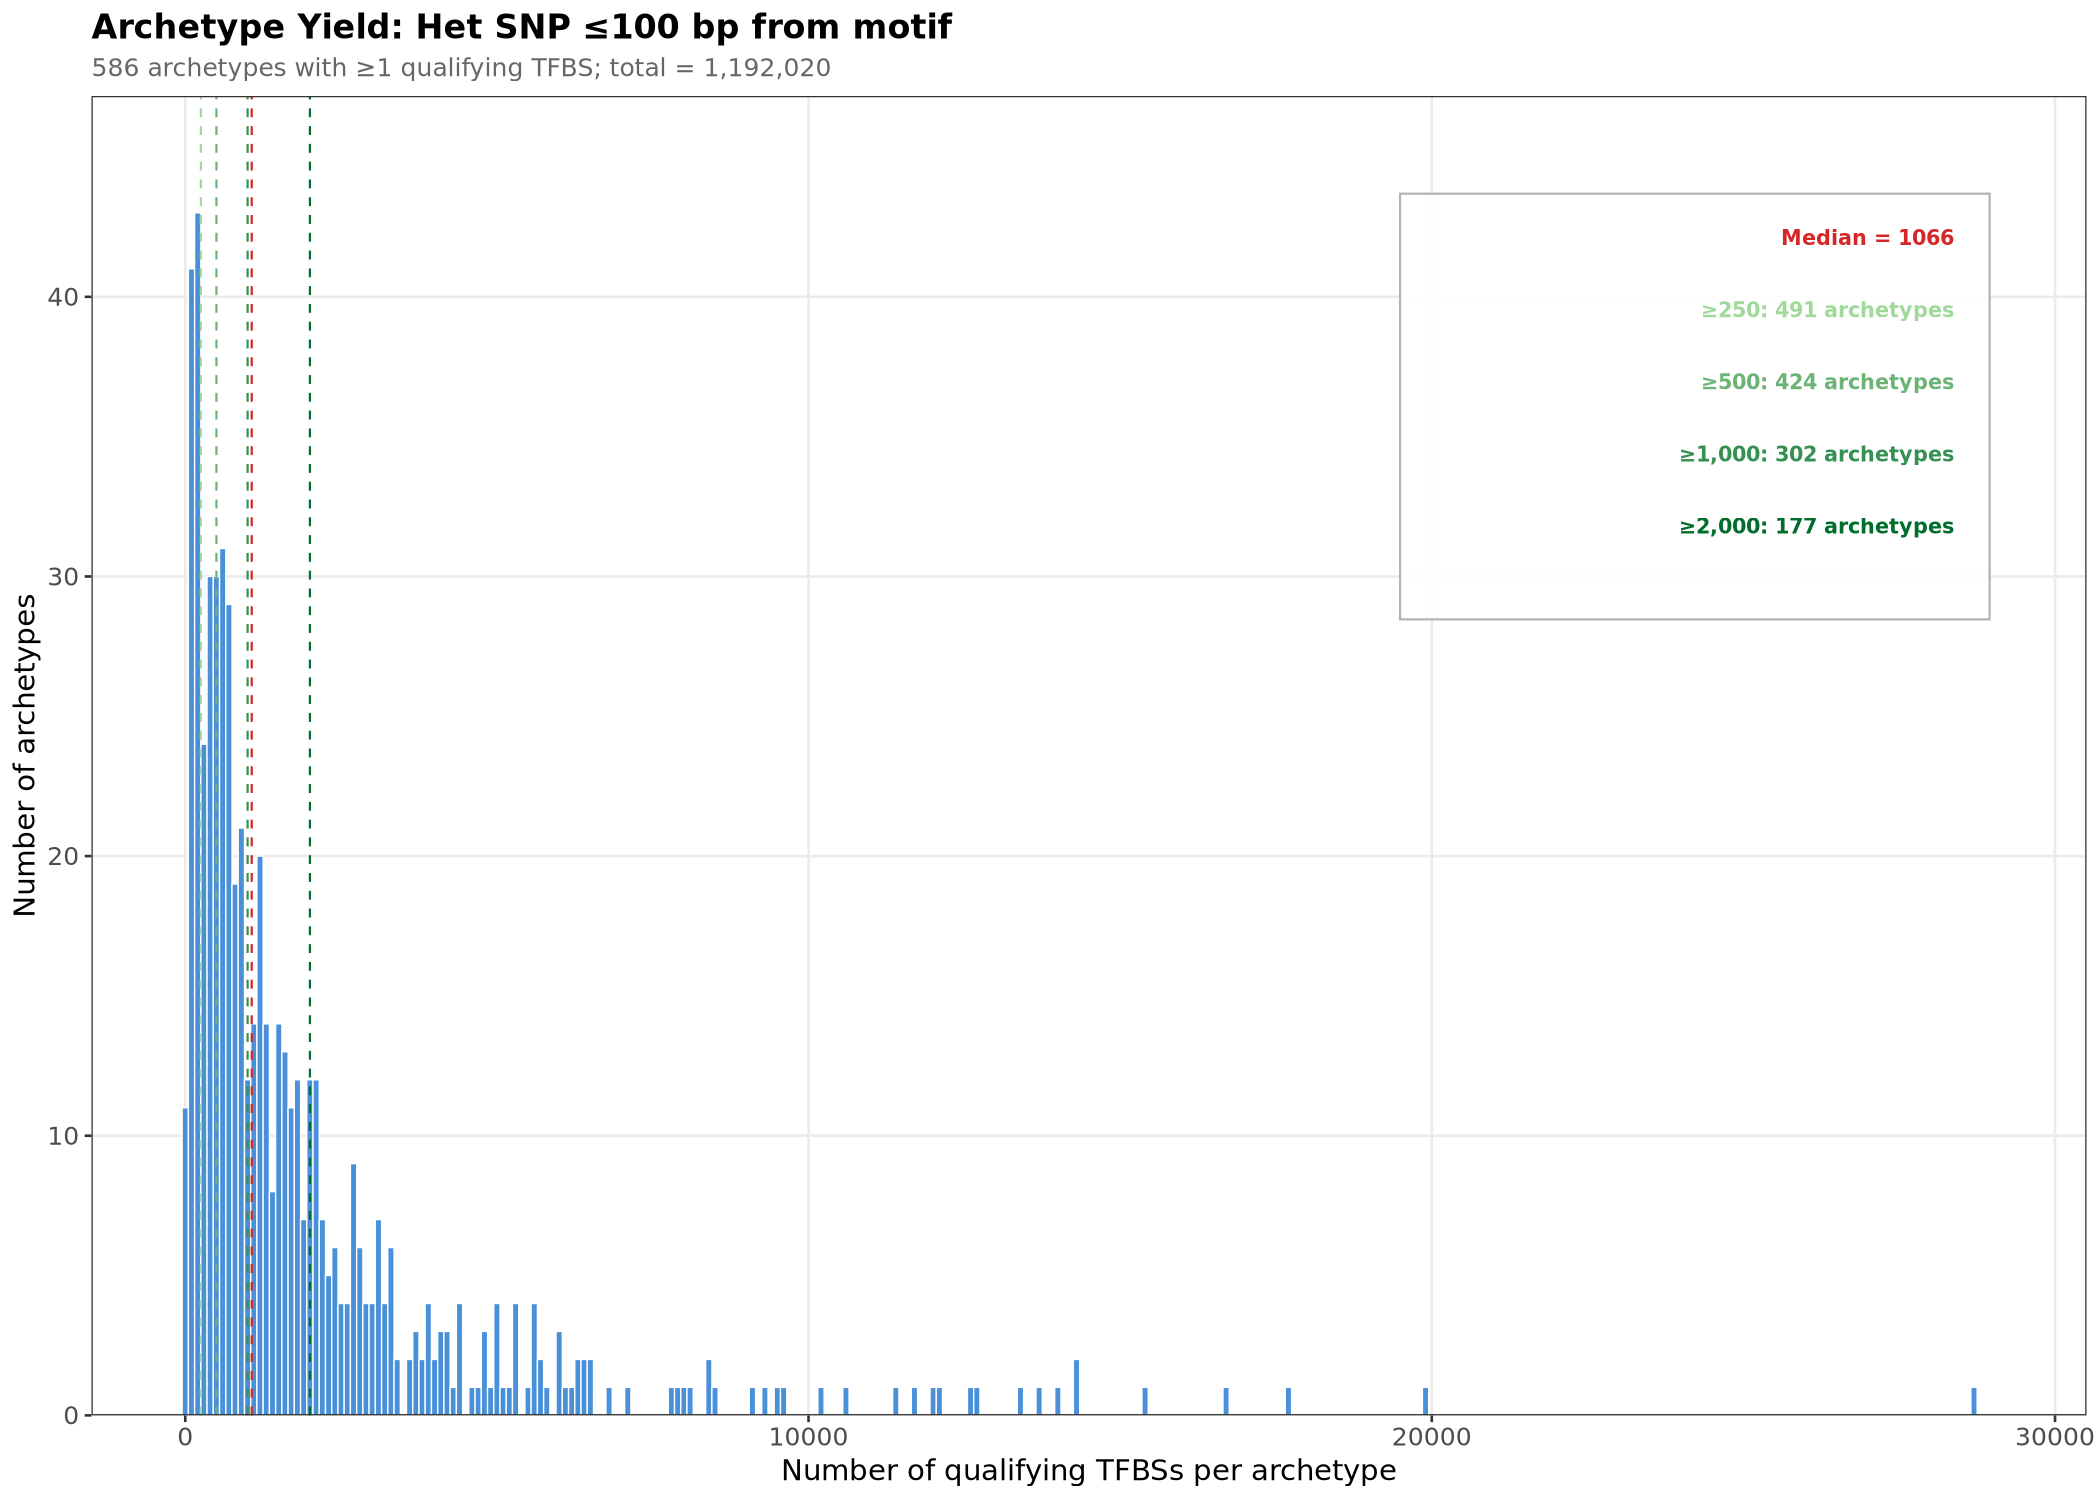

In [71]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 19: Archetype yield histogram — CHOOSE THRESHOLD                 ║
# ║  Change SNP_THRESH (same variable as Cell 11)                           ║
# ╚═══════════════════════════════════════════════════════════════════════════╝
## === CHANGE THIS to switch versions (or reuse from Cell 11) ===
#SNP_THRESH <- "overlap"
SNP_THRESH <- "100bp"

tv <- thresh_map[[SNP_THRESH]]
col_name <- tv$col
thresh_label <- tv$label
yield_data <- data.table(count = arch_sum[get(col_name) > 0][[col_name]])
if (nrow(yield_data) > 0) {
    max_val <- max(yield_data$count)
    
    # ═══════════════════ IMPROVED BINWIDTH CALCULATION ═══════════════════
    # bw <- if (max_val <= 50) 5 
    #       else if (max_val <= 200) 10 
    #       else if (max_val <= 500) 25 
    #       else if (max_val <= 1000) 50
    #       else 100

    bw <- if (max_val <= 500) 25 
          else if (max_val <= 1000) 50
          else 100
    # ═════════════════════════════════════════════════════════════════════
    
    n_arch <- nrow(yield_data)
    med_val <- median(yield_data$count)
    
    # ═══════════════════ CUMULATIVE THRESHOLDS ═══════════════════
    # Define thresholds to show (adjust these as needed)
    cumul_thresholds <- c(250, 500, 1000, 2000)
    
    # Calculate how many archetypes have >= each threshold
    cumul_data <- data.table(
        threshold = cumul_thresholds,
        n_archetypes = sapply(cumul_thresholds, function(t) {
            sum(yield_data$count >= t)
        })
    )
    # Only keep thresholds that are within the data range
    cumul_data <- cumul_data[threshold <= max_val & n_archetypes > 0]
    
    # ═══════════════════ COLOR GRADIENT FOR THRESHOLDS ═══════════════════
    # Create a color gradient from light to dark green
    n_thresholds <- nrow(cumul_data)
    if (n_thresholds > 0) {
        green_colors <- colorRampPalette(c("#a1d99b", "#006d2c"))(n_thresholds)
        cumul_data[, line_color := green_colors]
    }
    # ═══════════════════════════════════════════════════════════════════════
    
    p <- ggplot(yield_data, aes(x = count)) +
        geom_histogram(binwidth = bw, fill = "#4a90d9", color = "white",
                       linewidth = 0.3) +
        # ═══════════════════ MEDIAN LINE (RED) ═══════════════════
        geom_vline(xintercept = med_val, linetype = "dashed",
                   color = "#d62728", linewidth = 0.5) +
        # ═══════════════════ THRESHOLD LINES (GREEN GRADIENT) ═══════════════════
        geom_vline(data = cumul_data,
                   aes(xintercept = threshold, color = line_color),
                   linetype = "dashed",
                   linewidth = 0.5,
                   show.legend = FALSE) +
        scale_color_identity() +
        # ═══════════════════════════════════════════════════════════════════
        scale_y_continuous(expand = expansion(mult = c(0, 0.08))) +
        labs(title = paste0("Archetype Yield: ", thresh_label),
             subtitle = paste0(n_arch, " archetypes with \u22651 qualifying TFBS; ",
                               "total = ", comma(sum(yield_data$count))),
             x = "Number of qualifying TFBSs per archetype",
             y = "Number of archetypes") +
        THEME +
        theme(
            # ═══════════════════ FONT SIZE CONTROLS ═══════════════════
            plot.title = element_text(size = 16),        # ← TITLE SIZE
            plot.subtitle = element_text(size = 12),     # ← SUBTITLE SIZE
            axis.title.x = element_text(size = 14),      # ← X-AXIS LABEL SIZE
            axis.title.y = element_text(size = 14),      # ← Y-AXIS LABEL SIZE
            axis.text.x = element_text(size = 12),       # ← X-AXIS TICK LABELS
            axis.text.y = element_text(size = 12)        # ← Y-AXIS TICK LABELS
            # ══════════════════════════════════════════════════════════
        )
    
    # ═══════════════════ ADD COLORED LEGEND AS SEPARATE TEXT ANNOTATIONS ═══════════════════
    # Get y-axis max for positioning
    y_max <- max(ggplot_build(p)$data[[1]]$count)
    
    # Build legend data
    legend_data <- data.table(
        label = character(),
        color = character()
    )
    legend_data <- rbind(legend_data, 
                         data.table(label = paste0("Median = ", round(med_val)),
                                   color = "#d62728"))
    if (nrow(cumul_data) > 0) {
        for (i in 1:nrow(cumul_data)) {
            legend_data <- rbind(legend_data,
                data.table(label = paste0("\u2265", comma(cumul_data$threshold[i]), 
                                         ": ", cumul_data$n_archetypes[i], " archetypes"),
                          color = cumul_data$line_color[i]))
        }
    }
    
    # Calculate positions for each legend line
    n_lines <- nrow(legend_data)
    line_spacing <- y_max * 0.06  # Adjust spacing between lines
    y_start <- y_max * 0.98       # Start from top
    
    # Add white background rectangle with more top padding
    p <- p + 
        annotate("rect",
                 xmin = max_val * 0.68, xmax = max_val * 1.01,
                 ymin = y_start - (n_lines * line_spacing) - (line_spacing * 0.3),
                 ymax = y_start + (line_spacing * 0.6),
                 fill = "white", alpha = 0.9, color = "gray70", linewidth = 0.5)
    
    # Add each legend line with its color
    for (i in 1:n_lines) {
        y_pos <- y_start - ((i - 1) * line_spacing)
        p <- p + 
            annotate("text",
                     x = max_val * 0.99, y = y_pos,
                     label = legend_data$label[i],
                     hjust = 1, vjust = 0.5,
                     size = 3.5,
                     fontface = "bold",
                     color = legend_data$color[i])
    }
    # ═══════════════════════════════════════════════════════════════════
    
    print(p)
    
    # Save the plot to subdirectory
    dir.create("plots", showWarnings = FALSE)
    ggsave(paste0("plots/archetype_yield_", SNP_THRESH, ".png"), 
           plot = p, 
           width = 8,   # ← PLOT WIDTH (inches)
           height = 5,   # ← PLOT HEIGHT (inches)
           dpi = 300)    # ← RESOLUTION
    
} else {
    cat("No archetypes with qualifying TFBSs at this threshold.\n")
}

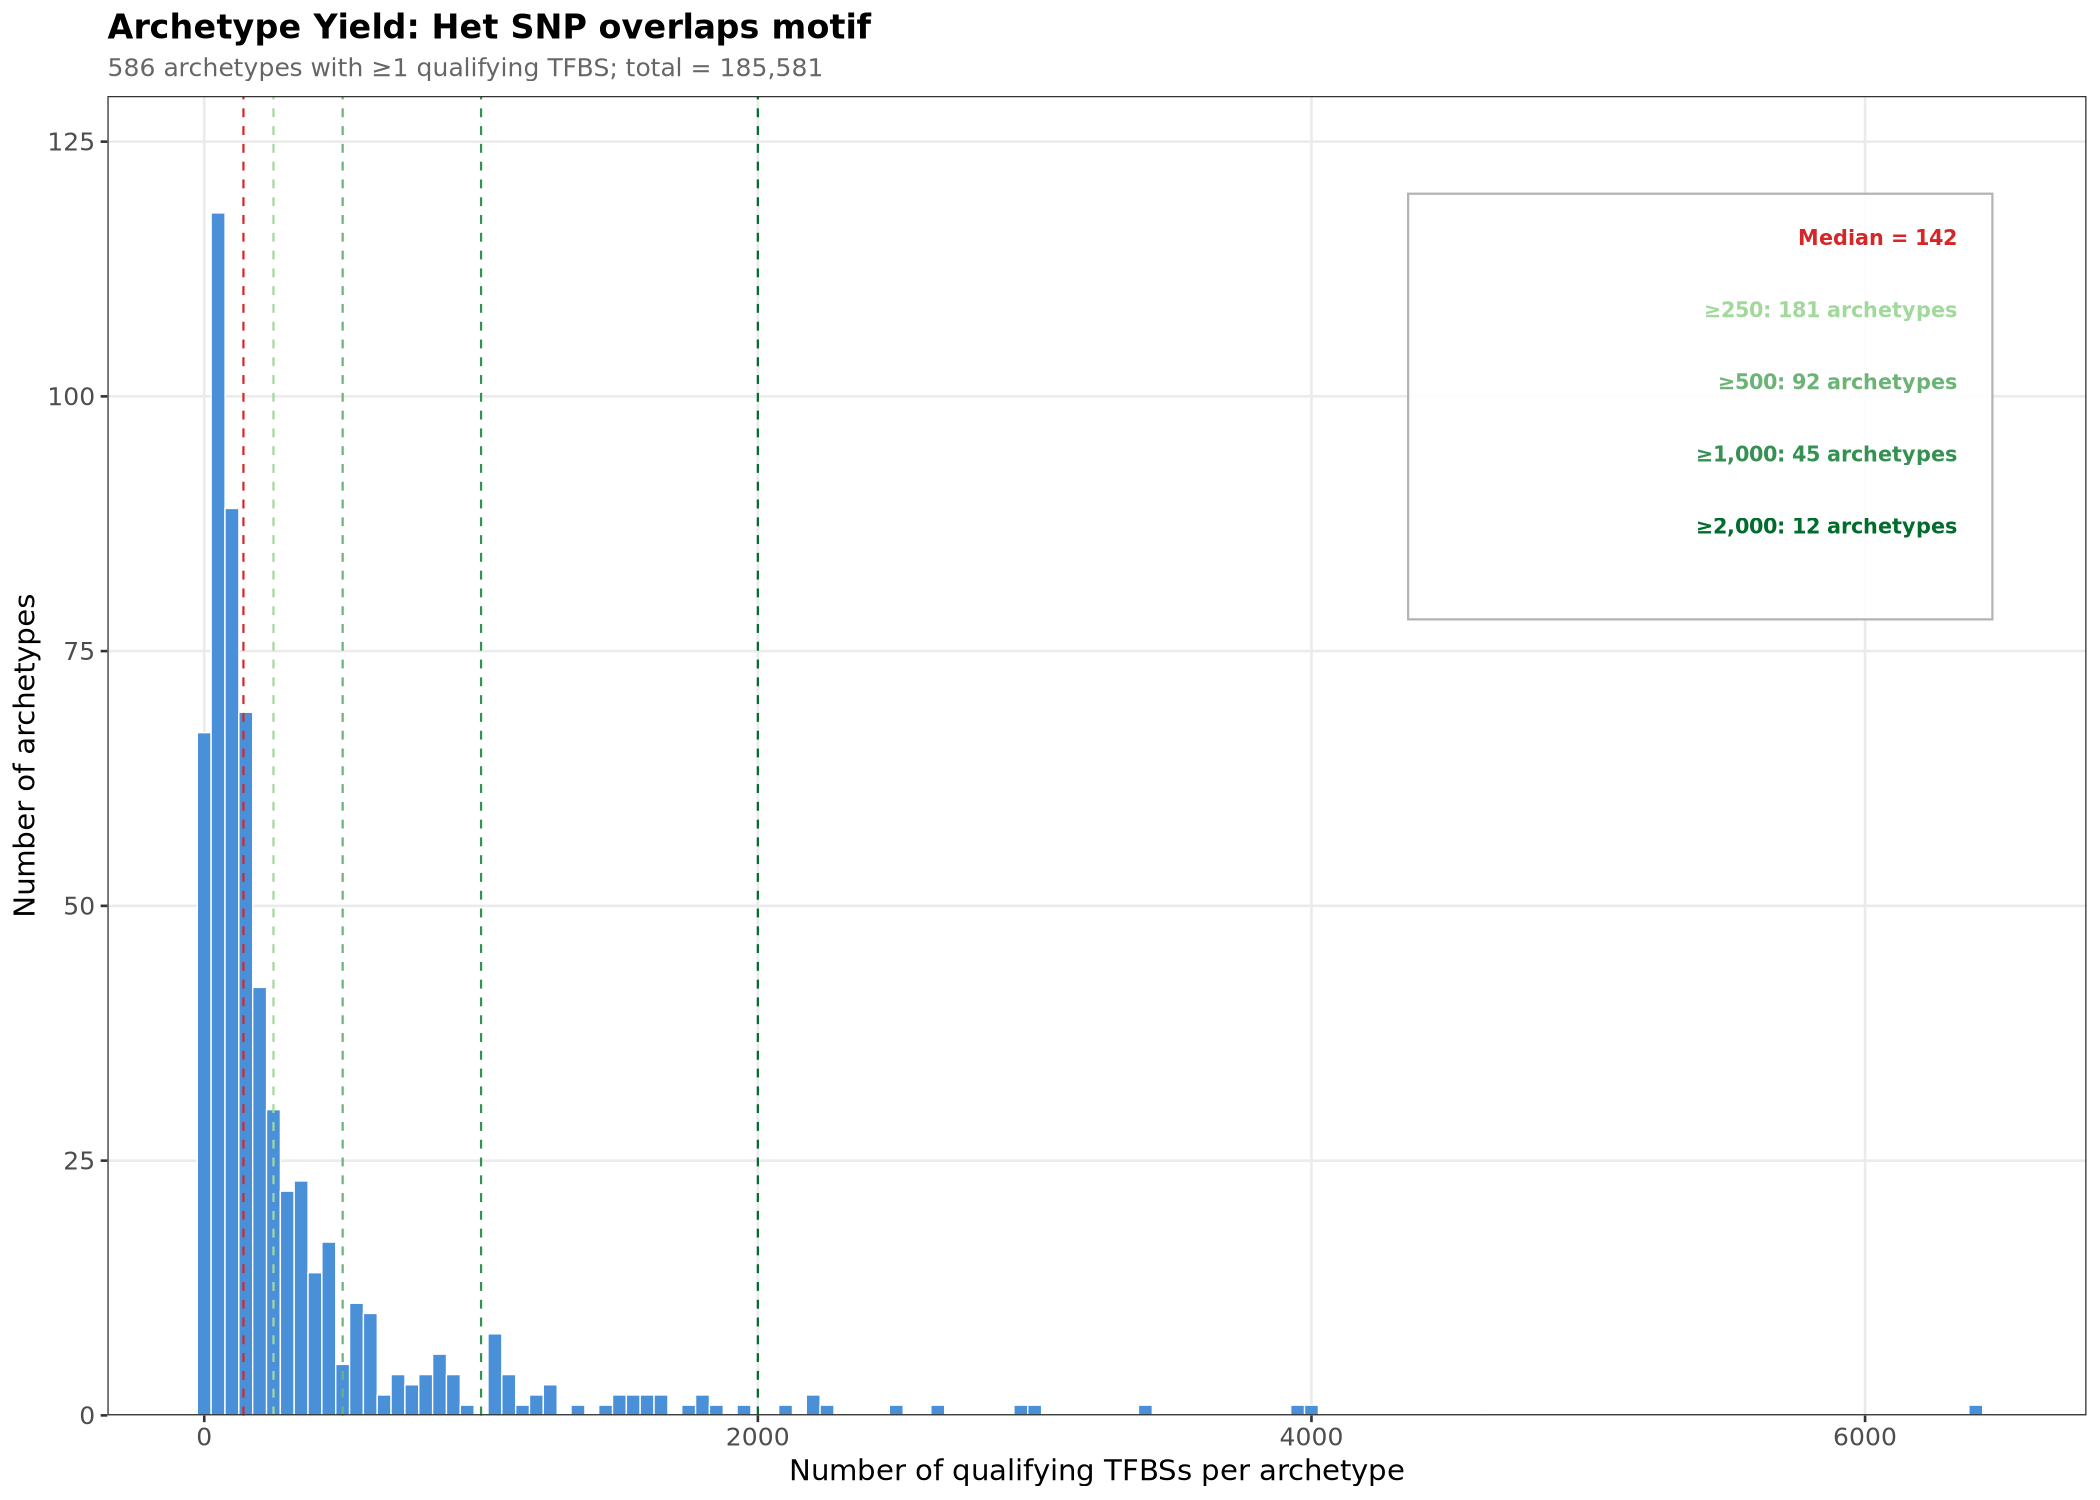

In [ ]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  CELL 19: Archetype yield histogram — CHOOSE THRESHOLD                 ║
# ║  Change SNP_THRESH (same variable as Cell 11)                           ║
# ╚═══════════════════════════════════════════════════════════════════════════╝
## === CHANGE THIS to switch versions (or reuse from Cell 11) ===
SNP_THRESH <- "overlap"

tv <- thresh_map[[SNP_THRESH]]
col_name <- tv$col
thresh_label <- tv$label
yield_data <- data.table(count = arch_sum[get(col_name) > 0][[col_name]])
if (nrow(yield_data) > 0) {
    max_val <- max(yield_data$count)


    bw <- if (max_val <= 50) 5 else if (max_val <= 200) 10 else
          if (max_val <= 500) 25 else 50

          
    n_arch <- nrow(yield_data)
    med_val <- median(yield_data$count)
    
    # ═══════════════════ CUMULATIVE THRESHOLDS ═══════════════════
    # Define thresholds to show (adjust these as needed)
    cumul_thresholds <- c(250, 500, 1000, 2000)
    
    # Calculate how many archetypes have >= each threshold
    cumul_data <- data.table(
        threshold = cumul_thresholds,
        n_archetypes = sapply(cumul_thresholds, function(t) {
            sum(yield_data$count >= t)
        })
    )
    # Only keep thresholds that are within the data range
    cumul_data <- cumul_data[threshold <= max_val & n_archetypes > 0]
    
    # ═══════════════════ COLOR GRADIENT FOR THRESHOLDS ═══════════════════
    # Create a color gradient from light to dark green
    n_thresholds <- nrow(cumul_data)
    if (n_thresholds > 0) {
        green_colors <- colorRampPalette(c("#a1d99b", "#006d2c"))(n_thresholds)
        cumul_data[, line_color := green_colors]
    }
    # ═══════════════════════════════════════════════════════════════════════
    
    p <- ggplot(yield_data, aes(x = count)) +
        geom_histogram(binwidth = bw, fill = "#4a90d9", color = "white",
                       linewidth = 0.3) +
        # ═══════════════════ MEDIAN LINE (RED) ═══════════════════
        geom_vline(xintercept = med_val, linetype = "dashed",
                   color = "#d62728", linewidth = 0.5) +
        # ═══════════════════ THRESHOLD LINES (GREEN GRADIENT) ═══════════════════
        geom_vline(data = cumul_data,
                   aes(xintercept = threshold, color = line_color),
                   linetype = "dashed",
                   linewidth = 0.5,
                   show.legend = FALSE) +
        scale_color_identity() +
        # ═══════════════════════════════════════════════════════════════════
        scale_y_continuous(expand = expansion(mult = c(0, 0.08))) +
        labs(title = paste0("Archetype Yield: ", thresh_label),
             subtitle = paste0(n_arch, " archetypes with \u22651 qualifying TFBS; ",
                               "total = ", comma(sum(yield_data$count))),
             x = "Number of qualifying TFBSs per archetype",
             y = "Number of archetypes") +
        THEME +
        theme(
            # ═══════════════════ FONT SIZE CONTROLS ═══════════════════
            plot.title = element_text(size = 16),        # ← TITLE SIZE
            plot.subtitle = element_text(size = 12),     # ← SUBTITLE SIZE
            axis.title.x = element_text(size = 14),      # ← X-AXIS LABEL SIZE
            axis.title.y = element_text(size = 14),      # ← Y-AXIS LABEL SIZE
            axis.text.x = element_text(size = 12),       # ← X-AXIS TICK LABELS
            axis.text.y = element_text(size = 12)        # ← Y-AXIS TICK LABELS
            # ══════════════════════════════════════════════════════════
        )
    
    # ═══════════════════ ADD COLORED LEGEND AS SEPARATE TEXT ANNOTATIONS ═══════════════════
    # Get y-axis max for positioning
    y_max <- max(ggplot_build(p)$data[[1]]$count)
    
    # Build legend data
    legend_data <- data.table(
        label = character(),
        color = character()
    )
    legend_data <- rbind(legend_data, 
                         data.table(label = paste0("Median = ", round(med_val)),
                                   color = "#d62728"))
    if (nrow(cumul_data) > 0) {
        for (i in 1:nrow(cumul_data)) {
            legend_data <- rbind(legend_data,
                data.table(label = paste0("\u2265", comma(cumul_data$threshold[i]), 
                                         ": ", cumul_data$n_archetypes[i], " archetypes"),
                          color = cumul_data$line_color[i]))
        }
    }
    
    # Calculate positions for each legend line
    n_lines <- nrow(legend_data)
    line_spacing <- y_max * 0.06  # Adjust spacing between lines
    y_start <- y_max * 0.98       # Start from top
    
    # Add white background rectangle with more top padding
    p <- p + 
        annotate("rect",
                 xmin = max_val * 0.68, xmax = max_val * 1.01,
                 ymin = y_start - (n_lines * line_spacing) - (line_spacing * 0.3),
                 ymax = y_start + (line_spacing * 0.6),  # ← INCREASED FROM 0.3 TO 0.6
                 fill = "white", alpha = 0.9, color = "gray70", linewidth = 0.5)
    
    # Add each legend line with its color
    for (i in 1:n_lines) {
        y_pos <- y_start - ((i - 1) * line_spacing)
        p <- p + 
            annotate("text",
                     x = max_val * 0.99, y = y_pos,
                     label = legend_data$label[i],
                     hjust = 1, vjust = 0.5,
                     size = 3.5,
                     fontface = "bold",
                     color = legend_data$color[i])
    }
    # ═══════════════════════════════════════════════════════════════════
    
    print(p)
    
    # Save the plot to subdirectory
    dir.create("plots", showWarnings = FALSE)
    ggsave(paste0("plots/archetype_yield_", SNP_THRESH, ".png"), 
           plot = p, 
           width = 8,   # ← PLOT WIDTH (inches)
           height = 5,   # ← PLOT HEIGHT (inches)
           dpi = 300)    # ← RESOLUTION
    
} else {
    cat("No archetypes with qualifying TFBSs at this threshold.\n")
}